# Content — 질문과 후보의 공급 구조

질문 데이터가 제공된 10개 학교에서 질문·후보의 다양성, 반복, 관계 적합성과 행동 연결을 분석한다.

- 질문조각 생성시각은 실제 노출시각이 아니다.
- 질문세트 상태는 완주 여부로 사용하지 않는다.
- 친구·학교·학년·반 정보는 현재 스냅샷이다.
- 통계적 연관성을 인과효과로 해석하지 않는다.


In [1]:
from pathlib import Path
import json, math, re, unicodedata, warnings
from collections import Counter

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats
from scipy.spatial.distance import jensenshannon
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, roc_auc_score, average_precision_score,
                             brier_score_loss, log_loss, adjusted_rand_score)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from kiwipiepy import Kiwi
import umap.umap_ as umap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = Path(r'C:\Users\lucy5\Desktop\team7')
ANALYSIS_DIR = ROOT / 'analysis' / 'content_deep_dive'
OUTPUT_DIR = ANALYSIS_DIR / 'outputs'
FIG_DIR = OUTPUT_DIR / 'figures'
CACHE_DIR = OUTPUT_DIR / 'cache'
for d in (OUTPUT_DIR, FIG_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

QDIR = ROOT / 'data' / 'processed' / 'question_candidate'
PATHS = {
    'qset': QDIR / 'mart_question_set_record_v2_clean.csv.gz',
    'piece': QDIR / 'mart_question_piece_record_v2_clean.csv.gz',
    'vote': QDIR / 'mart_vote_record_v2_clean.csv.gz',
    'candidate': QDIR / 'mart_question_candidate_exposure_v2_clean.csv.gz',
    'text': ROOT / 'data' / 'marts' / '23_marts_csv' / 'mart_question_exposure.csv.gz',
    'profile': ROOT / 'data' / 'processed' / 'viral_school' / 'mart_user_acquisition_profile_v2_clean.csv.gz',
}
missing = [str(p) for p in PATHS.values() if not p.exists()]
assert not missing, f'입력 파일 누락: {missing}'

def psql(path):
    return str(path).replace('\\', '/')

con = duckdb.connect()
for name, path in PATHS.items():
    con.execute(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM read_csv_auto('{psql(path)}', header=true)")

MODEL_NAME = 'jhgan/ko-sroberta-multitask'
RANDOM_STATE = 42
print('프로젝트:', ROOT)
print('출력:', OUTPUT_DIR)
print('텍스트 임베딩 모델:', MODEL_NAME)

C:\Users\lucy5\Desktop\team7\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


프로젝트: C:\Users\lucy5\Desktop\team7
출력: C:\Users\lucy5\Desktop\team7\analysis\content_deep_dive\outputs
텍스트 임베딩 모델: jhgan/ko-sroberta-multitask


## 1. 분석 범위와 데이터 연결 검증

분석 모집단, 기간, 질문·후보·투표 키의 연결률을 확인한다.


In [2]:
scope = con.execute("""
WITH s AS (
  SELECT 'question_set' mart, COUNT(*) rows_all,
         SUM(CASE WHEN analysis_eligible_question_set_flag=1 THEN 1 ELSE 0 END) rows_eligible,
         MIN(question_set_created_at) min_at, MAX(question_set_created_at) max_at,
         COUNT(DISTINCT owner_current_school_id) FILTER (WHERE analysis_eligible_question_set_flag=1) schools
  FROM qset
  UNION ALL
  SELECT 'question_piece', COUNT(*), SUM(CASE WHEN analysis_eligible_piece_relation_flag=1 THEN 1 ELSE 0 END),
         MIN(question_piece_created_at), MAX(question_piece_created_at),
         COUNT(DISTINCT resolved_owner_current_school_id) FILTER (WHERE analysis_eligible_piece_relation_flag=1)
  FROM piece
  UNION ALL
  SELECT 'vote_record', COUNT(*), SUM(CASE WHEN analysis_eligible_vote_record_flag=1 THEN 1 ELSE 0 END),
         MIN(vote_record_created_at), MAX(vote_record_created_at),
         COUNT(DISTINCT voter_current_school_id) FILTER (WHERE analysis_eligible_vote_record_flag=1)
  FROM vote
  UNION ALL
  SELECT 'candidate_raw', COUNT(*), SUM(CASE WHEN analysis_eligible_candidate_raw_flag=1 THEN 1 ELSE 0 END),
         MIN(candidate_source_created_at), MAX(candidate_source_created_at),
         COUNT(DISTINCT owner_current_school_id) FILTER (WHERE analysis_eligible_candidate_raw_flag=1)
  FROM candidate
  UNION ALL
  SELECT 'candidate_canonical', COUNT(*), SUM(CASE WHEN analysis_eligible_candidate_canonical_flag=1 THEN 1 ELSE 0 END),
         MIN(candidate_source_created_at), MAX(candidate_source_created_at),
         COUNT(DISTINCT owner_current_school_id) FILTER (WHERE analysis_eligible_candidate_canonical_flag=1)
  FROM candidate
)
SELECT * FROM s
""").df()
display(scope)

text_qa = con.execute("""
WITH td AS (
  SELECT CAST(question_piece_id AS VARCHAR) question_piece_id,
         COUNT(DISTINCT NULLIF(TRIM(question_text), '')) text_n,
         MAX(NULLIF(TRIM(question_text), '')) question_text
  FROM text GROUP BY 1
), p AS (
  SELECT CAST(question_piece_id AS VARCHAR) question_piece_id
  FROM piece WHERE analysis_eligible_piece_relation_flag=1
)
SELECT COUNT(*) eligible_piece_rows,
       SUM(CASE WHEN td.question_text IS NOT NULL THEN 1 ELSE 0 END) text_matched_rows,
       SUM(CASE WHEN td.text_n > 1 THEN 1 ELSE 0 END) multi_text_piece_rows,
       SUM(CASE WHEN td.question_text IS NULL THEN 1 ELSE 0 END) text_missing_rows
FROM p LEFT JOIN td USING(question_piece_id)
""").df()

profile_qa = con.execute("""
WITH p AS (
  SELECT DISTINCT CAST(resolved_owner_user_id AS VARCHAR) user_id
  FROM piece WHERE analysis_eligible_piece_relation_flag=1
), u AS (
  SELECT CAST(user_id AS VARCHAR) user_id, MIN(signup_at) signup_at, COUNT(*) n
  FROM profile WHERE analysis_eligible_nonstaff_flag=1 GROUP BY 1
)
SELECT COUNT(*) owners, SUM(CASE WHEN u.signup_at IS NOT NULL THEN 1 ELSE 0 END) signup_matched,
       SUM(CASE WHEN u.n>1 THEN 1 ELSE 0 END) duplicated_profile_ids
FROM p LEFT JOIN u USING(user_id)
""").df()

display(Markdown('**질문 문구 연결 QA**'))
display(text_qa)
display(Markdown('**가입일 연결 QA**'))
display(profile_qa)
scope.to_csv(OUTPUT_DIR/'source_mart_scope.csv', index=False, encoding='utf-8-sig')
text_qa.to_csv(OUTPUT_DIR/'question_text_join_qa.csv', index=False, encoding='utf-8-sig')
profile_qa.to_csv(OUTPUT_DIR/'signup_profile_join_qa.csv', index=False, encoding='utf-8-sig')
assert int(text_qa.loc[0, 'multi_text_piece_rows']) == 0
assert int(text_qa.loc[0, 'text_missing_rows']) == 0
assert int(profile_qa.loc[0, 'duplicated_profile_ids']) == 0

,mart,rows_all,rows_eligible,min_at,max_at,schools
0,question_set,158384,158384.0,2023-04-28 12:27:23,2024-05-07 11:32:30,10
1,question_piece,1265476,1265476.0,2023-04-28 12:27:22,2024-05-07 11:32:30,10
2,vote_record,1217558,1217558.0,2023-04-28 12:27:49,2024-05-08 01:36:18,10
3,candidate_raw,4769609,4769609.0,2023-04-28 12:27:49,2024-05-08 01:36:18,10
4,candidate_canonical,4769609,4769034.0,2023-04-28 12:27:49,2024-05-08 01:36:18,10


**질문 문구 연결 QA**

,eligible_piece_rows,text_matched_rows,multi_text_piece_rows,text_missing_rows
0,1265476,1265476.0,0.0,0.0


**가입일 연결 QA**

,owners,signup_matched,duplicated_profile_ids
0,4972,4972.0,0.0


In [3]:
con.execute("""
CREATE OR REPLACE TEMP TABLE text_dim AS
SELECT CAST(question_piece_id AS VARCHAR) question_piece_id,
       MAX(NULLIF(TRIM(question_text), '')) question_text
FROM text GROUP BY 1;

CREATE OR REPLACE TEMP TABLE signup_dim AS
SELECT CAST(user_id AS VARCHAR) user_id, MIN(TRY_CAST(signup_at AS TIMESTAMP)) signup_at
FROM profile WHERE analysis_eligible_nonstaff_flag=1 GROUP BY 1;

CREATE OR REPLACE TEMP TABLE candidate_piece AS
SELECT CAST(question_piece_id AS VARCHAR) question_piece_id,
       1 candidate_source_observed,
       COUNT(*) candidate_count,
       COUNT(DISTINCT CAST(candidate_user_id AS VARCHAR)) candidate_distinct_count,
       MAX(CAST(duplicate_candidate_pair_flag AS INTEGER)) has_duplicate_candidate,
       MAX(CAST(self_candidate_flag AS INTEGER)) has_self_candidate,
       MAX(CAST(current_friend_any_direction_flag AS INTEGER)) has_current_friend_candidate,
       MAX(CAST(current_friend_mutual_flag AS INTEGER)) has_mutual_friend_candidate,
       MAX(CAST(same_school_current_flag AS INTEGER)) has_same_school_candidate,
       MAX(CAST(same_school_grade_current_flag AS INTEGER)) has_same_grade_candidate,
       MAX(CAST(same_school_grade_class_current_flag AS INTEGER)) has_same_class_candidate,
       AVG(CAST(current_friend_any_direction_flag AS DOUBLE)) current_friend_share,
       AVG(CAST(same_school_current_flag AS DOUBLE)) same_school_share,
       AVG(CAST(same_school_grade_current_flag AS DOUBLE)) same_grade_share,
       AVG(CAST(same_school_grade_class_current_flag AS DOUBLE)) same_class_share,
       MAX(CASE WHEN selected_candidate_canonical_pair_flag=1 AND current_friend_any_direction_flag=1 THEN 1 ELSE 0 END) chose_current_friend,
       MAX(CASE WHEN selected_candidate_canonical_pair_flag=1 AND same_school_grade_class_current_flag=1 THEN 1 ELSE 0 END) chose_same_class,
       MAX(CASE WHEN current_friend_any_direction_flag=1 OR same_school_current_flag=1 OR self_candidate_flag=1 THEN 1 ELSE 0 END) has_any_currently_known_candidate
FROM candidate
WHERE analysis_eligible_candidate_canonical_flag=1
GROUP BY 1;

CREATE OR REPLACE TEMP TABLE piece_core_sql AS
SELECT CAST(p.question_piece_id AS VARCHAR) question_piece_id,
       CAST(p.question_id AS VARCHAR) question_id,
       TRY_CAST(p.question_piece_created_at AS TIMESTAMP) piece_created_at,
       CAST(p.single_question_set_id AS VARCHAR) question_set_id,
       CAST(p.resolved_owner_user_id AS VARCHAR) owner_user_id,
       CAST(p.resolved_owner_current_school_id AS VARCHAR) school_id,
       TRY_CAST(p.single_question_position AS INTEGER) question_position,
       CAST(p.vote_record_exists_flag AS INTEGER) vote_record_exists,
       CAST(p.raw_is_voted AS INTEGER) raw_is_voted,
       CAST(p.raw_is_skipped AS INTEGER) raw_is_skipped,
       p.piece_snapshot_state,
       td.question_text,
       s.signup_at,
       DATE_DIFF('day', s.signup_at, TRY_CAST(p.question_piece_created_at AS TIMESTAMP)) signup_elapsed_days,
       COALESCE(c.candidate_source_observed, 0) candidate_source_observed,
       c.candidate_count,
       c.candidate_distinct_count,
       c.has_duplicate_candidate,
       c.has_self_candidate,
       c.has_current_friend_candidate,
       c.has_mutual_friend_candidate,
       c.has_same_school_candidate,
       c.has_same_grade_candidate,
       c.has_same_class_candidate,
       c.current_friend_share,
       c.same_school_share,
       c.same_grade_share,
       c.same_class_share,
       c.chose_current_friend,
       c.chose_same_class,
       CASE WHEN c.candidate_source_observed IS NULL THEN NULL
            ELSE 1-c.has_any_currently_known_candidate END unknown_only_current_proxy
FROM piece p
JOIN text_dim td ON CAST(p.question_piece_id AS VARCHAR)=td.question_piece_id
LEFT JOIN candidate_piece c ON CAST(p.question_piece_id AS VARCHAR)=c.question_piece_id
LEFT JOIN signup_dim s ON CAST(p.resolved_owner_user_id AS VARCHAR)=s.user_id
WHERE p.analysis_eligible_piece_relation_flag=1;
""")

piece = con.execute("SELECT * FROM piece_core_sql ORDER BY piece_created_at, question_piece_id").df()
piece['piece_created_at'] = pd.to_datetime(piece['piece_created_at'])
piece['signup_at'] = pd.to_datetime(piece['signup_at'])
piece['month'] = piece['piece_created_at'].dt.to_period('M').astype(str)
piece['is_2023_may'] = piece['month'].eq('2023-05').astype(int)
piece['candidate_count_band'] = pd.cut(piece['candidate_count'], [0,1,2,3,5,10,np.inf], labels=['1','2','3','4-5','6-10','11+'], include_lowest=True)
print(f'분석용 질문조각: {len(piece):,}행 / 사용자 {piece.owner_user_id.nunique():,}명 / 학교 {piece.school_id.nunique()}개')
print(f"기간: {piece.piece_created_at.min()} ~ {piece.piece_created_at.max()}")
display(piece.head())

분석용 질문조각: 1,265,476행 / 사용자 4,972명 / 학교 10개
기간: 2023-04-28 12:27:22 ~ 2024-05-07 11:32:30


,question_piece_id,question_id,piece_created_at,question_set_id,owner_user_id,school_id,question_position,vote_record_exists,raw_is_voted,raw_is_skipped,piece_snapshot_state,question_text,signup_at,signup_elapsed_days,candidate_source_observed,candidate_count,candidate_distinct_count,has_duplicate_candidate,has_self_candidate,has_current_friend_candidate,has_mutual_friend_candidate,has_same_school_candidate,has_same_grade_candidate,has_same_class_candidate,current_friend_share,same_school_share,same_grade_share,same_class_share,chose_current_friend,chose_same_class,unknown_only_current_proxy,month,is_2023_may,candidate_count_band
0,998458,252,2023-04-28 12:27:22,99817,849436,271,1,1,1,0,VOTED_HISTORY_ONLY,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-28 02:54:59.981972,0,1,4,4,0,0,1,1,1,1,1,1.0,1.0,1.0,0.50,1,0,0,2023-04,0,4-5
1,998459,244,2023-04-28 12:27:22,99817,849436,271,2,1,1,0,VOTED_HISTORY_ONLY,대학교에서 학생회장할 것 같은 사람은?,2023-04-28 02:54:59.981972,0,1,4,4,0,0,1,1,1,1,1,1.0,1.0,1.0,0.75,1,1,0,2023-04,0,4-5
2,998460,183,2023-04-28 12:27:22,99817,849436,271,3,1,1,0,VOTED_HISTORY_ONLY,나의 자존감을 가장 많이 높여줬던 사람은?,2023-04-28 02:54:59.981972,0,1,4,4,0,0,1,1,1,1,1,1.0,1.0,1.0,0.75,1,0,0,2023-04,0,4-5
3,998461,101,2023-04-28 12:27:22,99817,849436,271,4,1,1,0,VOTED_HISTORY_ONLY,미래의 틱톡커는?,2023-04-28 02:54:59.981972,0,1,4,4,0,0,1,1,1,1,1,1.0,1.0,1.0,0.75,1,1,0,2023-04,0,4-5
4,998462,209,2023-04-28 12:27:22,99817,849436,271,5,1,1,0,VOTED_HISTORY_ONLY,항상 좋은 냄새가 나는 사람은?,2023-04-28 02:54:59.981972,0,1,4,4,0,0,1,1,1,1,1,1.0,1.0,1.0,0.75,1,0,0,2023-04,0,4-5


## 2. 질문 공급

### 2.1 규모·집중도·신규성

질문 ID와 정규화 문구를 구분해 공급 규모와 편중을 확인한다.


In [4]:
def normalize_text(x):
    if pd.isna(x): return ''
    x = unicodedata.normalize('NFKC', str(x)).lower().strip()
    x = re.sub(r'\s+', ' ', x)
    x = re.sub(r'[^0-9a-z가-힣 ]+', '', x)
    return x.strip()

piece['question_text_normalized'] = piece['question_text'].map(normalize_text)
piece['text_len'] = piece['question_text_normalized'].str.len()

overview = pd.DataFrame({
    '지표': ['질문조각','질문세트','사용자','학교','질문 ID','원문 문구','정규화 문구','투표 기록 보유','과거 스킵 흔적'],
    '값': [len(piece), piece.question_set_id.nunique(), piece.owner_user_id.nunique(), piece.school_id.nunique(),
          piece.question_id.nunique(), piece.question_text.nunique(), piece.question_text_normalized.nunique(),
          int(piece.vote_record_exists.sum()), int(piece.raw_is_skipped.sum())]
})
display(overview.style.format({'값':'{:,}'}))
overview.to_csv(OUTPUT_DIR/'content_overview.csv', index=False, encoding='utf-8-sig')

text_freq = (piece.groupby(['question_id','question_text','question_text_normalized'], dropna=False)
             .agg(piece_count=('question_piece_id','size'), users=('owner_user_id','nunique'), schools=('school_id','nunique'),
                  first_at=('piece_created_at','min'), last_at=('piece_created_at','max'), vote_rate=('vote_record_exists','mean'))
             .reset_index().sort_values('piece_count', ascending=False))
display(text_freq.head(20))
text_freq.head(20).to_csv(OUTPUT_DIR/'top_question_texts_20.csv', index=False, encoding='utf-8-sig')

,지표,값
0,질문조각,"1,265,476"
1,질문세트,"156,539"
2,사용자,"4,972"
3,학교,10
4,질문 ID,"4,944"
5,원문 문구,"3,899"
6,정규화 문구,"3,898"
7,투표 기록 보유,"1,217,558"
8,과거 스킵 흔적,"1,127"


,question_id,question_text,question_text_normalized,piece_count,users,schools,first_at,last_at,vote_rate
770,170,처음 보는 사람과 가장 빨리 친해질 것 같은 사람은?,처음 보는 사람과 가장 빨리 친해질 것 같은 사람은,2030,1444,10,2023-04-28 12:31:58,2023-08-20 07:51:17,0.983251
2090,290,모든 사람과 잘 지낼 것 같은 사람은?,모든 사람과 잘 지낼 것 같은 사람은,2021,1480,10,2023-04-28 12:31:10,2024-03-30 16:10:45,0.982682
759,169,축제에서 공연을 제일 잘 할거 같은 사람은?,축제에서 공연을 제일 잘 할거 같은 사람은,2017,1442,10,2023-04-28 12:29:34,2024-01-14 08:46:57,0.983639
1221,211,앞으로의 인생을 가장 재미있게 살것 같은 사람은?,앞으로의 인생을 가장 재미있게 살것 같은 사람은,2009,1447,10,2023-04-28 12:32:18,2024-01-20 04:28:43,0.982578
946,186,vote,vote,1991,1447,10,2023-04-28 12:30:30,2023-11-23 08:31:32,0.979910
2310,310,반려동물과 가장 잘 지낼거 같은 사람은?,반려동물과 가장 잘 지낼거 같은 사람은,1985,1441,10,2023-04-28 12:31:44,2023-08-06 14:58:42,0.985390
22,102,여기서 제일 특이한 친구는?,여기서 제일 특이한 친구는,1975,1416,10,2023-04-28 12:29:04,2023-07-20 11:53:19,0.985316
1584,244,대학교에서 학생회장할 것 같은 사람은?,대학교에서 학생회장할 것 같은 사람은,1975,1456,10,2023-04-28 12:27:22,2023-10-12 08:21:37,0.985316
2299,309,흰티에 청바지가 잘 어울릴것 같은 사람은?,흰티에 청바지가 잘 어울릴것 같은 사람은,1963,1432,10,2023-04-28 12:33:34,2023-11-07 14:50:44,0.987774
572,152,숨겨진 댄싱 머신이라고 생각하는 사람은?,숨겨진 댄싱 머신이라고 생각하는 사람은,1956,1431,10,2023-04-28 12:28:38,2023-07-12 11:36:59,0.988241


**질문세트 상태별 기초 구조**

,status,qsets,avg_piece_refs,avg_existing_pieces,complete_10_reference_rate,median_opening_delay_seconds
0,CURRENT_STATUS_F,153411,10.0,7.924849,0.339989,2400.0
1,CURRENT_STATUS_O,4407,10.0,9.997504,0.997731,2400.0
2,CURRENT_STATUS_C,566,10.0,9.996466,0.996466,2400.0


**학교별 공급 규모와 사용자 표준화 지표**

,school_id,users,qsets,pieces,question_ids,normalized_texts,vote_record_rate,first_at,last_at,pieces_per_user,texts_per_1000_pieces
1,1719,546,19904,166065,3585,3328,0.968103,2023-05-13 10:06:38,2024-05-07 00:15:00,304.148352,20.040346
9,5520,493,18759,158640,4374,3876,0.970424,2023-05-09 08:46:57,2024-03-19 12:57:35,321.784990,24.432678
5,4426,481,17594,137894,4139,3848,0.966351,2023-05-20 10:21:15,2024-05-03 17:23:50,286.681913,27.905493
8,5491,474,15572,124193,3267,3106,0.962977,2023-05-09 10:42:41,2024-05-07 11:32:30,262.010549,25.009461
4,369,557,15552,123613,3547,3319,0.956380,2023-05-02 21:37:17,2024-03-17 08:25:21,221.926391,26.849927
2,271,478,14710,122141,4035,3699,0.962519,2023-04-28 12:27:22,2024-04-12 10:37:55,255.525105,30.284671
6,4516,489,14706,119878,4091,3733,0.960793,2023-05-02 21:29:38,2024-05-06 10:58:20,245.149284,31.139992
7,5372,500,14420,112700,3734,3498,0.957223,2023-05-11 13:11:10,2024-04-22 15:39:12,225.400000,31.038154
0,1478,477,13701,111438,4210,3778,0.959260,2023-05-07 23:01:44,2024-04-20 04:53:17,233.622642,33.902260
3,352,477,11621,88914,3255,3086,0.947590,2023-05-05 08:07:12,2024-03-31 04:51:26,186.402516,34.707695


,top_text_share,text_count,piece_share
0,0.01,39,0.066947
1,0.05,195,0.287304
2,0.10,390,0.529817
3,0.20,780,0.740024


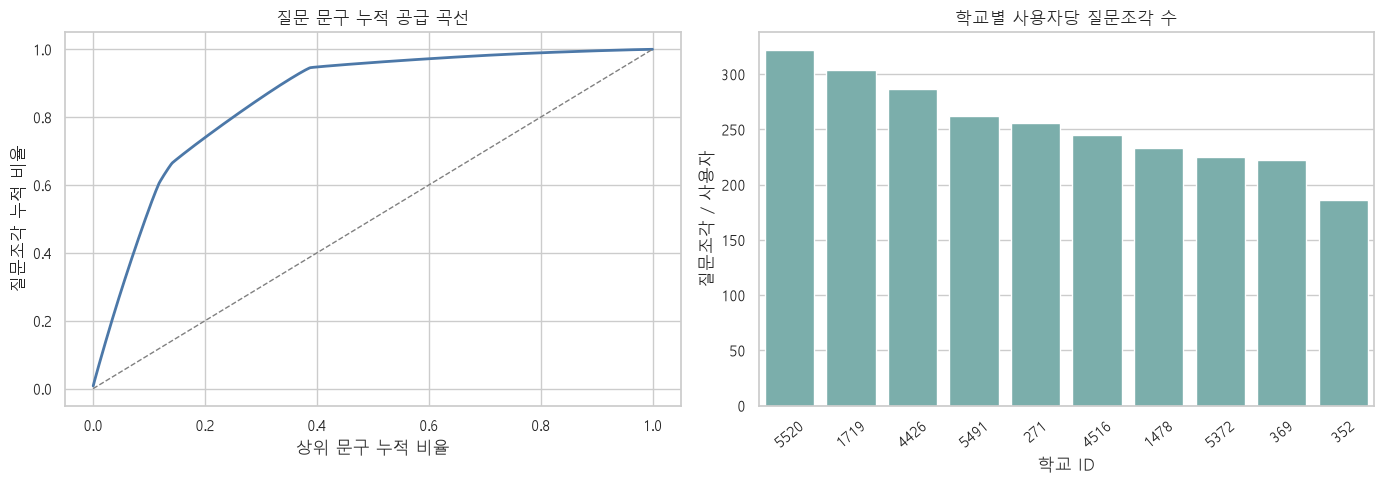

In [5]:
# 질문세트와 학교별 기초 구조를 먼저 확인한다.
qset_basic=con.execute("""
SELECT question_set_status_label status,
       COUNT(*) qsets,
       AVG(piece_list_length_recalc) avg_piece_refs,
       AVG(referenced_piece_existing_count) avg_existing_pieces,
       AVG(CAST(complete_10_piece_reference_flag AS DOUBLE)) complete_10_reference_rate,
       MEDIAN(opening_delay_seconds_recalc) median_opening_delay_seconds
FROM qset
WHERE analysis_eligible_question_set_flag=1
GROUP BY 1 ORDER BY qsets DESC
""").df()
school_basic=(piece.groupby('school_id').agg(
    users=('owner_user_id','nunique'), qsets=('question_set_id','nunique'), pieces=('question_piece_id','size'),
    question_ids=('question_id','nunique'), normalized_texts=('question_text_normalized','nunique'),
    vote_record_rate=('vote_record_exists','mean'), first_at=('piece_created_at','min'), last_at=('piece_created_at','max')
).reset_index())
school_basic['pieces_per_user']=school_basic.pieces/school_basic.users
school_basic['texts_per_1000_pieces']=school_basic.normalized_texts/school_basic.pieces*1000
display(Markdown('**질문세트 상태별 기초 구조**')); display(qset_basic)
display(Markdown('**학교별 공급 규모와 사용자 표준화 지표**')); display(school_basic.sort_values('pieces',ascending=False))
qset_basic.to_csv(OUTPUT_DIR/'qset_basic_structure.csv',index=False,encoding='utf-8-sig')
school_basic.to_csv(OUTPUT_DIR/'school_content_baseline.csv',index=False,encoding='utf-8-sig')

# 공급 편중을 누적 곡선과 상위 문구 점유율로 확인한다.
freq=text_freq.groupby('question_text_normalized').piece_count.sum().sort_values(ascending=False)
cum=freq.cumsum()/freq.sum(); x=np.arange(1,len(freq)+1)/len(freq)
pareto=pd.DataFrame({'rank':np.arange(1,len(freq)+1),'text_share':x,'cumulative_piece_share':cum.values})
pareto_points=[]
for pct in [.01,.05,.10,.20]:
    n=max(1,int(np.ceil(len(freq)*pct)))
    pareto_points.append({'top_text_share':pct,'text_count':n,'piece_share':freq.iloc[:n].sum()/freq.sum()})
pareto_points=pd.DataFrame(pareto_points)
display(pareto_points)
fig,ax=plt.subplots(1,2,figsize=(14,5))
ax[0].plot(x,cum.values,color='#4C78A8',lw=2); ax[0].plot([0,1],[0,1],'--',color='gray',lw=1)
ax[0].set(title='질문 문구 누적 공급 곡선',xlabel='상위 문구 누적 비율',ylabel='질문조각 누적 비율')
sns.barplot(data=school_basic.sort_values('pieces_per_user',ascending=False),x='school_id',y='pieces_per_user',color='#72B7B2',ax=ax[1])
ax[1].set(title='학교별 사용자당 질문조각 수',xlabel='학교 ID',ylabel='질문조각 / 사용자'); ax[1].tick_params(axis='x',rotation=40)
plt.tight_layout(); plt.savefig(FIG_DIR/'01a_supply_concentration_school.png',dpi=160,bbox_inches='tight'); plt.show()
pareto.to_csv(OUTPUT_DIR/'question_supply_pareto_curve.csv',index=False,encoding='utf-8-sig')
pareto_points.to_csv(OUTPUT_DIR/'question_supply_top_share.csv',index=False,encoding='utf-8-sig')

,month,pieces,qsets,users,question_ids,normalized_texts,vote_rate,skip_history_rate,texts_active,new_texts,new_text_share
0,2023-04,33651,4116,350,227,227,0.995661,0.000119,227,227,1.000000
1,2023-05,1144964,141717,4907,1536,1513,0.975259,0.000669,1513,1286,0.849967
2,2023-06,74466,9285,1797,4429,3894,0.818320,0.003599,3894,2384,0.612224
3,2023-07,6040,691,359,3497,2943,0.583609,0.006788,2943,1,0.000340
4,2023-08,2273,262,152,1784,1626,0.567532,0.002200,1626,0,0.000000
5,2023-09,2054,226,159,1530,1510,0.368062,0.008763,1510,0,0.000000
6,2023-10,452,48,41,416,412,0.207965,0.013274,412,0,0.000000
7,2023-11,306,36,20,289,285,0.581699,0.000000,285,0,0.000000
8,2023-12,555,69,25,512,508,0.657658,0.000000,508,0,0.000000
9,2024-01,309,44,19,296,293,0.469256,0.048544,293,0,0.000000


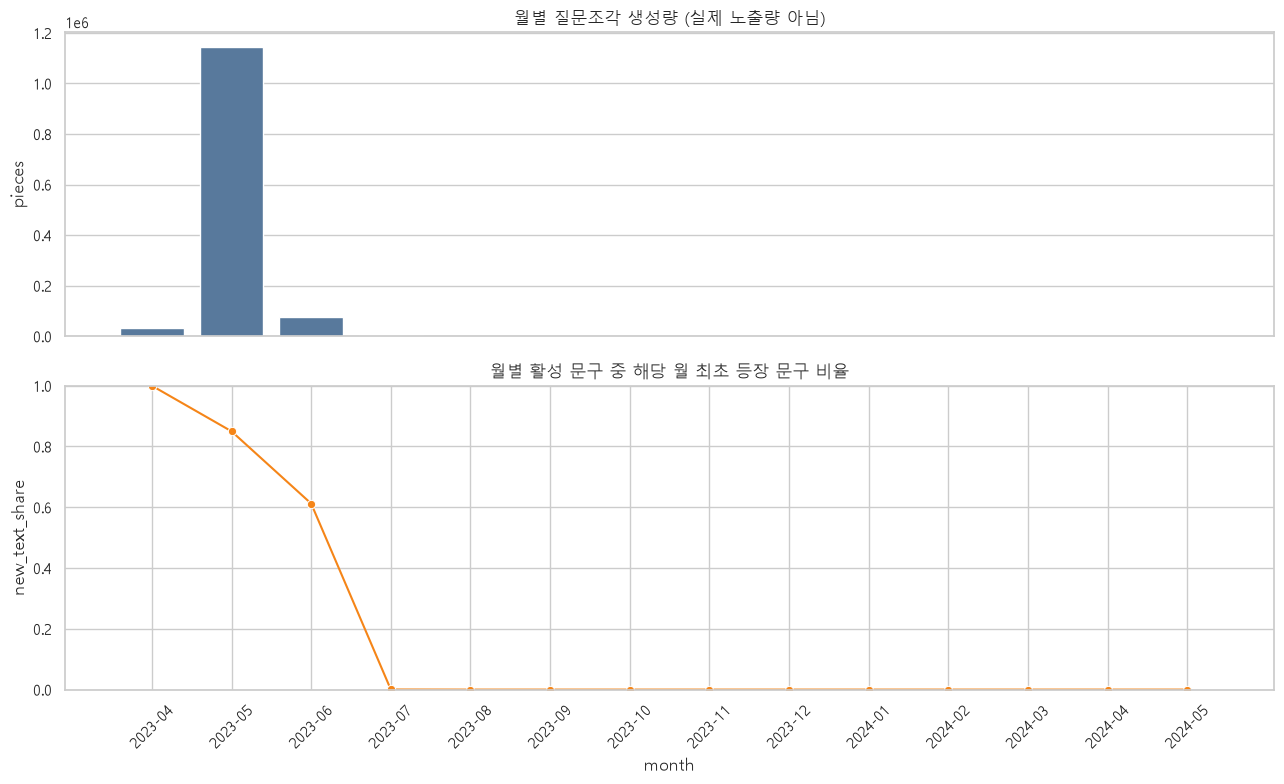

In [6]:
monthly = (piece.groupby('month').agg(
    pieces=('question_piece_id','size'), qsets=('question_set_id','nunique'), users=('owner_user_id','nunique'),
    question_ids=('question_id','nunique'), normalized_texts=('question_text_normalized','nunique'),
    vote_rate=('vote_record_exists','mean'), skip_history_rate=('raw_is_skipped','mean')
).reset_index())

first_text_month = piece.groupby('question_text_normalized')['month'].min()
piece['text_first_month'] = piece['question_text_normalized'].map(first_text_month)
new_monthly = (piece[['month','question_text_normalized','text_first_month']].drop_duplicates()
               .assign(is_new=lambda d: d.month.eq(d.text_first_month))
               .groupby('month').agg(texts_active=('question_text_normalized','size'), new_texts=('is_new','sum')).reset_index())
new_monthly['new_text_share'] = new_monthly.new_texts/new_monthly.texts_active
monthly = monthly.merge(new_monthly, on='month', how='left')
display(monthly)
monthly.to_csv(OUTPUT_DIR/'monthly_question_supply.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(2,1,figsize=(13,8), sharex=True)
sns.barplot(data=monthly, x='month', y='pieces', color='#4C78A8', ax=ax[0])
ax[0].set_title('월별 질문조각 생성량 (실제 노출량 아님)'); ax[0].set_xlabel(''); ax[0].tick_params(axis='x', rotation=45)
sns.lineplot(data=monthly, x='month', y='new_text_share', marker='o', color='#F58518', ax=ax[1])
ax[1].set_title('월별 활성 문구 중 해당 월 최초 등장 문구 비율'); ax[1].set_ylim(0,1); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig(FIG_DIR/'01_monthly_supply_novelty.png', dpi=160, bbox_inches='tight'); plt.show()

In [7]:
def hhi_from_counts(s):
    p = s/s.sum()
    return float((p**2).sum())

def normalized_entropy(s):
    p=(s/s.sum()).values
    if len(p)<=1: return 0.0
    return float(stats.entropy(p)/np.log(len(p)))

concentration = []
for month, g in piece.groupby('month'):
    cnt = g.question_text_normalized.value_counts()
    concentration.append({'month':month,'hhi':hhi_from_counts(cnt),'normalized_entropy':normalized_entropy(cnt),
                          'top10_share':cnt.head(10).sum()/cnt.sum(),'texts':len(cnt)})
concentration = pd.DataFrame(concentration)
display(concentration)
concentration.to_csv(OUTPUT_DIR/'monthly_content_concentration.csv', index=False, encoding='utf-8-sig')

,month,hhi,normalized_entropy,top10_share,texts
0,2023-04,0.004454,0.998979,0.054174,227
1,2023-05,0.001067,0.964632,0.023044,1513
2,2023-06,0.000493,0.968787,0.019861,3894
3,2023-07,0.000521,0.978576,0.019205,2943
4,2023-08,0.000812,0.985049,0.025517,1626
5,2023-09,0.000847,0.986705,0.026777,1510
6,2023-10,0.002633,0.994504,0.048673,412
7,2023-11,0.003845,0.994300,0.075163,285
8,2023-12,0.002139,0.994603,0.045045,508
9,2024-01,0.003592,0.996425,0.067961,293


### 2.2 형태소와 정확 중복

정규화 문구와 Kiwi 형태소로 표면 중복을 확인한다.


In [8]:
unique_text = (piece.groupby('question_text_normalized')
               .agg(question_text=('question_text','first'), piece_count=('question_piece_id','size'),
                    question_id_count=('question_id','nunique'), users=('owner_user_id','nunique'),
                    first_at=('piece_created_at','min'), last_at=('piece_created_at','max'))
               .reset_index())

kiwi = Kiwi()
KEEP_TAG_PREFIX = ('N','V','MA','XR','SL')
def kiwi_tokens(text):
    toks=[]
    for token in kiwi.tokenize(text):
        if token.tag.startswith(KEEP_TAG_PREFIX) and len(token.form) >= 1:
            toks.append(token.form)
    return toks

unique_text['tokens'] = unique_text.question_text_normalized.map(kiwi_tokens)
unique_text['token_text'] = unique_text.tokens.map(lambda x:' '.join(x))
all_terms = Counter()
for toks, w in zip(unique_text.tokens, unique_text.piece_count):
    all_terms.update({t:int(w)*c for t,c in Counter(toks).items()})
term_df = pd.DataFrame(all_terms.most_common(100), columns=['term','weighted_count'])
display(term_df.head(30))
term_df.to_csv(OUTPUT_DIR/'kiwi_weighted_terms_top100.csv',index=False,encoding='utf-8-sig')

exact = (piece.groupby('question_text_normalized').agg(
    rows=('question_piece_id','size'), question_ids=('question_id','nunique'), example=('question_text','first')
).reset_index())
exact['multi_id_same_text'] = exact.question_ids.gt(1)
exact_summary = pd.DataFrame({
    'metric':['정규화 고유 문구','둘 이상 질문 ID가 같은 문구','그 문구가 차지한 질문조각 비율'],
    'value':[len(exact), int(exact.multi_id_same_text.sum()),
             exact.loc[exact.multi_id_same_text,'rows'].sum()/exact.rows.sum()]
})
display(exact_summary)
display(exact.sort_values(['question_ids','rows'],ascending=False).head(20))
exact_summary.to_csv(OUTPUT_DIR/'exact_duplicate_overview.csv',index=False,encoding='utf-8-sig')
exact.sort_values(['question_ids','rows'],ascending=False).to_csv(OUTPUT_DIR/'exact_duplicate_text_detail.csv',index=False,encoding='utf-8-sig')
unique_text.drop(columns=['tokens']).to_csv(OUTPUT_DIR/'unique_question_text_features_base.csv', index=False, encoding='utf-8-sig')

,term,weighted_count
0,사람,1009056
1,같,605907
2,것,543329
3,가장,345160
4,친구,230775
5,잘,188464
6,싶,174124
7,하,171331
8,제일,131607
9,있,113263


,metric,value
0,정규화 고유 문구,3898.000000
1,둘 이상 질문 ID가 같은 문구,988.000000
2,그 문구가 차지한 질문조각 비율,0.055566


,question_text_normalized,rows,question_ids,example,multi_id_same_text
84,vote,10169,55,vote,True
23,2세가 가장 귀여울 것 같은 사람은,2228,3,2세가 가장 귀여울 것 같은 사람은?,True
1098,눈이 제일 큰 사람은,788,3,눈이 제일 큰 사람은?,True
428,같이 밥먹고 싶은 사람은,385,3,같이 밥먹고 싶은 사람은?,True
3181,지금 뭐하는지 궁금한 친구,55,3,지금 뭐하는지 궁금한 친구,True
2826,인생 2회차인 것 같은 사람은,51,3,인생 2회차인 것 같은 사람은?,True
496,같이 캠핑가고 싶은 사람은,2169,2,같이 캠핑가고 싶은 사람은?,True
1252,라면 잘 끓일 것 같은 사람은,2157,2,라면 잘 끓일 것 같은 사람은?,True
125,가장 깔끔할 것 같은 친구는,1998,2,가장 깔끔할 것 같은 친구는?,True
286,가장 잘생긴 사람은,1959,2,가장 잘생긴 사람은?,True


### 2.3 의미 중복과 테마

Sentence-BERT 임베딩으로 의미 유사도와 테마 구조를 확인한다. 유사도 임계값은 0.85·0.90·0.95를 함께 사용한다.


In [9]:
emb_path = CACHE_DIR/'ko_sroberta_question_embeddings.npz'
if emb_path.exists():
    cache = np.load(emb_path, allow_pickle=True)
    cached_texts = cache['texts'].tolist()
    if cached_texts == unique_text.question_text_normalized.tolist():
        embeddings = cache['embeddings']
        print('캐시된 임베딩 사용:', embeddings.shape)
    else:
        emb_path.unlink(); embeddings = None
else:
    embeddings = None

if embeddings is None:
    model = SentenceTransformer(MODEL_NAME)
    embeddings = model.encode(unique_text.question_text.tolist(), batch_size=64, show_progress_bar=True,
                              normalize_embeddings=True, convert_to_numpy=True)
    np.savez_compressed(emb_path, texts=np.array(unique_text.question_text_normalized.tolist(), dtype=object), embeddings=embeddings)
print('임베딩:', embeddings.shape)

캐시된 임베딩 사용: (3898, 768)
임베딩: (3898, 768)


In [10]:
# 3,904개 수준에서는 전체 코사인 행렬을 계산해 임계값 이상 쌍을 빠짐없이 확인할 수 있다.
sim = embeddings @ embeddings.T
np.fill_diagonal(sim, -1)
nearest_idx = sim.argmax(axis=1)
nearest_sim = sim[np.arange(len(sim)), nearest_idx]
unique_text['nearest_text'] = unique_text.question_text.iloc[nearest_idx].values
unique_text['nearest_cosine'] = nearest_sim

def semantic_components(similarity, threshold):
    n=len(similarity); parent=np.arange(n)
    def find(x):
        while parent[x]!=x:
            parent[x]=parent[parent[x]]; x=parent[x]
        return x
    def union(a,b):
        ra,rb=find(a),find(b)
        if ra!=rb: parent[rb]=ra
    ii,jj=np.where(np.triu(similarity,1)>=threshold)
    for a,b in zip(ii,jj): union(int(a),int(b))
    roots=[find(i) for i in range(n)]
    relabel={r:k for k,r in enumerate(sorted(set(roots)))}
    return np.array([relabel[r] for r in roots]), len(ii)

semantic_rows=[]
for th in [0.85,0.90,0.95]:
    groups, pair_n = semantic_components(sim, th)
    sizes=pd.Series(groups).value_counts()
    multi=set(sizes[sizes>1].index)
    in_multi=np.array([g in multi for g in groups])
    weighted_share=unique_text.loc[in_multi,'piece_count'].sum()/unique_text.piece_count.sum()
    semantic_rows.append({'threshold':th,'similar_pairs':pair_n,'multi_text_components':len(multi),
                          'unique_texts_in_component':int(in_multi.sum()),'piece_weighted_share':weighted_share})
    if th==0.90:
        unique_text['semantic_group_090']=groups
semantic_sensitivity=pd.DataFrame(semantic_rows)
display(semantic_sensitivity)
semantic_sensitivity.to_csv(OUTPUT_DIR/'semantic_duplicate_threshold_sensitivity.csv',index=False,encoding='utf-8-sig')

pairs=[]
ii,jj=np.where(np.triu(sim,1)>=0.90)
for a,b in zip(ii,jj):
    pairs.append((float(sim[a,b]),unique_text.question_text.iloc[a],unique_text.question_text.iloc[b],
                  int(unique_text.piece_count.iloc[a]),int(unique_text.piece_count.iloc[b])))
pair_df=pd.DataFrame(pairs,columns=['cosine','question_a','question_b','count_a','count_b']).sort_values('cosine',ascending=False)
display(pair_df.head(30))
pair_df.to_csv(OUTPUT_DIR/'semantic_similar_question_pairs_090.csv',index=False,encoding='utf-8-sig')

,threshold,similar_pairs,multi_text_components,unique_texts_in_component,piece_weighted_share
0,0.85,882,349,1040,0.329026
1,0.90,315,220,505,0.178417
2,0.95,82,77,158,0.063251


,cosine,question_a,question_b,count_a,count_b
149,1.000000,누나 /언니가 있을 것 같은 사람,누나/언니가 있을 것 같은 사람,39,27
294,0.999119,체육대회 때 이인삼각 뛴다면 누구랑 뛰고 싶어?,체육대회때 이인삼각 뛴다면 누구랑 뛰고 싶어?,38,378
193,0.998964,생일파티 때 꼭 부르고 싶은 사람은?,생일파티때 꼭 부르고 싶은 사람은?,45,31
254,0.998046,윙크 제일 잘 할 것 같은 사람은?,윙크 제일 잘할 것 같은 사람은?,359,50
64,0.997795,같이 동물원 가고 싶은 사람은?,같이 동물원 가고싶은 사람은?,386,19
280,0.997337,졸업식 때 가장 많이 울 것 같은 사람,졸업식때 가장 많이 울 것 같은 사람,402,35
313,0.996848,화나면 가장 무서울 것 같은 사람은?,화나면 가장 무서울 것 같을 사람은?,1835,366
189,0.996587,사진 잘 찍어줄 것 같은 사람은?,사진을 잘 찍어줄 것 같은 사람은?,38,383
83,0.995075,같이 코인노래방 가고 싶은 사람은?,같이 코인노래방을 가고 싶은 사람은?,343,1569
60,0.993036,같이 꽃구경 가고 싶은 사람?,같이 꽃구경 가고 싶은 사람은?,33,322


In [11]:
# PCA로 잡음을 줄인 뒤 K 후보를 같은 조건에서 비교한다.
pca = PCA(n_components=min(50, embeddings.shape[1]), random_state=RANDOM_STATE)
emb50 = pca.fit_transform(embeddings)
k_scores=[]
models={}
for k in [6,8,10,12,14,16]:
    km=MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=512, n_init=20)
    labels=km.fit_predict(emb50)
    score=silhouette_score(emb50,labels,sample_size=min(3000,len(labels)),random_state=RANDOM_STATE)
    k_scores.append({'k':k,'silhouette':score})
    models[k]=(km,labels)
k_scores=pd.DataFrame(k_scores)
best_k=int(k_scores.loc[k_scores.silhouette.idxmax(),'k'])
theme_model, theme_labels=models[best_k]
unique_text['theme_id']=theme_labels
display(k_scores)
print('선택된 테마 수:', best_k)
k_scores.to_csv(OUTPUT_DIR/'bert_theme_k_selection.csv',index=False,encoding='utf-8-sig')

vectorizer=TfidfVectorizer(token_pattern=r'(?u)\b\w+\b',min_df=2,max_df=0.95)
X=vectorizer.fit_transform(unique_text.token_text)
terms=np.array(vectorizer.get_feature_names_out())
theme_rows=[]
for t in sorted(unique_text.theme_id.unique()):
    idx=np.where(theme_labels==t)[0]
    mean_tfidf=np.asarray(X[idx].mean(axis=0)).ravel()
    top_terms=terms[mean_tfidf.argsort()[-10:][::-1]].tolist()
    center=theme_model.cluster_centers_[t]
    d=np.linalg.norm(emb50[idx]-center,axis=1)
    reps=unique_text.question_text.iloc[idx[np.argsort(d)[:3]]].tolist()
    theme_rows.append({'theme_id':int(t),'unique_texts':len(idx),
                       'piece_count':int(unique_text.piece_count.iloc[idx].sum()),
                       'top_terms':' / '.join(top_terms),'representative_questions':' | '.join(reps)})
theme_summary=pd.DataFrame(theme_rows).sort_values('piece_count',ascending=False)
display(theme_summary)
theme_summary.to_csv(OUTPUT_DIR/'bert_theme_summary.csv',index=False,encoding='utf-8-sig')

,k,silhouette
0,6,0.047795
1,8,0.038807
2,10,0.048572
3,12,0.048225
4,14,0.050542
5,16,0.043950


선택된 테마 수: 14


,theme_id,unique_texts,piece_count,top_terms,representative_questions
1,1,373,198927,사람 / 가장 / 어울리 / 잘 / 제일 / 예쁘 / 이 / 것 / 같 / 좋,위아래 색깔 매치가 좋은 사람은? | 빨간머리가 가장 잘 어울릴 것 같은 사람은? ...
10,10,364,151038,사람 / 주 / 나 / 있 / 싶 / 같 / 것 / 보 / 이 / 하,이 사람이 내가 아는 사람이서 다행이라고 생각되는 사람은? | 기대고 싶은 사람은?...
4,4,485,131403,친구 / 가장 / 같 / 것 / 잘 / 하 / 이 / 제일 / 어울리 / 있,가장 인싸일 것 같은 친구는? | 가장 쩝쩝박사일 것 같은 친구는? | 얘랑 친구라...
11,11,306,129586,같 / 사람 / 것 / 가장 / 잘 / 하 / 가깝 / 학교 / 공부 / 제일,과제를 제일 성실히 할 것 같은 사람은? | 의사라는 직업이 가장 잘 어울리는 사람...
6,6,344,126264,같 / 가장 / 사람 / 것 / 많이 / 제일 / 많 / 이 / 나 / 때,가장 전애인 생각할 사람은? | 이름 셔플을 가장 많이 사용할 것 같은 사람은? |...
9,9,289,88996,사람 / 것 / 같 / 잘 / 하 / 가장 / 이 / 제일 / 게임 / 있,제일 금사빠일 것 같은 사람은? | 팩폭 가장 잘 날릴 것 같은 사람은? | 사격을...
8,8,316,70299,사람 / 같 / 것 / 잘 / 어울리 / 이 / 가장 / 있 / 나 / 제일,봄웜톤일 것 같은 사람 | 이중에 계속 내눈에 보이는 사람 | 알고보니 인간행세하는...
7,7,248,69679,사람 / 것 / 같 / 연애 / 싶 / 하 / 가장 / 결혼 / 애인 / 친구,여친이나 남친으로 가장 좋을 것 같은 사람은? | 가장 연애 하고 싶어 보이는 사람...
5,5,175,60896,같이 / 싶 / 가 / 사람 / 보 / 하 / 여행 / 친구 / 놀 / 둘,같이 캠핑을 가보고 싶은 사람은? | 같이 캠핑가고 싶은 사람은? | 같이 야구를 ...
0,0,183,57227,먹 / 것 / 같 / 사람 / 잘 / 밥 / 주 / 좋아하 / 친구 / 싶,바나나 먹다가 드립칠 것 같은 사람은? | 치킨 중독인 것 같은 사람은? | 내가 ...


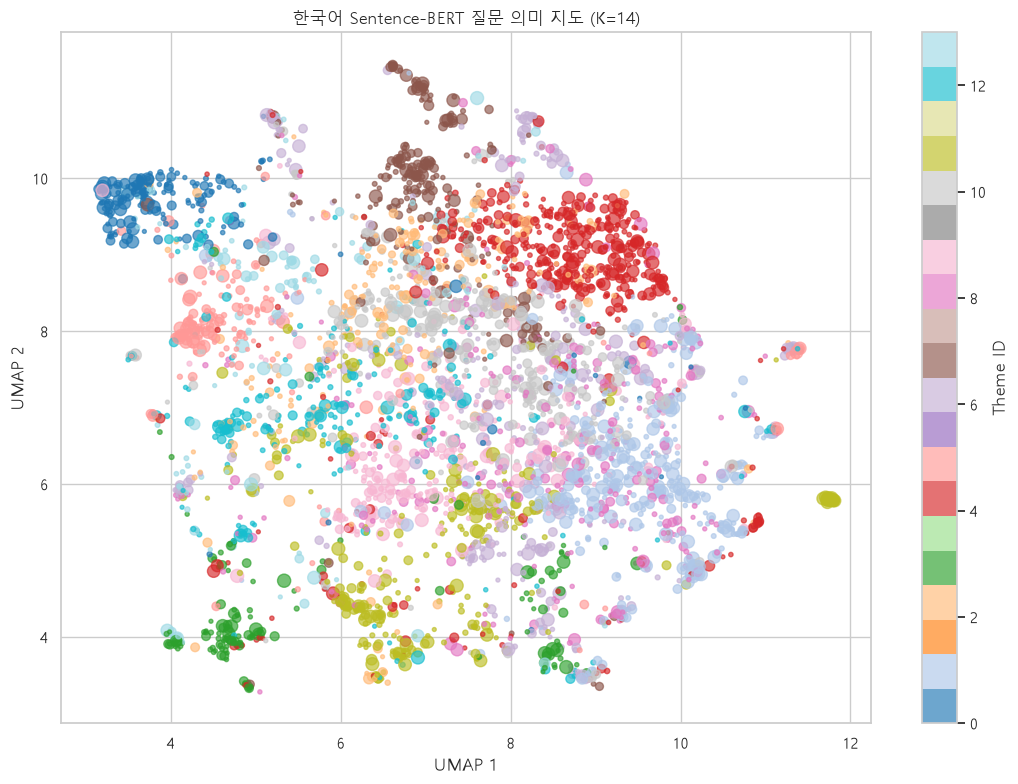

In [12]:
reducer=umap.UMAP(n_neighbors=25,min_dist=0.15,metric='cosine',random_state=RANDOM_STATE)
xy=reducer.fit_transform(embeddings)
unique_text['umap_x']=xy[:,0]; unique_text['umap_y']=xy[:,1]

fig,ax=plt.subplots(figsize=(11,8))
sc=ax.scatter(unique_text.umap_x,unique_text.umap_y,c=unique_text.theme_id,cmap='tab20',
              s=np.clip(np.sqrt(unique_text.piece_count)*2,8,100),alpha=.65)
ax.set_title(f'한국어 Sentence-BERT 질문 의미 지도 (K={best_k})')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
plt.colorbar(sc,ax=ax,label='Theme ID')
plt.tight_layout(); plt.savefig(FIG_DIR/'02_bert_theme_map.png',dpi=170,bbox_inches='tight'); plt.show()

text_to_theme=unique_text.set_index('question_text_normalized')['theme_id']
text_to_semgroup=unique_text.set_index('question_text_normalized')['semantic_group_090']
piece['theme_id']=piece.question_text_normalized.map(text_to_theme)
piece['semantic_group_090']=piece.question_text_normalized.map(text_to_semgroup)
unique_text.drop(columns=['tokens']).to_csv(OUTPUT_DIR/'unique_question_text_features_bert.csv',index=False,encoding='utf-8-sig')

,seed_a,seed_b,adjusted_rand_index
count,10.000000,10.000000,10.000000
mean,24.200000,72.600000,0.316991
std,21.806217,29.762766,0.025625
min,7.000000,19.000000,0.271744
25%,7.000000,49.750000,0.306109
50%,19.000000,73.000000,0.315947
75%,36.250000,101.000000,0.325908
max,73.000000,101.000000,0.368734


,first_month,new_texts,median_prior_similarity,p90_prior_similarity,mean_semantic_novelty
0,2023-04,227,0.638347,0.771956,0.367214
1,2023-05,1286,0.707951,0.856975,0.292146
2,2023-06,2384,0.750003,0.890047,0.247606
3,2023-07,1,0.872981,0.872981,0.127019


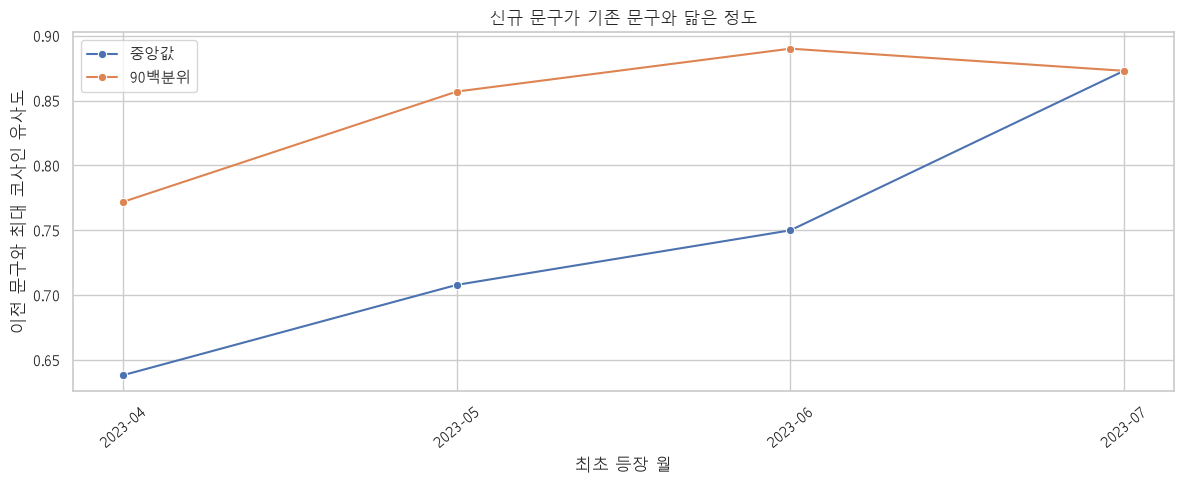

In [13]:
# 테마가 한 번의 랜덤 초기화에만 의존하는지 확인한다.
seed_labels={RANDOM_STATE:theme_labels}
for seed in [7,19,73,101]:
    km_seed=MiniBatchKMeans(n_clusters=best_k,random_state=seed,batch_size=512,n_init=20)
    seed_labels[seed]=km_seed.fit_predict(emb50)
stability=[]
seeds=sorted(seed_labels)
for i,a in enumerate(seeds):
    for b in seeds[i+1:]:
        stability.append({'seed_a':a,'seed_b':b,'adjusted_rand_index':adjusted_rand_score(seed_labels[a],seed_labels[b])})
theme_stability=pd.DataFrame(stability)
display(theme_stability.describe())
theme_stability.to_csv(OUTPUT_DIR/'bert_theme_seed_stability.csv',index=False,encoding='utf-8-sig')

# 각 문구가 처음 등장했을 때 이전에 존재한 문구와 얼마나 비슷했는지 계산한다.
order=np.argsort(pd.to_datetime(unique_text.first_at).values)
prior_max=np.full(len(unique_text),np.nan)
seen=[]
for idx in order:
    if seen:
        prior_max[idx]=float(sim[idx,seen].max())
    seen.append(int(idx))
unique_text['max_similarity_to_prior_text']=prior_max
unique_text['semantic_novelty_to_prior']=1-prior_max
unique_text['first_month']=pd.to_datetime(unique_text.first_at).dt.to_period('M').astype(str)
novelty_month=(unique_text.groupby('first_month').agg(
    new_texts=('question_text_normalized','size'),
    median_prior_similarity=('max_similarity_to_prior_text','median'),
    p90_prior_similarity=('max_similarity_to_prior_text',lambda s:s.quantile(.9)),
    mean_semantic_novelty=('semantic_novelty_to_prior','mean')
).reset_index())
display(novelty_month)
fig,ax=plt.subplots(figsize=(12,5))
sns.lineplot(data=novelty_month,x='first_month',y='median_prior_similarity',marker='o',label='중앙값',ax=ax)
sns.lineplot(data=novelty_month,x='first_month',y='p90_prior_similarity',marker='o',label='90백분위',ax=ax)
ax.set(title='신규 문구가 기존 문구와 닮은 정도',xlabel='최초 등장 월',ylabel='이전 문구와 최대 코사인 유사도')
ax.tick_params(axis='x',rotation=40)
plt.tight_layout(); plt.savefig(FIG_DIR/'02b_new_text_semantic_novelty.png',dpi=160,bbox_inches='tight'); plt.show()
novelty_month.to_csv(OUTPUT_DIR/'monthly_new_text_semantic_novelty.csv',index=False,encoding='utf-8-sig')

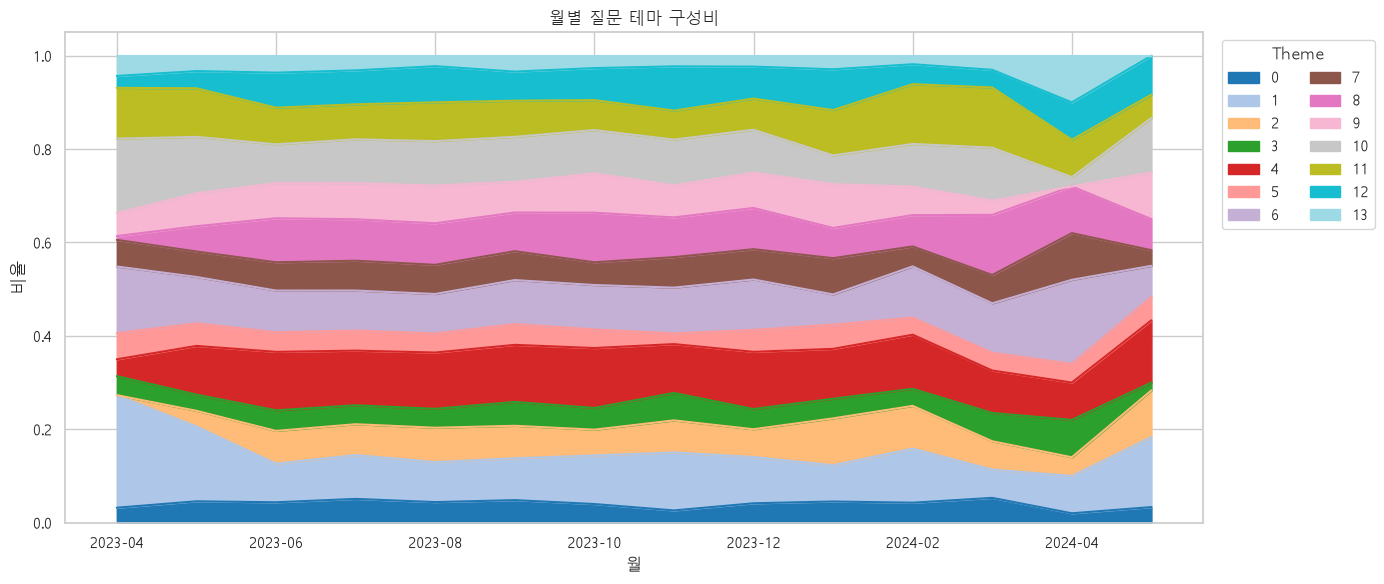

,from_month,to_month,jensen_shannon_distance
12,2024-04,2024-05,0.376484
11,2024-03,2024-04,0.244557
0,2023-04,2023-05,0.199961
1,2023-05,2023-06,0.139645
10,2024-02,2024-03,0.135302
9,2024-01,2024-02,0.131298
8,2023-12,2024-01,0.108527
6,2023-10,2023-11,0.080127
7,2023-11,2023-12,0.078612
5,2023-09,2023-10,0.057892


In [14]:
theme_month=(piece.groupby(['month','theme_id']).size().rename('n').reset_index())
theme_month['share']=theme_month.n/theme_month.groupby('month').n.transform('sum')
pivot=theme_month.pivot(index='month',columns='theme_id',values='share').fillna(0)

fig,ax=plt.subplots(figsize=(14,6))
pivot.plot(kind='area',stacked=True,cmap='tab20',ax=ax)
ax.set_title('월별 질문 테마 구성비'); ax.set_ylabel('비율'); ax.set_xlabel('월')
ax.legend(title='Theme',bbox_to_anchor=(1.01,1),loc='upper left',ncol=2)
plt.tight_layout(); plt.savefig(FIG_DIR/'03_monthly_theme_share.png',dpi=160,bbox_inches='tight'); plt.show()

theme_shift=[]
for i in range(1,len(pivot)):
    theme_shift.append({'from_month':pivot.index[i-1],'to_month':pivot.index[i],
                        'jensen_shannon_distance':float(jensenshannon(pivot.iloc[i-1]+1e-12,pivot.iloc[i]+1e-12))})
theme_shift=pd.DataFrame(theme_shift)
display(theme_shift.sort_values('jensen_shannon_distance',ascending=False).head(10))
theme_shift.to_csv(OUTPUT_DIR/'monthly_theme_shift.csv',index=False,encoding='utf-8-sig')

## 3. 질문 반복과 소진

질문 ID, 정규화 문구, 의미군 기준 반복을 사용자 시간순으로 계산한다.


,definition,repeated_rows,repeat_rate
0,동일 질문 ID,234314,0.185159
1,정규화 문구,240776,0.190265
2,의미군(>=0.90),257793,0.203712


,sequence_band,rows,users,exact_repeat_rate,semantic_repeat_rate,vote_rate,skip_history_rate
0,1-10,49717,4972,0.003419,0.004143,0.959290,0.003701
1,11-20,47569,4812,0.021211,0.023250,0.973596,0.001366
2,21-50,135457,4672,0.055125,0.059761,0.975158,0.000952
3,51-100,200394,4332,0.113511,0.121930,0.967105,0.000674
4,101-200,300331,3658,0.191738,0.205010,0.960767,0.000799
5,201-500,393137,2411,0.273345,0.291440,0.955822,0.000755
6,501+,138871,581,0.319260,0.344240,0.960179,0.000554


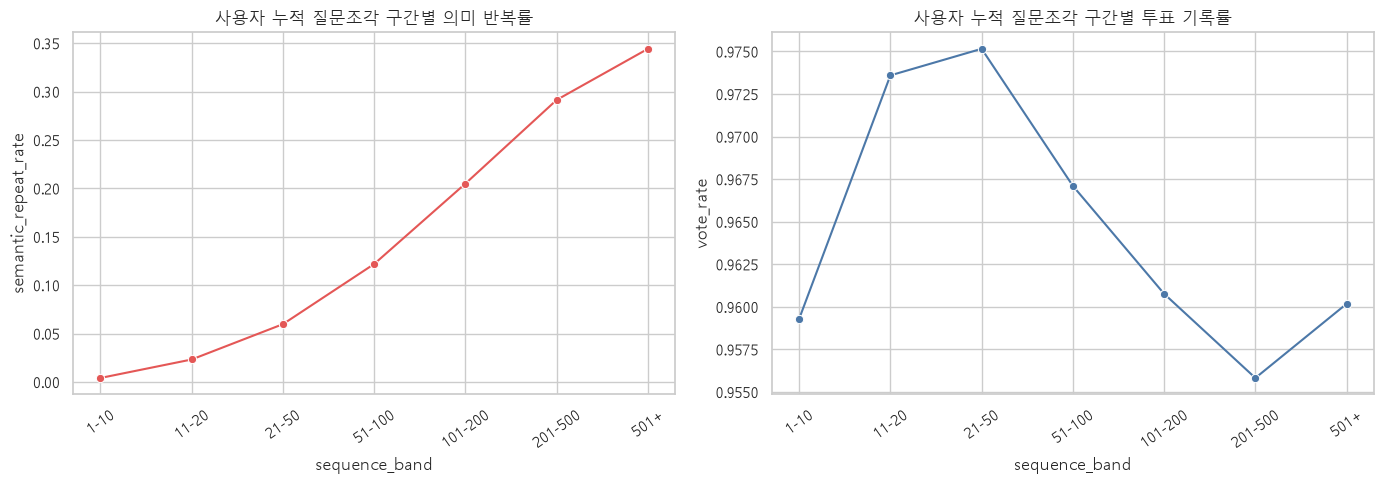

In [15]:
piece=piece.sort_values(['owner_user_id','piece_created_at','question_piece_id']).reset_index(drop=True)
piece['user_question_id_occurrence']=piece.groupby(['owner_user_id','question_id']).cumcount()+1
piece['user_exact_text_occurrence']=piece.groupby(['owner_user_id','question_text_normalized']).cumcount()+1
piece['user_semantic_occurrence']=piece.groupby(['owner_user_id','semantic_group_090']).cumcount()+1
piece['repeat_question_id']=piece.user_question_id_occurrence.gt(1).astype(int)
piece['repeat_exact_text']=piece.user_exact_text_occurrence.gt(1).astype(int)
piece['repeat_semantic_090']=piece.user_semantic_occurrence.gt(1).astype(int)
piece['user_piece_sequence']=piece.groupby('owner_user_id').cumcount()+1

repeat_summary=pd.DataFrame({
    'definition':['동일 질문 ID','정규화 문구','의미군(>=0.90)'],
    'repeated_rows':[piece.repeat_question_id.sum(),piece.repeat_exact_text.sum(),piece.repeat_semantic_090.sum()],
    'repeat_rate':[piece.repeat_question_id.mean(),piece.repeat_exact_text.mean(),piece.repeat_semantic_090.mean()]
})
display(repeat_summary)
repeat_summary.to_csv(OUTPUT_DIR/'user_repeat_definition_summary.csv',index=False,encoding='utf-8-sig')

piece['sequence_band']=pd.cut(piece.user_piece_sequence,[0,10,20,50,100,200,500,np.inf],labels=['1-10','11-20','21-50','51-100','101-200','201-500','501+'])
seq_summary=(piece.groupby('sequence_band',observed=True).agg(
    rows=('question_piece_id','size'), users=('owner_user_id','nunique'), exact_repeat_rate=('repeat_exact_text','mean'),
    semantic_repeat_rate=('repeat_semantic_090','mean'), vote_rate=('vote_record_exists','mean'), skip_history_rate=('raw_is_skipped','mean')
).reset_index())
display(seq_summary)
seq_summary.to_csv(OUTPUT_DIR/'user_sequence_content_metrics.csv',index=False,encoding='utf-8-sig')

fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.lineplot(data=seq_summary,x='sequence_band',y='semantic_repeat_rate',marker='o',ax=ax[0],color='#E45756')
ax[0].set_title('사용자 누적 질문조각 구간별 의미 반복률'); ax[0].tick_params(axis='x',rotation=35)
sns.lineplot(data=seq_summary,x='sequence_band',y='vote_rate',marker='o',ax=ax[1],color='#4C78A8')
ax[1].set_title('사용자 누적 질문조각 구간별 투표 기록률'); ax[1].tick_params(axis='x',rotation=35)
plt.tight_layout(); plt.savefig(FIG_DIR/'04_sequence_repeat_vote.png',dpi=160,bbox_inches='tight'); plt.show()

In [16]:
qset_rep=(piece.dropna(subset=['question_set_id']).groupby(['owner_user_id','question_set_id']).agg(
    positions=('question_piece_id','size'), unique_question_ids=('question_id','nunique'),
    unique_exact_texts=('question_text_normalized','nunique'), unique_semantic_groups=('semantic_group_090','nunique'),
    vote_rate=('vote_record_exists','mean'), skip_history_rate=('raw_is_skipped','mean'), created_at=('piece_created_at','min')
).reset_index())
qset_rep['duplicate_id_within_set']=qset_rep.positions-qset_rep.unique_question_ids
qset_rep['duplicate_exact_within_set']=qset_rep.positions-qset_rep.unique_exact_texts
qset_rep['duplicate_semantic_within_set']=qset_rep.positions-qset_rep.unique_semantic_groups
qset_repeat_describe=qset_rep[['positions','duplicate_id_within_set','duplicate_exact_within_set','duplicate_semantic_within_set']].describe(percentiles=[.5,.9,.95,.99])
display(qset_repeat_describe)
qset_repeat_describe.to_csv(OUTPUT_DIR/'qset_within_repeat_describe.csv',encoding='utf-8-sig')

elapsed_bins=pd.cut(piece.signup_elapsed_days,[-np.inf,-1,0,1,3,7,14,30,60,90,180,np.inf],
                    labels=['음수','0일','1일','2-3일','4-7일','8-14일','15-30일','31-60일','61-90일','91-180일','181일+'])
elapsed=(piece.assign(elapsed_band=elapsed_bins).groupby('elapsed_band',observed=True).agg(
    rows=('question_piece_id','size'), users=('owner_user_id','nunique'), unique_texts=('question_text_normalized','nunique'),
    semantic_repeat_rate=('repeat_semantic_090','mean'), vote_rate=('vote_record_exists','mean')
).reset_index())
display(elapsed)
elapsed.to_csv(OUTPUT_DIR/'signup_elapsed_content_metrics.csv',index=False,encoding='utf-8-sig')

,positions,duplicate_id_within_set,duplicate_exact_within_set,duplicate_semantic_within_set
count,156539.000000,156539.0,156539.000000,156539.000000
mean,8.084094,0.0,0.002191,0.006113
std,2.228824,0.0,0.048370,0.079732
min,1.000000,0.0,0.000000,0.000000
50%,9.000000,0.0,0.000000,0.000000
90%,10.000000,0.0,0.000000,0.000000
95%,10.000000,0.0,0.000000,0.000000
99%,10.000000,0.0,0.000000,0.000000
max,10.000000,0.0,3.000000,3.000000


,elapsed_band,rows,users,unique_texts,semantic_repeat_rate,vote_rate
0,0일,144475,4292,2005,0.046022,0.984239
1,1일,189523,4046,1766,0.135857,0.995193
2,2-3일,288887,4232,1836,0.222616,0.991831
3,4-7일,315580,4064,2574,0.271982,0.978063
4,8-14일,185189,3295,3488,0.269287,0.944154
5,15-30일,107773,2367,3893,0.201405,0.864975
6,31-60일,23511,769,3692,0.101697,0.773680
7,61-90일,5415,332,2810,0.116898,0.556233
8,91-180일,3771,240,2289,0.118801,0.420313
9,181일+,1352,65,1092,0.152367,0.524408


,semantic_occurrence_band,rows,users,vote_rate,skip_history_rate,median_sequence
0,1회,1007683,4972,0.957939,0.001022,138.0
1,2회,193172,4462,0.978480,0.000399,232.0
2,3회,45480,3264,0.978892,0.000352,321.0
3,4-5회,16157,2060,0.980256,0.000186,415.0
4,6-10회,2698,669,0.969607,0.000371,581.5
5,11회+,286,84,0.944056,0.000000,966.5


,users_with_both,mean_within_user_diff,median_within_user_diff,ci95_low,ci95_high,p_value
0,4462,-0.011364,0.010839,-0.01562,-0.007107,1.745574e-07


,matched_strata,rows_in_matched_strata,adjusted_rate_diff,ci95_low,ci95_high,z
0,11360,1173206,0.010713,0.010052,0.011373,31.78876


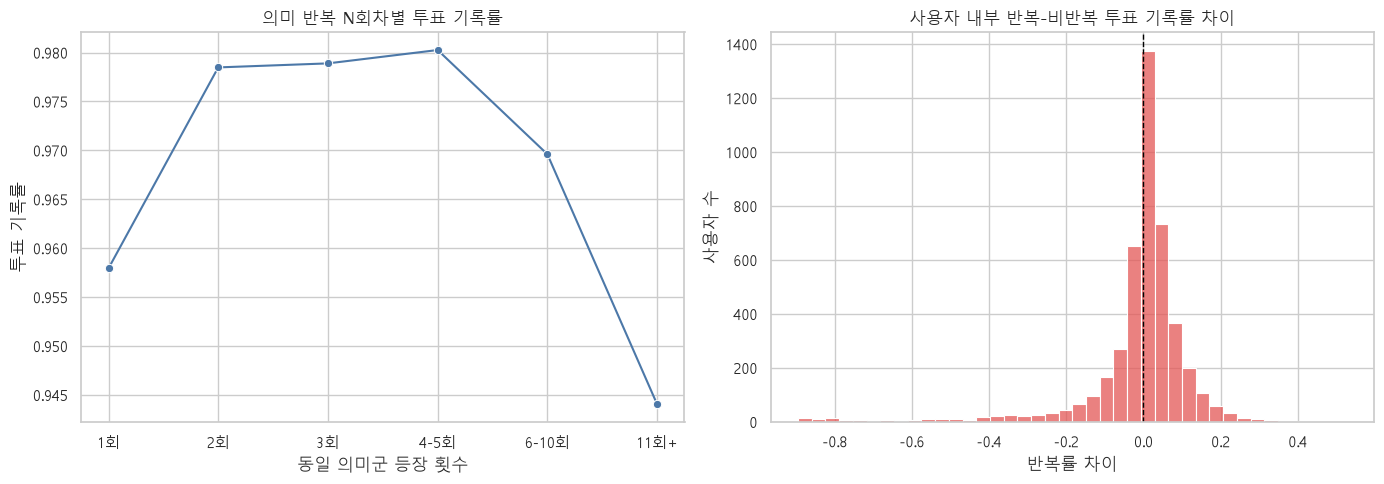

In [17]:
# 반복 N회차와 투표 기록률의 비선형 관계를 확인한다.
piece['semantic_occurrence_band']=pd.cut(piece.user_semantic_occurrence,[0,1,2,3,5,10,np.inf],
                                         labels=['1회','2회','3회','4-5회','6-10회','11회+'])
occurrence_curve=(piece.groupby('semantic_occurrence_band',observed=True).agg(
    rows=('question_piece_id','size'),users=('owner_user_id','nunique'),vote_rate=('vote_record_exists','mean'),
    skip_history_rate=('raw_is_skipped','mean'),median_sequence=('user_piece_sequence','median')
).reset_index())
display(occurrence_curve)

# 사용자마다 반복/비반복 질문을 모두 가진 경우에 한해 사용자 내부 차이를 계산한다.
user_rates=(piece.groupby(['owner_user_id','repeat_semantic_090']).vote_record_exists.mean().unstack())
paired=user_rates.dropna().rename(columns={0:'nonrepeat_rate',1:'repeat_rate'})
paired['within_user_diff']=paired.repeat_rate-paired.nonrepeat_rate
paired_test=stats.ttest_1samp(paired.within_user_diff,0,nan_policy='omit')
within_user_result=pd.DataFrame([{
    'users_with_both':len(paired),'mean_within_user_diff':paired.within_user_diff.mean(),
    'median_within_user_diff':paired.within_user_diff.median(),
    'ci95_low':paired.within_user_diff.mean()-1.96*paired.within_user_diff.std(ddof=1)/np.sqrt(len(paired)),
    'ci95_high':paired.within_user_diff.mean()+1.96*paired.within_user_diff.std(ddof=1)/np.sqrt(len(paired)),
    'p_value':paired_test.pvalue
}])
display(within_user_result)

# 학교·월·테마·위치·사용자 누적구간이 같은 층 안에서 반복/비반복 차이를 다시 계산한다.
strata_cols=['school_id','month','theme_id','question_position','sequence_band']
strata=(piece.groupby(strata_cols+['repeat_semantic_090'],observed=True).agg(
    n=('vote_record_exists','size'),k=('vote_record_exists','sum')
).reset_index())
strata['rate']=strata.k/strata.n
wide=strata.pivot(index=strata_cols,columns='repeat_semantic_090',values=['n','rate']).dropna().reset_index()
wide.columns=['_'.join(map(str,c)).rstrip('_') if isinstance(c,tuple) else c for c in wide.columns]
wide['diff']=wide['rate_1']-wide['rate_0']
wide['weight']=2*wide['n_0']*wide['n_1']/(wide['n_0']+wide['n_1'])
adjusted_diff=np.average(wide['diff'],weights=wide['weight'])
stratum_se=np.sqrt(np.sum((wide.weight**2)*(wide.rate_0*(1-wide.rate_0)/wide.n_0 + wide.rate_1*(1-wide.rate_1)/wide.n_1))/wide.weight.sum()**2)
stratified_result=pd.DataFrame([{
    'matched_strata':len(wide),'rows_in_matched_strata':int((wide.n_0+wide.n_1).sum()),
    'adjusted_rate_diff':adjusted_diff,'ci95_low':adjusted_diff-1.96*stratum_se,
    'ci95_high':adjusted_diff+1.96*stratum_se,'z':adjusted_diff/stratum_se
}])
display(stratified_result)

fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.lineplot(data=occurrence_curve,x='semantic_occurrence_band',y='vote_rate',marker='o',ax=ax[0],color='#4C78A8')
ax[0].set(title='의미 반복 N회차별 투표 기록률',xlabel='동일 의미군 등장 횟수',ylabel='투표 기록률')
sns.histplot(paired.within_user_diff,bins=40,ax=ax[1],color='#E45756')
ax[1].axvline(0,color='black',ls='--',lw=1); ax[1].set(title='사용자 내부 반복-비반복 투표 기록률 차이',xlabel='반복률 차이',ylabel='사용자 수')
plt.tight_layout(); plt.savefig(FIG_DIR/'04b_repeat_deep_checks.png',dpi=160,bbox_inches='tight'); plt.show()
occurrence_curve.to_csv(OUTPUT_DIR/'semantic_occurrence_behavior.csv',index=False,encoding='utf-8-sig')
within_user_result.to_csv(OUTPUT_DIR/'repeat_within_user_comparison.csv',index=False,encoding='utf-8-sig')
stratified_result.to_csv(OUTPUT_DIR/'repeat_stratified_adjustment.csv',index=False,encoding='utf-8-sig')

## 4. 후보 품질

후보 수, 중복, 자기 자신, 현재 친구·학교·학년·반 관계를 확인한다. 후보 원천이 없는 행을 화면에 후보가 없었던 것으로 해석하지 않는다.


**후보 원천 관측 여부 × 투표 기록 여부**

vote_record_exists,0,1
candidate_source_observed,,
0,47887,0
1,31,1217558


,metric,rows,denominator,denominator_n,rate
0,후보 원천 미관측(전체 질문조각 기준),47887,전체 질문조각,1265476,0.037841
1,후보 중복 존재,133,후보 원천 관측 질문조각,1217589,0.000109
2,자기 자신 포함,4802,후보 원천 관측 질문조각,1217589,0.003944
3,현재 친구 포함,1217405,후보 원천 관측 질문조각,1217589,0.999849
4,현재 상호친구 포함,1217303,후보 원천 관측 질문조각,1217589,0.999765
5,같은 학교 포함,1206289,후보 원천 관측 질문조각,1217589,0.990719
6,같은 학년 포함,1203912,후보 원천 관측 질문조각,1217589,0.988767
7,같은 반 포함,832816,후보 원천 관측 질문조각,1217589,0.683988
8,현재 관계상 모르는 후보만,9,후보 원천 관측 질문조각,1217589,0.000007


,candidate_count_band,rows,users,selected_record_rate,skip_history_rate,friend_available_rate,self_candidate_rate,unknown_only_rate
0,1,40,30,1.000000,0.000000,1.0,0.0,0.0
1,2,3039,1112,0.999671,0.000000,0.999013,0.001645,0.0
2,3,95138,3604,0.999685,0.000000,0.999674,0.003752,0.000011
3,4-5,1119368,4845,1.000000,0.000026,0.999866,0.003967,0.000007
4,6-10,4,4,1.000000,0.000000,1.0,0.0,0.0


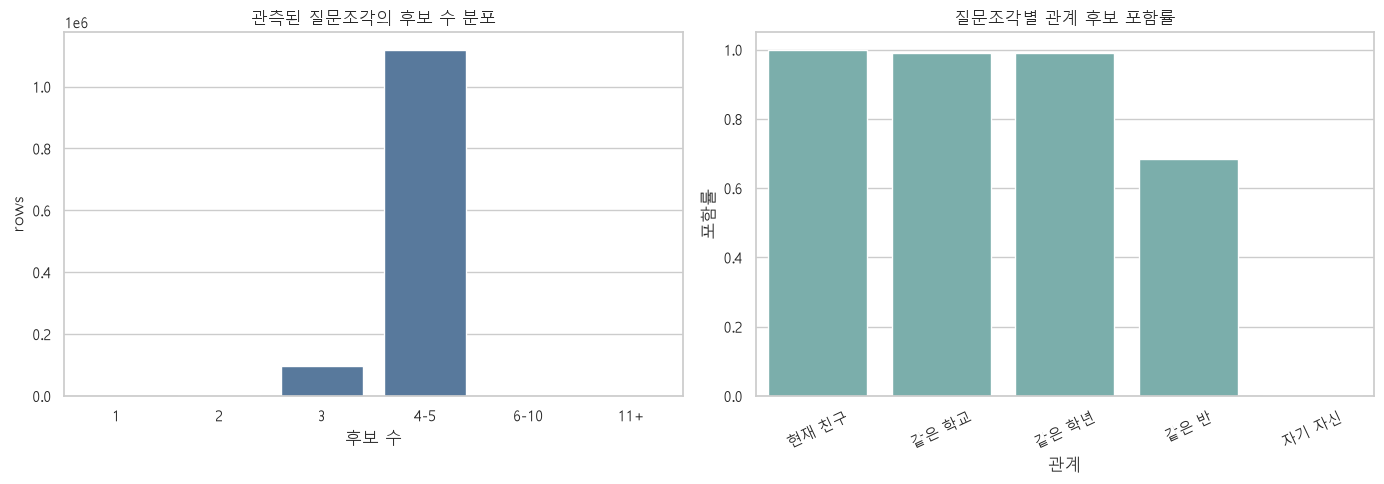

In [18]:
observability=pd.crosstab(piece.candidate_source_observed,piece.vote_record_exists,
                         rownames=['candidate_source_observed'],colnames=['vote_record_exists']).reindex(index=[0,1],columns=[0,1],fill_value=0)
display(Markdown('**후보 원천 관측 여부 × 투표 기록 여부**'))
display(observability)
observability.to_csv(OUTPUT_DIR/'candidate_observability_by_vote.csv',encoding='utf-8-sig')

candidate_observed=piece[piece.candidate_source_observed.eq(1)].copy()
candidate_summary=pd.DataFrame({
    'metric':['후보 원천 미관측(전체 질문조각 기준)','후보 중복 존재','자기 자신 포함','현재 친구 포함','현재 상호친구 포함','같은 학교 포함','같은 학년 포함','같은 반 포함','현재 관계상 모르는 후보만'],
    'rows':[(piece.candidate_source_observed==0).sum(),candidate_observed.has_duplicate_candidate.sum(),candidate_observed.has_self_candidate.sum(),
            candidate_observed.has_current_friend_candidate.sum(),candidate_observed.has_mutual_friend_candidate.sum(),candidate_observed.has_same_school_candidate.sum(),
            candidate_observed.has_same_grade_candidate.sum(),candidate_observed.has_same_class_candidate.sum(),candidate_observed.unknown_only_current_proxy.sum()],
    'denominator':['전체 질문조각']+['후보 원천 관측 질문조각']*8
})
candidate_summary['denominator_n']=[len(piece)]+[len(candidate_observed)]*8
candidate_summary['rate']=candidate_summary.rows/candidate_summary.denominator_n
display(candidate_summary)
candidate_summary.to_csv(OUTPUT_DIR/'candidate_quality_summary.csv',index=False,encoding='utf-8-sig')

candidate_band=(candidate_observed.groupby('candidate_count_band',observed=True).agg(
    rows=('question_piece_id','size'), users=('owner_user_id','nunique'), selected_record_rate=('vote_record_exists','mean'),
    skip_history_rate=('raw_is_skipped','mean'), friend_available_rate=('has_current_friend_candidate','mean'),
    self_candidate_rate=('has_self_candidate','mean'), unknown_only_rate=('unknown_only_current_proxy','mean')
).reset_index())
display(candidate_band)
candidate_band.to_csv(OUTPUT_DIR/'candidate_count_band_metrics.csv',index=False,encoding='utf-8-sig')

fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.barplot(data=candidate_band,x='candidate_count_band',y='rows',color='#4C78A8',ax=ax[0])
ax[0].set_title('관측된 질문조각의 후보 수 분포'); ax[0].set_xlabel('후보 수')
rel_plot=pd.DataFrame({'관계':['현재 친구','같은 학교','같은 학년','같은 반','자기 자신'],
                       '포함률':[candidate_observed.has_current_friend_candidate.mean(),candidate_observed.has_same_school_candidate.mean(),
                               candidate_observed.has_same_grade_candidate.mean(),candidate_observed.has_same_class_candidate.mean(),candidate_observed.has_self_candidate.mean()]})
sns.barplot(data=rel_plot,x='관계',y='포함률',color='#72B7B2',ax=ax[1])
ax[1].set_title('질문조각별 관계 후보 포함률'); ax[1].tick_params(axis='x',rotation=25)
plt.tight_layout(); plt.savefig(FIG_DIR/'05_candidate_quality.png',dpi=160,bbox_inches='tight'); plt.show()

,relation,pool_share,chosen_share,selection_enrichment_pp
0,현재 친구,0.983331,0.992280,0.894965
1,상호 친구,0.981107,0.990847,0.973997
2,같은 학교,0.862249,0.861467,-0.078249
3,같은 학년,0.844616,0.847597,0.298170
4,같은 반,0.299181,0.306310,0.712913
5,자기 자신,0.001007,0.001609,0.060205


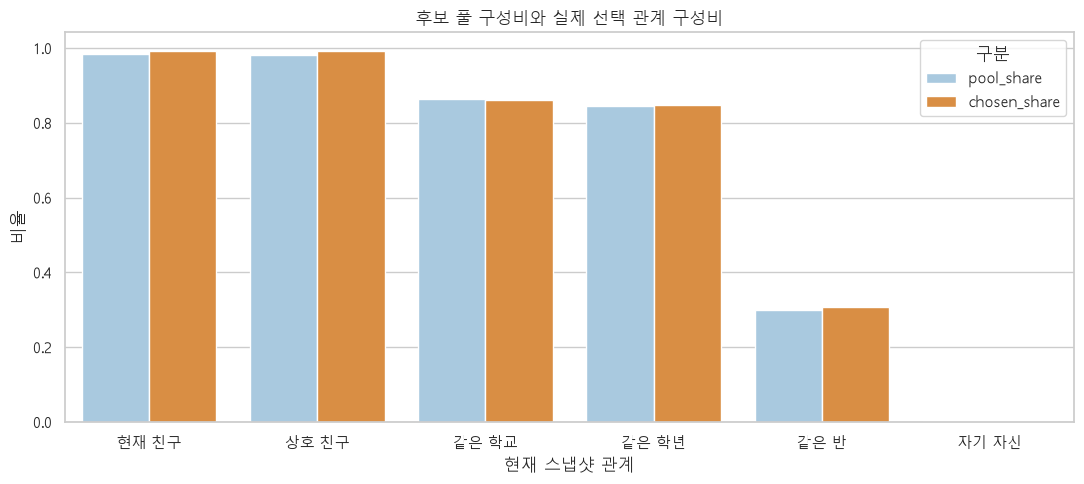

In [19]:
# 후보 풀 구성비와 실제 선택 관계 구성비를 같은 정규 후보행에서 비교한다.
candidate_selection=con.execute("""
SELECT
  '현재 친구' relation,
  AVG(CAST(current_friend_any_direction_flag AS DOUBLE)) pool_share,
  SUM(CASE WHEN selected_candidate_canonical_pair_flag=1 THEN current_friend_any_direction_flag ELSE 0 END)
    / NULLIF(SUM(selected_candidate_canonical_pair_flag),0) chosen_share
FROM candidate WHERE analysis_eligible_candidate_canonical_flag=1
UNION ALL
SELECT '상호 친구', AVG(CAST(current_friend_mutual_flag AS DOUBLE)),
  SUM(CASE WHEN selected_candidate_canonical_pair_flag=1 THEN current_friend_mutual_flag ELSE 0 END)
    / NULLIF(SUM(selected_candidate_canonical_pair_flag),0)
FROM candidate WHERE analysis_eligible_candidate_canonical_flag=1
UNION ALL
SELECT '같은 학교', AVG(CAST(same_school_current_flag AS DOUBLE)),
  SUM(CASE WHEN selected_candidate_canonical_pair_flag=1 THEN same_school_current_flag ELSE 0 END)
    / NULLIF(SUM(selected_candidate_canonical_pair_flag),0)
FROM candidate WHERE analysis_eligible_candidate_canonical_flag=1
UNION ALL
SELECT '같은 학년', AVG(CAST(same_school_grade_current_flag AS DOUBLE)),
  SUM(CASE WHEN selected_candidate_canonical_pair_flag=1 THEN same_school_grade_current_flag ELSE 0 END)
    / NULLIF(SUM(selected_candidate_canonical_pair_flag),0)
FROM candidate WHERE analysis_eligible_candidate_canonical_flag=1
UNION ALL
SELECT '같은 반', AVG(CAST(same_school_grade_class_current_flag AS DOUBLE)),
  SUM(CASE WHEN selected_candidate_canonical_pair_flag=1 THEN same_school_grade_class_current_flag ELSE 0 END)
    / NULLIF(SUM(selected_candidate_canonical_pair_flag),0)
FROM candidate WHERE analysis_eligible_candidate_canonical_flag=1
UNION ALL
SELECT '자기 자신', AVG(CAST(self_candidate_flag AS DOUBLE)),
  SUM(CASE WHEN selected_candidate_canonical_pair_flag=1 THEN self_candidate_flag ELSE 0 END)
    / NULLIF(SUM(selected_candidate_canonical_pair_flag),0)
FROM candidate WHERE analysis_eligible_candidate_canonical_flag=1
""").df()
candidate_selection['selection_enrichment_pp']=(candidate_selection.chosen_share-candidate_selection.pool_share)*100
display(candidate_selection)
candidate_selection.to_csv(OUTPUT_DIR/'candidate_pool_vs_chosen_relation.csv',index=False,encoding='utf-8-sig')

fig,ax=plt.subplots(figsize=(11,5))
plot_sel=candidate_selection.melt(id_vars='relation',value_vars=['pool_share','chosen_share'],var_name='구분',value_name='비율')
sns.barplot(data=plot_sel,x='relation',y='비율',hue='구분',ax=ax,palette=['#A0CBE8','#F28E2B'])
ax.set_title('후보 풀 구성비와 실제 선택 관계 구성비'); ax.set_xlabel('현재 스냅샷 관계')
plt.tight_layout(); plt.savefig(FIG_DIR/'05b_candidate_pool_vs_chosen.png',dpi=160,bbox_inches='tight'); plt.show()

In [20]:
# 소유자-후보 정규쌍의 반복 등장 정도
pair_repetition=con.execute("""
SELECT CAST(resolved_owner_user_id AS VARCHAR) owner_user_id,
       CAST(candidate_user_id AS VARCHAR) candidate_user_id,
       COUNT(DISTINCT CAST(question_piece_id AS VARCHAR)) pieces_together,
       MAX(CAST(current_friend_any_direction_flag AS INTEGER)) current_friend,
       MAX(CAST(same_school_grade_class_current_flag AS INTEGER)) same_class,
       MAX(CAST(self_candidate_flag AS INTEGER)) self_candidate
FROM candidate
WHERE analysis_eligible_candidate_canonical_flag=1
GROUP BY 1,2
""").df()
pair_repetition['repeat_band']=pd.cut(pair_repetition.pieces_together,[0,1,2,5,10,20,50,100,np.inf],labels=['1','2','3-5','6-10','11-20','21-50','51-100','101+'])
pair_rep_summary=(pair_repetition.groupby('repeat_band',observed=True).agg(
    pairs=('candidate_user_id','size'), current_friend_rate=('current_friend','mean'), same_class_rate=('same_class','mean'),
    self_rate=('self_candidate','mean')).reset_index())
display(pair_rep_summary)
pair_rep_summary.to_csv(OUTPUT_DIR/'owner_candidate_pair_repetition.csv',index=False,encoding='utf-8-sig')

,repeat_band,pairs,current_friend_rate,same_class_rate,self_rate
0,1,17521,0.886650,0.162034,0.003424
1,2,15529,0.914225,0.172452,0.003606
2,3-5,39608,0.944102,0.179964,0.002474
3,6-10,53005,0.968946,0.203453,0.001717
4,11-20,68178,0.981270,0.239828,0.001291
5,21-50,63795,0.987899,0.296669,0.000988
6,51-100,13681,0.989986,0.379212,0.000439
7,101+,1765,0.988669,0.463456,0.000000


,relation_group,candidate_rows,row_selection_rate,selected_rows,pool_share,chosen_share,chosen_minus_pool_pp
0,1 자기 자신,4802,0.407955,1959.0,0.001007,0.001609,0.060205
1,2 상호 친구,4678934,0.257839,1206414.0,0.981107,0.990847,0.973997
2,3 단방향 친구,10604,0.164561,1745.0,0.002224,0.001433,-0.079031
3,4 같은 반 비친구,14628,0.110063,1610.0,0.003067,0.001322,-0.174497
4,5 같은 학년 비친구,42245,0.097432,4116.0,0.008858,0.003381,-0.547765
5,6 같은 학교 비친구,3732,0.086817,324.0,0.000783,0.000266,-0.051644
6,7 기타/현재 관계 미확인,14089,0.098659,1390.0,0.002954,0.001142,-0.181264


,occurrence_band,candidate_rows,owners,observed_selection_rate,random_choice_baseline,lift_vs_random
0,1회,273082,4850,0.228254,0.255808,-0.027554
1,2회,255561,4819,0.222694,0.255682,-0.032988
2,3-5회,678740,4790,0.223801,0.255554,-0.031753
3,6-10회,889801,4639,0.234415,0.255414,-0.020999
4,11-20회,1132509,4336,0.250926,0.255227,-0.004301
5,21회+,1539341,3395,0.294705,0.255057,0.039648


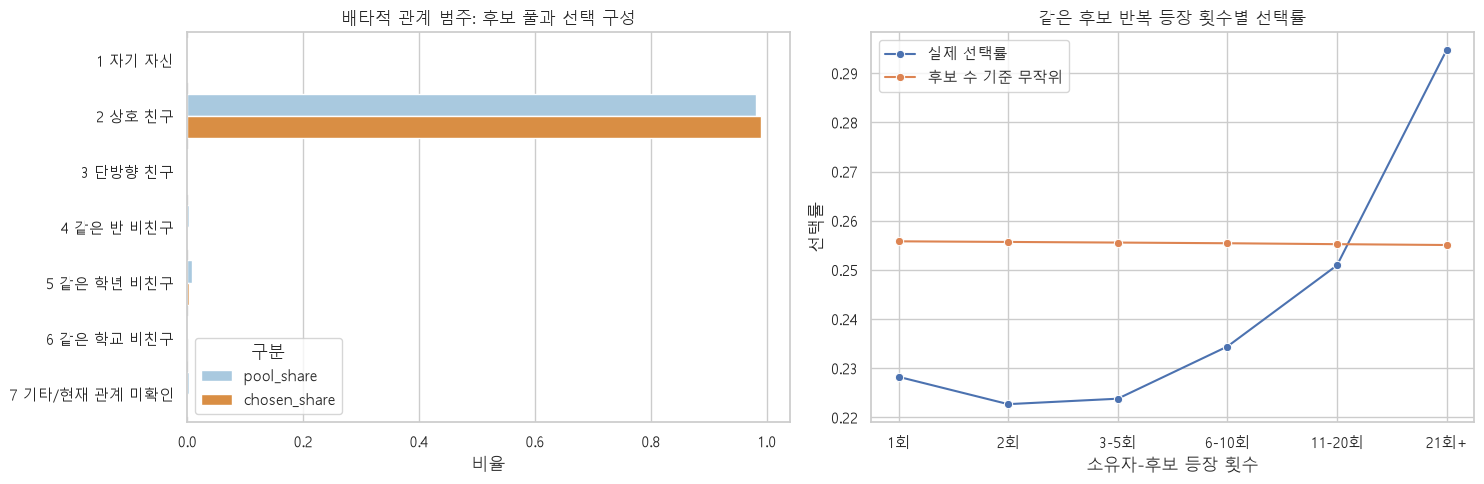

In [21]:
# 관계 범주를 겹치지 않게 만들어 후보 풀과 선택의 구조를 비교한다.
candidate_hierarchy=con.execute("""
WITH x AS (
  SELECT selected_candidate_canonical_pair_flag selected,
         CASE
           WHEN self_candidate_flag=1 THEN '1 자기 자신'
           WHEN current_friend_mutual_flag=1 THEN '2 상호 친구'
           WHEN current_friend_any_direction_flag=1 THEN '3 단방향 친구'
           WHEN same_school_grade_class_current_flag=1 THEN '4 같은 반 비친구'
           WHEN same_school_grade_current_flag=1 THEN '5 같은 학년 비친구'
           WHEN same_school_current_flag=1 THEN '6 같은 학교 비친구'
           ELSE '7 기타/현재 관계 미확인' END relation_group
  FROM candidate WHERE analysis_eligible_candidate_canonical_flag=1
)
SELECT relation_group, COUNT(*) candidate_rows,
       AVG(CAST(selected AS DOUBLE)) row_selection_rate,
       SUM(selected) selected_rows,
       COUNT(*)/SUM(COUNT(*)) OVER() pool_share,
       SUM(selected)/SUM(SUM(selected)) OVER() chosen_share
FROM x GROUP BY 1 ORDER BY 1
""").df()
candidate_hierarchy['chosen_minus_pool_pp']=(candidate_hierarchy.chosen_share-candidate_hierarchy.pool_share)*100
display(candidate_hierarchy)

# 같은 소유자-후보가 반복 등장할수록 무작위 기준(1/후보 수)보다 더/덜 선택되는지 확인한다.
candidate_occurrence=con.execute("""
WITH base AS (
  SELECT CAST(resolved_owner_user_id AS VARCHAR) owner_user_id,
         CAST(candidate_user_id AS VARCHAR) candidate_user_id,
         CAST(question_piece_id AS VARCHAR) question_piece_id,
         TRY_CAST(candidate_source_created_at AS TIMESTAMP) created_at,
         CAST(selected_candidate_canonical_pair_flag AS INTEGER) selected,
         CAST(candidate_count_canonical_per_piece AS DOUBLE) candidate_count,
         ROW_NUMBER() OVER(
           PARTITION BY CAST(resolved_owner_user_id AS VARCHAR),CAST(candidate_user_id AS VARCHAR)
           ORDER BY TRY_CAST(candidate_source_created_at AS TIMESTAMP),CAST(question_piece_id AS VARCHAR)
         ) pair_occurrence
  FROM candidate WHERE analysis_eligible_candidate_canonical_flag=1
), banded AS (
  SELECT *,CASE WHEN pair_occurrence=1 THEN '1회'
                WHEN pair_occurrence=2 THEN '2회'
                WHEN pair_occurrence<=5 THEN '3-5회'
                WHEN pair_occurrence<=10 THEN '6-10회'
                WHEN pair_occurrence<=20 THEN '11-20회'
                ELSE '21회+' END occurrence_band
  FROM base
)
SELECT occurrence_band, COUNT(*) candidate_rows, COUNT(DISTINCT owner_user_id) owners,
       AVG(CAST(selected AS DOUBLE)) observed_selection_rate,
       AVG(1.0/NULLIF(candidate_count,0)) random_choice_baseline,
       AVG(CAST(selected AS DOUBLE)-1.0/NULLIF(candidate_count,0)) lift_vs_random
FROM banded GROUP BY 1
ORDER BY CASE occurrence_band WHEN '1회' THEN 1 WHEN '2회' THEN 2 WHEN '3-5회' THEN 3 WHEN '6-10회' THEN 4 WHEN '11-20회' THEN 5 ELSE 6 END
""").df()
display(candidate_occurrence)
fig,ax=plt.subplots(1,2,figsize=(15,5))
hier_plot=candidate_hierarchy.melt(id_vars='relation_group',value_vars=['pool_share','chosen_share'],var_name='구분',value_name='비율')
sns.barplot(data=hier_plot,y='relation_group',x='비율',hue='구분',ax=ax[0],palette=['#A0CBE8','#F28E2B'])
ax[0].set(title='배타적 관계 범주: 후보 풀과 선택 구성',xlabel='비율',ylabel='')
sns.lineplot(data=candidate_occurrence,x='occurrence_band',y='observed_selection_rate',marker='o',label='실제 선택률',ax=ax[1])
sns.lineplot(data=candidate_occurrence,x='occurrence_band',y='random_choice_baseline',marker='o',label='후보 수 기준 무작위',ax=ax[1])
ax[1].set(title='같은 후보 반복 등장 횟수별 선택률',xlabel='소유자-후보 등장 횟수',ylabel='선택률')
plt.tight_layout(); plt.savefig(FIG_DIR/'05c_candidate_relation_repetition.png',dpi=160,bbox_inches='tight'); plt.show()
candidate_hierarchy.to_csv(OUTPUT_DIR/'candidate_exclusive_relation_hierarchy.csv',index=False,encoding='utf-8-sig')
candidate_occurrence.to_csv(OUTPUT_DIR/'candidate_occurrence_selection.csv',index=False,encoding='utf-8-sig')

## 5. 콘텐츠와 행동의 연결

### 5.1 반복과 투표 기록

비율 차이, 오즈비, Cramér's V로 반복과 현재 투표 기록의 관계를 확인한다.


In [22]:
def wilson_ci(k,n,alpha=.05):
    if n==0: return (np.nan,np.nan)
    z=stats.norm.ppf(1-alpha/2); p=k/n; den=1+z*z/n
    ctr=(p+z*z/(2*n))/den
    half=z*math.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
    return ctr-half,ctr+half

def binary_compare(df, group, outcome):
    tab=pd.crosstab(df[group],df[outcome]).reindex(index=[0,1],columns=[0,1],fill_value=0)
    chi2,p,_,_=stats.chi2_contingency(tab)
    n=tab.values.sum(); v=math.sqrt(chi2/n) if n else np.nan
    a,b=tab.loc[1,1],tab.loc[1,0]; c,d=tab.loc[0,1],tab.loc[0,0]
    odds=((a+.5)*(d+.5))/((b+.5)*(c+.5))
    rates=[]
    for g in [0,1]:
        k=int(tab.loc[g,1]); total=int(tab.loc[g].sum()); lo,hi=wilson_ci(k,total)
        rates.append((g,total,k,k/total if total else np.nan,lo,hi))
    return tab, {'feature':group,'outcome':outcome,'rate_0':rates[0][3],'rate_1':rates[1][3],
                 'absolute_diff':rates[1][3]-rates[0][3],'odds_ratio':odds,'cramers_v':v,'p_value':p}

tests=[]
for feature,outcome in [
    ('repeat_question_id','vote_record_exists'),('repeat_exact_text','vote_record_exists'),
    ('repeat_semantic_090','vote_record_exists')]:
    _, result=binary_compare(piece,feature,outcome); tests.append(result)
tests=pd.DataFrame(tests)
from statsmodels.stats.multitest import multipletests
tests['p_fdr_bh']=multipletests(tests.p_value,method='fdr_bh')[1]
display(tests.sort_values('outcome'))
tests.to_csv(OUTPUT_DIR/'binary_association_tests.csv',index=False,encoding='utf-8-sig')

,feature,outcome,rate_0,rate_1,absolute_diff,odds_ratio,cramers_v,p_value,p_fdr_bh
0,repeat_question_id,vote_record_exists,0.957938,0.980603,0.022665,2.219580,0.046119,0.0,0.0
1,repeat_exact_text,vote_record_exists,0.958059,0.979479,0.021420,2.089307,0.044043,0.0,0.0
2,repeat_semantic_090,vote_record_exists,0.957939,0.978533,0.020594,2.001309,0.043450,0.0,0.0


### 5.2 테마·질문 위치·문구 길이

테마, 질문세트 내 위치, 문구 길이별 투표 기록 차이를 비교한다.


,theme_id,rows,unique_texts,users,vote_rate,skip_history_rate,candidate_source_observed_rate,semantic_repeat_rate,top_terms
2,2,44453,255,4439,0.940791,0.001282,0.940814,0.130295,친구 / 것 / 같 / 하 / 주 / 안 / 있 / 싶 / 나 / 때
8,8,70299,316,4712,0.947325,0.001166,0.947325,0.214825,사람 / 같 / 것 / 잘 / 어울리 / 이 / 가장 / 있 / 나 / 제일
12,12,49544,264,4625,0.949479,0.000928,0.949540,0.158506,것 / 같 / 사람 / 하 / 안 / 못 / 자 / 있 / 시간 / 잠
7,7,69679,248,4738,0.957103,0.001091,0.957161,0.192784,사람 / 것 / 같 / 연애 / 싶 / 하 / 가장 / 결혼 / 애인 / 친구
4,4,131403,485,4870,0.957353,0.001096,0.957368,0.174205,친구 / 가장 / 같 / 것 / 잘 / 하 / 이 / 제일 / 어울리 / 있
3,3,44898,164,4607,0.960110,0.000935,0.960110,0.187959,것 / 같 / 사람 / 노래 / 잘 / 가장 / 부르 / 하 / 노래방 / 듣
9,9,88996,289,4801,0.962178,0.000787,0.962189,0.190458,사람 / 것 / 같 / 잘 / 하 / 가장 / 이 / 제일 / 게임 / 있
5,5,60896,175,4731,0.962395,0.001035,0.962411,0.215022,같이 / 싶 / 가 / 사람 / 보 / 하 / 여행 / 친구 / 놀 / 둘
13,13,42266,132,4591,0.962547,0.001065,0.962570,0.193087,같이 / 싶 / 친구 / 가 / 하 / 사람 / 같 / 것 / 집 / 카페
0,0,57227,183,4710,0.963758,0.000559,0.963776,0.200273,먹 / 것 / 같 / 사람 / 잘 / 밥 / 주 / 좋아하 / 친구 / 싶


,question_position,rows,users,vote_rate,skip_history_rate,semantic_repeat_rate,candidate_source_observed_rate
0,1,129160,4972,0.965678,0.002214,0.202772,0.965732
1,2,128221,4970,0.964163,0.001997,0.202736,0.964202
2,3,127481,4972,0.963336,0.001483,0.204085,0.963430
3,4,127041,4972,0.962658,0.001071,0.201880,0.962681
4,5,126714,4971,0.961962,0.000718,0.204113,0.961977
5,6,126001,4972,0.961302,0.000460,0.204919,0.961310
6,7,125895,4972,0.960975,0.000342,0.201573,0.960983
7,8,125035,4972,0.960507,0.000216,0.203647,0.960507
8,9,124433,4972,0.960163,0.000137,0.206047,0.960163
9,10,125495,4972,0.960413,0.000191,0.205434,0.960413


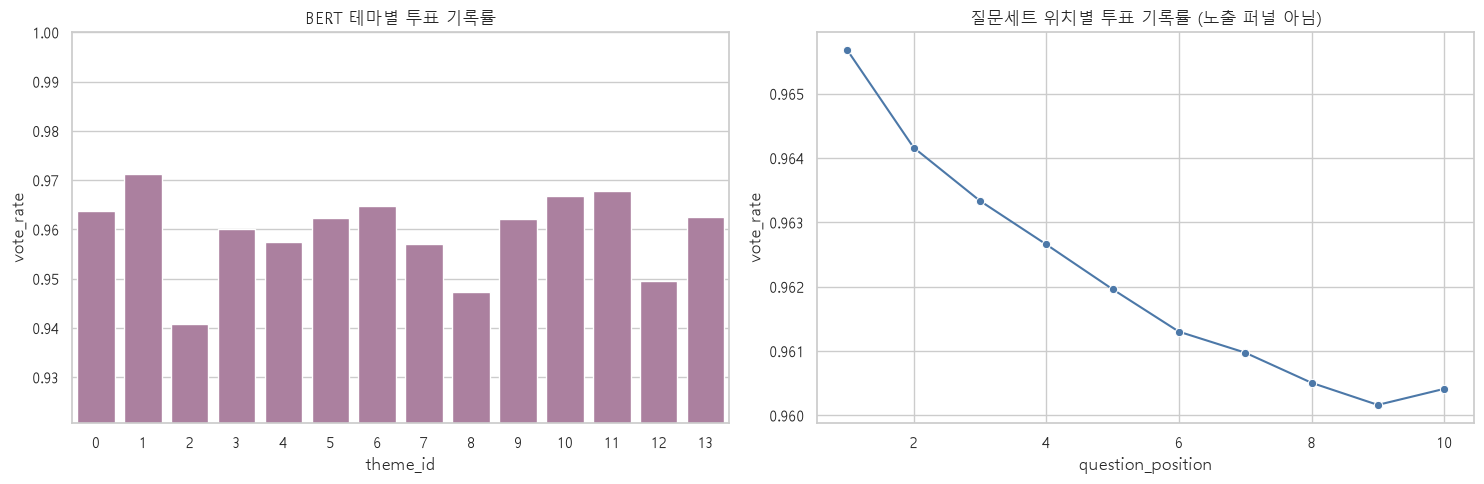

In [23]:
theme_behavior=(piece.groupby('theme_id').agg(
    rows=('question_piece_id','size'), unique_texts=('question_text_normalized','nunique'), users=('owner_user_id','nunique'),
    vote_rate=('vote_record_exists','mean'), skip_history_rate=('raw_is_skipped','mean'),
    candidate_source_observed_rate=('candidate_source_observed','mean'), semantic_repeat_rate=('repeat_semantic_090','mean')
).reset_index().merge(theme_summary[['theme_id','top_terms']],on='theme_id',how='left'))
display(theme_behavior.sort_values('vote_rate'))

position_behavior=(piece.dropna(subset=['question_position']).groupby('question_position').agg(
    rows=('question_piece_id','size'), users=('owner_user_id','nunique'), vote_rate=('vote_record_exists','mean'),
    skip_history_rate=('raw_is_skipped','mean'), semantic_repeat_rate=('repeat_semantic_090','mean'),
    candidate_source_observed_rate=('candidate_source_observed','mean')
).reset_index())
display(position_behavior)

fig,ax=plt.subplots(1,2,figsize=(15,5))
sns.barplot(data=theme_behavior,x='theme_id',y='vote_rate',color='#B279A2',ax=ax[0])
ax[0].set_title('BERT 테마별 투표 기록률'); ax[0].set_ylim(max(0,theme_behavior.vote_rate.min()-.02),1)
sns.lineplot(data=position_behavior,x='question_position',y='vote_rate',marker='o',color='#4C78A8',ax=ax[1])
ax[1].set_title('질문세트 위치별 투표 기록률 (노출 퍼널 아님)')
plt.tight_layout(); plt.savefig(FIG_DIR/'06_theme_position_behavior.png',dpi=160,bbox_inches='tight'); plt.show()
theme_behavior.to_csv(OUTPUT_DIR/'theme_behavior.csv',index=False,encoding='utf-8-sig')
position_behavior.to_csv(OUTPUT_DIR/'position_behavior.csv',index=False,encoding='utf-8-sig')

In [24]:
# 테마 전체 차이와 위치의 선형 추세를 별도로 검정한다.
theme_tab=pd.crosstab(piece.theme_id,piece.vote_record_exists)
theme_chi2,theme_p,_,_=stats.chi2_contingency(theme_tab)
theme_v=np.sqrt(theme_chi2/(theme_tab.values.sum()*min(theme_tab.shape[0]-1,theme_tab.shape[1]-1)))
theme_test=pd.DataFrame([{'chi2':theme_chi2,'df':(theme_tab.shape[0]-1)*(theme_tab.shape[1]-1),
                          'p_value':theme_p,'cramers_v':theme_v,'max_min_rate_diff':theme_behavior.vote_rate.max()-theme_behavior.vote_rate.min()}])

theme_ci=[]
for _,r in theme_behavior.iterrows():
    k=int(round(r.vote_rate*r.rows)); lo,hi=wilson_ci(k,int(r.rows))
    theme_ci.append({'theme_id':int(r.theme_id),'rows':int(r.rows),'vote_rate':r.vote_rate,'ci95_low':lo,'ci95_high':hi,'top_terms':r.top_terms})
theme_ci=pd.DataFrame(theme_ci)
display(theme_test); display(theme_ci.sort_values('vote_rate'))

import statsmodels.api as sm
position_trends=[]
for label,sub in [('전체',piece),('2023-05',piece[piece.is_2023_may.eq(1)]),('기타 기간',piece[piece.is_2023_may.eq(0)])]:
    agg=sub.dropna(subset=['question_position']).groupby('question_position').vote_record_exists.agg(['sum','count']).reset_index()
    endog=np.column_stack([agg['sum'],agg['count']-agg['sum']])
    fit=sm.GLM(endog,sm.add_constant(agg.question_position.astype(float)),family=sm.families.Binomial()).fit()
    beta=float(fit.params.iloc[1]); se=float(fit.bse.iloc[1])
    position_trends.append({'scope':label,'rows':int(agg['count'].sum()),'odds_ratio_per_position':np.exp(beta),
                            'ci95_low':np.exp(beta-1.96*se),'ci95_high':np.exp(beta+1.96*se),'p_value':float(fit.pvalues.iloc[1])})
position_trends=pd.DataFrame(position_trends)

piece['text_length_band']=pd.qcut(piece.text_len,10,duplicates='drop')
length_behavior=(piece.groupby('text_length_band',observed=True).agg(
    rows=('question_piece_id','size'),median_length=('text_len','median'),vote_rate=('vote_record_exists','mean'),
    semantic_repeat_rate=('repeat_semantic_090','mean')).reset_index())
display(position_trends); display(length_behavior)
theme_test.to_csv(OUTPUT_DIR/'theme_vote_chi_square.csv',index=False,encoding='utf-8-sig')
theme_ci.to_csv(OUTPUT_DIR/'theme_vote_wilson_ci.csv',index=False,encoding='utf-8-sig')
position_trends.to_csv(OUTPUT_DIR/'position_vote_trend_tests.csv',index=False,encoding='utf-8-sig')
length_behavior.to_csv(OUTPUT_DIR/'text_length_behavior.csv',index=False,encoding='utf-8-sig')

,chi2,df,p_value,cramers_v,max_min_rate_diff
0,2014.931836,13,0.0,0.039903,0.030495


,theme_id,rows,vote_rate,ci95_low,ci95_high,top_terms
2,2,44453,0.940791,0.938559,0.942948,친구 / 것 / 같 / 하 / 주 / 안 / 있 / 싶 / 나 / 때
8,8,70299,0.947325,0.945649,0.948952,사람 / 같 / 것 / 잘 / 어울리 / 이 / 가장 / 있 / 나 / 제일
12,12,49544,0.949479,0.947516,0.951373,것 / 같 / 사람 / 하 / 안 / 못 / 자 / 있 / 시간 / 잠
7,7,69679,0.957103,0.955573,0.958583,사람 / 것 / 같 / 연애 / 싶 / 하 / 가장 / 결혼 / 애인 / 친구
4,4,131403,0.957353,0.956247,0.958432,친구 / 가장 / 같 / 것 / 잘 / 하 / 이 / 제일 / 어울리 / 있
3,3,44898,0.960110,0.958260,0.961881,것 / 같 / 사람 / 노래 / 잘 / 가장 / 부르 / 하 / 노래방 / 듣
9,9,88996,0.962178,0.960905,0.963412,사람 / 것 / 같 / 잘 / 하 / 가장 / 이 / 제일 / 게임 / 있
5,5,60896,0.962395,0.960855,0.963877,같이 / 싶 / 가 / 사람 / 보 / 하 / 여행 / 친구 / 놀 / 둘
13,13,42266,0.962547,0.960694,0.964315,같이 / 싶 / 친구 / 가 / 하 / 사람 / 같 / 것 / 집 / 카페
0,0,57227,0.963758,0.962196,0.965259,먹 / 것 / 같 / 사람 / 잘 / 밥 / 주 / 좋아하 / 친구 / 싶


,scope,rows,odds_ratio_per_position,ci95_low,ci95_high,p_value
0,전체,1265476,0.984242,0.981121,0.987373,1.100630e-22
1,2023-05,1144964,0.982476,0.978453,0.986515,3.020865e-17
2,기타 기간,120512,0.984912,0.979679,0.990173,2.226410e-08


,text_length_band,rows,median_length,vote_rate,semantic_repeat_rate
0,"(2.999, 12.0]",142036,11.0,0.961827,0.225943
1,"(12.0, 14.0]",148102,14.0,0.963559,0.210267
2,"(14.0, 16.0]",140158,16.0,0.957370,0.183828
3,"(16.0, 17.0]",97742,17.0,0.960478,0.197448
4,"(17.0, 19.0]",183790,19.0,0.960194,0.192845
5,"(19.0, 20.0]",95925,20.0,0.962022,0.198728
6,"(20.0, 21.0]",110608,21.0,0.966196,0.246366
7,"(21.0, 23.0]",141716,23.0,0.964951,0.204726
8,"(23.0, 26.0]",105762,25.0,0.960789,0.182551
9,"(26.0, 45.0]",99637,28.0,0.965384,0.194908


### 5.3 통제모형

학교·월·테마·위치를 함께 통제하고 시간순 검증 구간에서 방향을 확인한다.


,model,train_rows,test_rows,temporal_cutoff,roc_auc,average_precision,log_loss,brier_score,test_positive_rate,roc_auc_delta_vs_baseline,average_precision_delta_vs_baseline,log_loss_delta_vs_baseline,brier_score_delta_vs_baseline
0,1_baseline,1012373,253103,2023-05-24 08:02:38,0.818036,0.970392,0.757058,0.133570,0.886074,0.000000,0.000000,0.000000,0.000000
1,2_plus_text_theme,1012373,253103,2023-05-24 08:02:38,0.817915,0.970334,0.749668,0.132329,0.886074,-0.000121,-0.000057,-0.007390,-0.001241
2,3_plus_repeat,1012373,253103,2023-05-24 08:02:38,0.817568,0.970300,0.750490,0.132989,0.886074,-0.000468,-0.000092,-0.006568,-0.000581


,feature,coef_log_odds,odds_ratio_per_scaled_unit
11,cat__school_id_4426,2.305620,10.030400
16,cat__month_2023-04,2.083184,8.029994
15,cat__school_id_5520,1.307991,3.698735
17,cat__month_2023-05,0.973456,2.647078
0,num__user_piece_sequence,0.893311,2.443205
1,num__signup_elapsed_days,-0.866875,0.420263
6,cat__school_id_1478,0.698495,2.010724
9,cat__school_id_352,-0.565126,0.568289
19,cat__theme_id_1,0.315787,1.371338
10,cat__school_id_369,-0.306953,0.735685


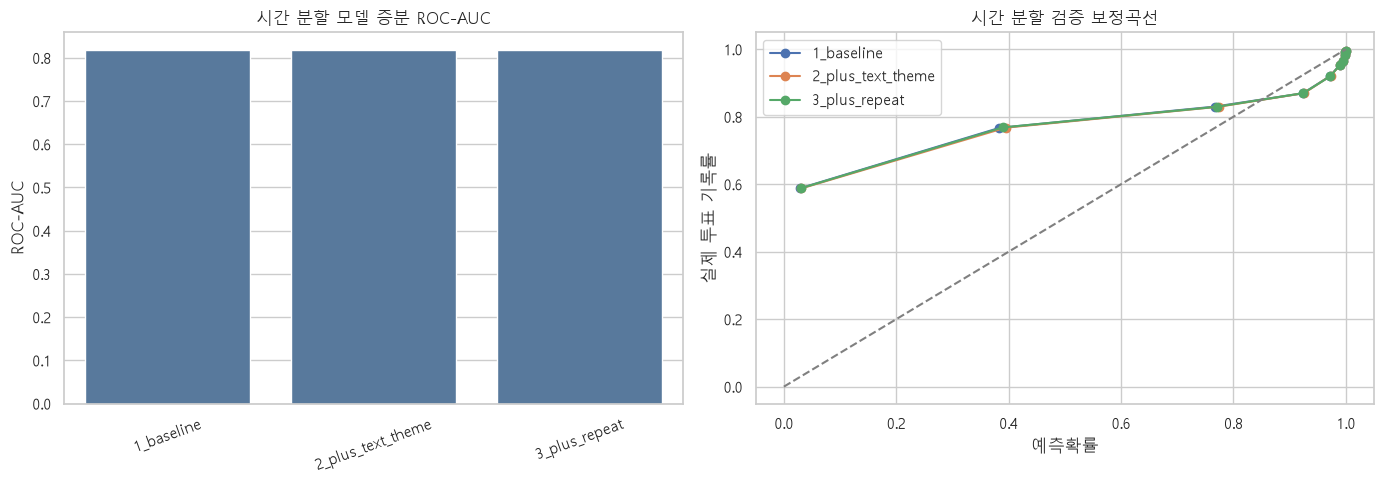

In [25]:
model_cols=['vote_record_exists','piece_created_at','text_len','repeat_exact_text','repeat_semantic_090','user_piece_sequence','signup_elapsed_days',
            'question_position','school_id','month','theme_id']
model_df=piece[model_cols].copy().sort_values('piece_created_at')
temporal_cutoff=model_df.piece_created_at.quantile(.8)
train=model_df[model_df.piece_created_at<temporal_cutoff].copy()
test=model_df[model_df.piece_created_at>=temporal_cutoff].copy()

specs={
    '1_baseline':{
        'num':['user_piece_sequence','signup_elapsed_days','question_position'],
        'cat':['school_id','month']},
    '2_plus_text_theme':{
        'num':['user_piece_sequence','signup_elapsed_days','question_position','text_len'],
        'cat':['school_id','month','theme_id']},
    '3_plus_repeat':{
        'num':['user_piece_sequence','signup_elapsed_days','question_position','text_len','repeat_exact_text','repeat_semantic_090'],
        'cat':['school_id','month','theme_id']},
}

model_rows=[]; fitted={}; predictions={}
for model_name,spec in specs.items():
    pre=ColumnTransformer([
        ('num',Pipeline([('imp',SimpleImputer(strategy='median')),('scale',StandardScaler())]),spec['num']),
        ('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),spec['cat'])
    ])
    clf=Pipeline([('pre',pre),('model',LogisticRegression(max_iter=500,C=0.5,solver='liblinear'))])
    features=spec['num']+spec['cat']
    clf.fit(train[features],train.vote_record_exists)
    pred=clf.predict_proba(test[features])[:,1]
    fitted[model_name]=clf; predictions[model_name]=pred
    model_rows.append({
        'model':model_name,'train_rows':len(train),'test_rows':len(test),'temporal_cutoff':test.piece_created_at.min(),
        'roc_auc':roc_auc_score(test.vote_record_exists,pred),'average_precision':average_precision_score(test.vote_record_exists,pred),
        'log_loss':log_loss(test.vote_record_exists,pred),'brier_score':brier_score_loss(test.vote_record_exists,pred),
        'test_positive_rate':test.vote_record_exists.mean()})
model_perf=pd.DataFrame(model_rows)
for metric in ['roc_auc','average_precision','log_loss','brier_score']:
    model_perf[f'{metric}_delta_vs_baseline']=model_perf[metric]-model_perf.loc[0,metric]
display(model_perf)

best_name='3_plus_repeat'; clf=fitted[best_name]
feature_names=clf.named_steps['pre'].get_feature_names_out(); coef=clf.named_steps['model'].coef_[0]
coef_df=pd.DataFrame({'feature':feature_names,'coef_log_odds':coef,'odds_ratio_per_scaled_unit':np.exp(coef)})
display(coef_df.reindex(coef_df.coef_log_odds.abs().sort_values(ascending=False).index).head(30))

calibration=[]
for name,pred in predictions.items():
    bins=pd.qcut(pred,10,duplicates='drop')
    d=pd.DataFrame({'pred':pred,'actual':test.vote_record_exists.values,'bin':bins})
    c=d.groupby('bin',observed=True).agg(mean_pred=('pred','mean'),observed_rate=('actual','mean'),rows=('actual','size')).reset_index(drop=True)
    c['model']=name; calibration.append(c)
calibration=pd.concat(calibration,ignore_index=True)
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.barplot(data=model_perf,x='model',y='roc_auc',color='#4C78A8',ax=ax[0]); ax[0].set(title='시간 분할 모델 증분 ROC-AUC',xlabel='',ylabel='ROC-AUC'); ax[0].tick_params(axis='x',rotation=20)
for name,g in calibration.groupby('model'):
    ax[1].plot(g.mean_pred,g.observed_rate,marker='o',label=name)
ax[1].plot([0,1],[0,1],'--',color='gray'); ax[1].set(title='시간 분할 검증 보정곡선',xlabel='예측확률',ylabel='실제 투표 기록률'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'07_model_ablation_calibration.png',dpi=160,bbox_inches='tight'); plt.show()
model_perf.to_csv(OUTPUT_DIR/'temporal_model_ablation.csv',index=False,encoding='utf-8-sig')
coef_df.to_csv(OUTPUT_DIR/'temporal_logistic_model_coefficients.csv',index=False,encoding='utf-8-sig')
calibration.to_csv(OUTPUT_DIR/'temporal_model_calibration.csv',index=False,encoding='utf-8-sig')

## 6. 강건성 검증

반복 정의, 후보 단위, 질문세트 완전성, 5월 여부를 바꿔 핵심 결과를 재검증한다.


In [26]:
complete_qsets=set(con.execute("""SELECT CAST(question_set_id AS VARCHAR) FROM qset
WHERE analysis_eligible_question_set_flag=1 AND complete_10_piece_reference_flag=1""").df().iloc[:,0])
piece['complete_10_piece_set']=piece.question_set_id.isin(complete_qsets).astype(int)

robust=[]
for label,sub in [
    ('전체',piece),('2023-05',piece[piece.is_2023_may==1]),('기타 기간',piece[piece.is_2023_may==0]),
    ('10개 참조 완전 세트',piece[piece.complete_10_piece_set==1])]:
    for definition in ['repeat_question_id','repeat_exact_text','repeat_semantic_090']:
        if sub[definition].nunique()<2: continue
        _,r=binary_compare(sub,definition,'vote_record_exists')
        robust.append({'scope':label,'repeat_definition':definition,'rows':len(sub),
                       'rate_nonrepeat':r['rate_0'],'rate_repeat':r['rate_1'],'absolute_diff':r['absolute_diff'],
                       'odds_ratio':r['odds_ratio'],'cramers_v':r['cramers_v'],'p_value':r['p_value']})
robust=pd.DataFrame(robust)
display(robust)
robust.to_csv(OUTPUT_DIR/'repeat_robustness_checks.csv',index=False,encoding='utf-8-sig')

,scope,repeat_definition,rows,rate_nonrepeat,rate_repeat,absolute_diff,odds_ratio,cramers_v,p_value
0,전체,repeat_question_id,1265476,0.957938,0.980603,0.022665,2.219580,0.046119,0.000000e+00
1,전체,repeat_exact_text,1265476,0.958059,0.979479,0.021420,2.089307,0.044043,0.000000e+00
2,전체,repeat_semantic_090,1265476,0.957939,0.978533,0.020594,2.001309,0.043450,0.000000e+00
3,2023-05,repeat_question_id,1144964,0.973489,0.982684,0.009194,1.545261,0.023326,1.694799e-137
4,2023-05,repeat_exact_text,1144964,0.973498,0.982443,0.008946,1.523240,0.022891,1.700293e-132
5,2023-05,repeat_semantic_090,1144964,0.973402,0.982239,0.008837,1.510970,0.023169,1.119139e-135
6,기타 기간,repeat_question_id,120512,0.822931,0.947857,0.124926,3.908913,0.108459,3.094805e-310
7,기타 기간,repeat_exact_text,120512,0.823002,0.936071,0.113068,3.147595,0.102254,5.440480e-276
8,기타 기간,repeat_semantic_090,120512,0.822558,0.926754,0.104196,2.728481,0.098788,9.555446e-258
9,10개 참조 완전 세트,repeat_question_id,571190,0.904958,0.960869,0.055911,2.578638,0.081154,0.000000e+00


## 7. 검증 결과와 해석 범위

현재 데이터로 확인 가능한 결과와 추가 로그가 필요한 항목을 구분한다.


In [27]:
repeat_effect=float(tests.query("feature=='repeat_semantic_090' and outcome=='vote_record_exists'").absolute_diff.iloc[0])
theme_range=float(theme_behavior.vote_rate.max()-theme_behavior.vote_rate.min())
candidate_obs_vote=float(candidate_observed.vote_record_exists.mean())
content_auc_gain=float(model_perf.loc[model_perf.model=='3_plus_repeat','roc_auc'].iloc[0]-model_perf.loc[model_perf.model=='1_baseline','roc_auc'].iloc[0])
content_logloss_gain=float(model_perf.loc[model_perf.model=='3_plus_repeat','log_loss'].iloc[0]-model_perf.loc[model_perf.model=='1_baseline','log_loss'].iloc[0])
position_or=float(position_trends.loc[position_trends.scope=='전체','odds_ratio_per_position'].iloc[0])
within_user_repeat=float(within_user_result.mean_within_user_diff.iloc[0])
stratified_repeat=float(stratified_result.adjusted_rate_diff.iloc[0])
candidate_repeat_lift=float(candidate_occurrence.loc[candidate_occurrence.occurrence_band=='21회+','lift_vs_random'].iloc[0])

evidence_review=pd.DataFrame([
    {'분석질문':'질문 공급이 계속 갱신됐는가','확인된 사실':f"2023-05 신규 문구 비율 {new_monthly.loc[new_monthly.month=='2023-05','new_text_share'].iloc[0]:.1%}, 2023-07 이후 거의 0%",
     '판정':'공급 신규성 약화 관측','말할 수 없는 것':'후기 월 표본이 매우 작으므로 전체 사용자 경험의 감소 원인이라고 단정'},
    {'분석질문':'반복이 참여를 낮췄는가','확인된 사실':f'단순 {repeat_effect:+.2%}p, 사용자 내부 {within_user_repeat:+.2%}p, 층화 통제 {stratified_repeat:+.2%}p',
     '판정':'통제 방식에 따라 방향이 바뀜. 반복에 의한 참여 저하 미확정','말할 수 없는 것':'반복이 이탈을 일으켰다는 인과 주장'},
    {'분석질문':'후보 관계가 투표를 만들었는가','확인된 사실':f'후보 원천 관측 질문의 투표 기록 보유율 {candidate_obs_vote:.3%}',
     '판정':'효과 식별 불가. 후보 풀과 선택 구성만 기술','말할 수 없는 것':'친구 후보 때문에 투표율이 높아졌다는 주장'},
    {'분석질문':'같은 후보가 반복 선택됐는가','확인된 사실':f'동일 소유자-후보 21회 이상 등장 시 무작위 기준 대비 선택률 {candidate_repeat_lift:+.2%}p',
     '판정':'반복 노출과 선택 집중의 연관 관측','말할 수 없는 것':'반복 노출이 선호를 만들었다는 인과 주장'},
    {'분석질문':'질문 테마별 행동이 달랐는가','확인된 사실':f'테마 차이 {theme_range:.2%}p, Cramér V {theme_v:.3f}, 시드 평균 ARI {theme_stability.adjusted_rand_index.mean():.3f}',
     '판정':'행동 차이는 작고 군집 안정성도 낮아 탐색 결과로 사용','말할 수 없는 것':'테마가 고정된 정답 분류이거나 행동 차이의 원인이라는 주장'},
    {'분석질문':'뒤 위치에서 참여가 줄었는가','확인된 사실':f'위치 1 증가당 투표 기록 오즈비 {position_or:.4f}',
     '판정':'생성 위치와 투표 기록의 추세만 확인','말할 수 없는 것':'실제 화면 퍼널의 위치별 이탈'},
    {'분석질문':'콘텐츠 변수가 예측력을 더했는가','확인된 사실':f'ROC-AUC 증분 {content_auc_gain:+.4f}, log loss 변화 {content_logloss_gain:+.4f}',
     '판정':'순위 예측 증분은 거의 없고 확률 오차는 소폭 개선','말할 수 없는 것':'예측변수가 제품 개편의 인과 레버라는 주장'},
])
display(evidence_review)
evidence_review.to_csv(OUTPUT_DIR/'content_claim_boundary_review.csv',index=False,encoding='utf-8-sig')

,분석질문,확인된 사실,판정,말할 수 없는 것
0,질문 공급이 계속 갱신됐는가,"2023-05 신규 문구 비율 85.0%, 2023-07 이후 거의 0%",공급 신규성 약화 관측,후기 월 표본이 매우 작으므로 전체 사용자 경험의 감소 원인이라고 단정
1,반복이 참여를 낮췄는가,"단순 +2.06%p, 사용자 내부 -1.14%p, 층화 통제 +1.07%p",통제 방식에 따라 방향이 바뀜. 반복에 의한 참여 저하 미확정,반복이 이탈을 일으켰다는 인과 주장
2,후보 관계가 투표를 만들었는가,후보 원천 관측 질문의 투표 기록 보유율 99.997%,효과 식별 불가. 후보 풀과 선택 구성만 기술,친구 후보 때문에 투표율이 높아졌다는 주장
3,같은 후보가 반복 선택됐는가,동일 소유자-후보 21회 이상 등장 시 무작위 기준 대비 선택률 +3.96%p,반복 노출과 선택 집중의 연관 관측,반복 노출이 선호를 만들었다는 인과 주장
4,질문 테마별 행동이 달랐는가,"테마 차이 3.05%p, Cramér V 0.040, 시드 평균 ARI 0.317",행동 차이는 작고 군집 안정성도 낮아 탐색 결과로 사용,테마가 고정된 정답 분류이거나 행동 차이의 원인이라는 주장
5,뒤 위치에서 참여가 줄었는가,위치 1 증가당 투표 기록 오즈비 0.9842,생성 위치와 투표 기록의 추세만 확인,실제 화면 퍼널의 위치별 이탈
6,콘텐츠 변수가 예측력을 더했는가,"ROC-AUC 증분 -0.0005, log loss 변화 -0.0066",순위 예측 증분은 거의 없고 확률 오차는 소폭 개선,예측변수가 제품 개편의 인과 레버라는 주장


In [28]:
qa=[]
def qa_add(name, ok, detail): qa.append({'check':name,'status':'PASS' if ok else 'FAIL','detail':detail})
qa_add('정제 질문조각 전행 적재',len(piece)==int(scope.loc[scope.mart=='question_piece','rows_eligible'].iloc[0]),f'{len(piece):,}')
qa_add('질문 문구 100% 연결',piece.question_text.notna().all(),f"missing={piece.question_text.isna().sum():,}")
qa_add('질문조각 ID 유일',piece.question_piece_id.is_unique,f"duplicates={piece.question_piece_id.duplicated().sum():,}")
qa_add('관측 후보 수 비음수',(candidate_observed.candidate_count>=0).all(),f"min={candidate_observed.candidate_count.min()}")
qa_add('후보 미관측을 0명으로 대체하지 않음',piece.loc[piece.candidate_source_observed.eq(0),'candidate_count'].isna().all(),
       f"unobserved={int((piece.candidate_source_observed==0).sum()):,}")
qa_add('투표 플래그 이진',set(piece.vote_record_exists.dropna().unique())<={0,1},str(sorted(piece.vote_record_exists.unique())))
qa_add('테마 전행 할당',piece.theme_id.notna().all(),f"missing={piece.theme_id.isna().sum():,}")
qa_add('의미군 전행 할당',piece.semantic_group_090.notna().all(),f"missing={piece.semantic_group_090.isna().sum():,}")
qa_add('시간순 검증 완전 분리',train.piece_created_at.max()<test.piece_created_at.min(),f"{train.piece_created_at.max()} < {test.piece_created_at.min()}")
qa_add('테마 시드 안정성 계산',theme_stability.adjusted_rand_index.notna().all(),f"mean_ARI={theme_stability.adjusted_rand_index.mean():.3f}")
qa_add('모델 증분 비교 3종',len(model_perf)==3,f"models={len(model_perf)}")
qa_add('주장 경계 7개 기록',len(evidence_review)==7,f"rows={len(evidence_review)}")
qa_df=pd.DataFrame(qa)
display(qa_df)
qa_df.to_csv(OUTPUT_DIR/'content_analysis_qa.csv',index=False,encoding='utf-8-sig')
assert (qa_df.status=='PASS').all(), qa_df

run_manifest={
    'model':MODEL_NAME,'random_state':RANDOM_STATE,'rows':len(piece),'users':int(piece.owner_user_id.nunique()),
    'schools':int(piece.school_id.nunique()),'period':[str(piece.piece_created_at.min()),str(piece.piece_created_at.max())],
    'best_theme_k':best_k,'semantic_thresholds':[0.85,0.90,0.95],
    'important_caveats':['piece_created_at is not confirmed exposure time','F is not interpreted as completion',
                         'friend/school/grade/class are current snapshots','candidate source is almost conditional on vote record',
                         'associations are not causal']
}
(OUTPUT_DIR/'run_manifest.json').write_text(json.dumps(run_manifest,ensure_ascii=False,indent=2),encoding='utf-8')
stale_conclusion=OUTPUT_DIR/'product_reconstruction_evidence_map.csv'
if stale_conclusion.exists():
    stale_conclusion.unlink()
print('FINAL QA: PASS',len(qa_df),'/ FAIL 0')
print('모든 표와 차트 저장 완료:',OUTPUT_DIR)

,check,status,detail
0,정제 질문조각 전행 적재,PASS,"1,265,476"
1,질문 문구 100% 연결,PASS,missing=0
2,질문조각 ID 유일,PASS,duplicates=0
3,관측 후보 수 비음수,PASS,min=1
4,후보 미관측을 0명으로 대체하지 않음,PASS,"unobserved=47,887"
5,투표 플래그 이진,PASS,"[np.int32(0), np.int32(1)]"
6,테마 전행 할당,PASS,missing=0
7,의미군 전행 할당,PASS,missing=0
8,시간순 검증 완전 분리,PASS,2023-05-24 08:02:20 < 2023-05-24 08:02:38
9,테마 시드 안정성 계산,PASS,mean_ARI=0.317


FINAL QA: PASS 12 / FAIL 0
모든 표와 차트 저장 완료: C:\Users\lucy5\Desktop\team7\analysis\content_deep_dive\outputs


### 해석 시 주의사항

- 결과는 질문 데이터가 제공된 10개 학교에 한정한다.
- 질문조각 생성시각을 실제 노출시각으로 해석하지 않는다.
- 후보 관계는 현재 스냅샷이다.
- 과거 스킵 흔적과 현재 투표 기록을 독립 사건률로 합산하지 않는다.
- BERT 테마는 탐색적 의미군이며 정답 라벨이 아니다.


# 추가 분석 1. 콘텐츠 구조

현재 마트에서 식별 가능한 후속 행동과 콘텐츠 구조를 추가로 검증한다. 원천에 없는 노출·스킵 사유·실험 배정 정보는 추정하지 않는다.


In [29]:
from pathlib import Path
import warnings
import re

import networkx as nx
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score, silhouette_score, roc_auc_score, log_loss
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from statsmodels.discrete.conditional_models import ConditionalLogit
from statsmodels.duration.survfunc import survdiff
import statsmodels.formula.api as smf
import statsmodels.api as sm

FOLLOWUP_DIR = OUTPUT_DIR / 'followup'
FOLLOWUP_FIG_DIR = FOLLOWUP_DIR / 'figures'
FOLLOWUP_DIR.mkdir(parents=True, exist_ok=True)
FOLLOWUP_FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_PROCESSED = ROOT / 'data' / 'processed'
FRIEND_PATH = DATA_PROCESSED / 'viral_school' / 'mart_friend_request_event_v2_clean.csv.gz'
SCHOOL_DAILY_PATH = DATA_PROCESSED / 'viral_school' / 'mart_school_viral_daily_v2_clean.csv.gz'
USER_VIRAL_PATH = DATA_PROCESSED / 'viral_school' / 'mart_user_viral_profile_v2_clean.csv.gz'
VOTE_PATH = DATA_PROCESSED / 'question_candidate' / 'mart_vote_record_v2_clean.csv.gz'

def show_save(df, name, head=None):
    df.to_csv(FOLLOWUP_DIR/f'{name}.csv', index=False, encoding='utf-8-sig')
    display(df if head is None else df.head(head))

def zscore(s):
    s = pd.to_numeric(s, errors='coerce')
    sd = s.std(ddof=0)
    return (s-s.mean())/sd if pd.notna(sd) and sd > 0 else s*0

def entropy_from_counts(row):
    x = np.asarray(row, dtype=float)
    x = x[x>0]
    if len(x) <= 1: return 0.0
    p = x/x.sum()
    return float(-(p*np.log(p)).sum()/np.log(len(x)))

print('후속 분석 출력:', FOLLOWUP_DIR)
print('외부 연결 마트:', FRIEND_PATH.name, SCHOOL_DAILY_PATH.name, USER_VIRAL_PATH.name, VOTE_PATH.name)

후속 분석 출력: C:\Users\lucy5\Desktop\team7\analysis\content_deep_dive\outputs\followup
외부 연결 마트: mart_friend_request_event_v2_clean.csv.gz mart_school_viral_daily_v2_clean.csv.gz mart_user_viral_profile_v2_clean.csv.gz mart_vote_record_v2_clean.csv.gz


## 8. 콘텐츠 소진과 다음 행동

질문세트별 소진·다양성 지표와 24시간·72시간·7일 내 다음 질문세트 생성의 관계를 확인한다.


,exhaustion_decile,qsets,users,exhaustion_index,repeat_rate,theme_diversity,semantic_diversity,candidate_unique_ratio,candidate_repeat_share,next_24h,next_72h,next_7d
0,1,15667,3449,0.298849,0.011319,0.933555,1.000000,0.891395,0.0,0.789111,0.874896,0.909677
1,2,15794,3684,0.388220,0.096018,0.851737,1.000000,0.814893,0.0,0.832014,0.916862,0.946559
2,3,15504,4037,0.430220,0.132775,0.807347,0.999985,0.769699,0.0,0.825271,0.902987,0.929175
3,4,15738,3956,0.462939,0.155040,0.777917,0.999932,0.737883,0.0,0.870822,0.943258,0.967340
4,5,15583,4135,0.492042,0.173055,0.743478,0.999954,0.720739,0.0,0.835526,0.906308,0.926843
5,6,15640,3869,0.519062,0.196343,0.720539,0.999841,0.697397,0.0,0.894182,0.958504,0.978197
6,7,15721,3834,0.547022,0.225494,0.689790,0.999748,0.686117,0.0,0.878952,0.942116,0.960435
7,8,15594,3686,0.575954,0.251827,0.660271,0.999595,0.661856,0.0,0.893934,0.953251,0.969668
8,9,15647,3382,0.610980,0.298913,0.625096,0.999048,0.638653,0.0,0.911101,0.963505,0.978844
9,10,15651,2785,0.673998,0.403040,0.583154,0.994945,0.611560,0.0,0.895776,0.942936,0.954949


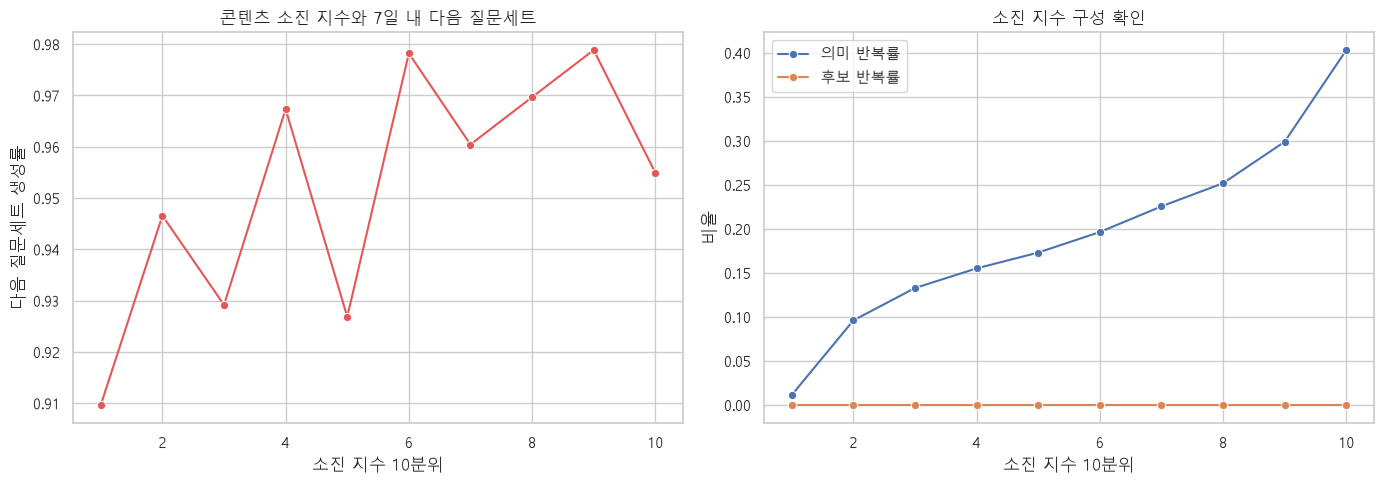

In [30]:
# 질문세트별 콘텐츠 특성
piece_follow = piece.copy()
novelty_map = unique_text.set_index('question_text_normalized')['semantic_novelty_to_prior']
piece_follow['semantic_novelty'] = piece_follow.question_text_normalized.map(novelty_map)

qset_follow = (piece_follow.dropna(subset=['question_set_id'])
    .groupby(['owner_user_id','school_id','question_set_id'], as_index=False)
    .agg(qset_at=('piece_created_at','min'), pieces=('question_piece_id','size'),
         vote_rate=('vote_record_exists','mean'), semantic_repeat_rate=('repeat_semantic_090','mean'),
         exact_repeat_rate=('repeat_exact_text','mean'), unique_themes=('theme_id','nunique'),
         unique_semantic_groups=('semantic_group_090','nunique'),
         mean_semantic_novelty=('semantic_novelty','mean')))
qset_follow['theme_diversity'] = qset_follow.unique_themes/qset_follow.pieces
qset_follow['semantic_diversity'] = qset_follow.unique_semantic_groups/qset_follow.pieces
qset_follow['question_set_id'] = qset_follow.question_set_id.astype(str)

# 질문세트별 후보 수·관계 다양성·동일 후보 반복
candidate_qset_long = con.execute("""
WITH x AS (
  SELECT CAST(question_set_id AS VARCHAR) question_set_id,
         CAST(candidate_user_id AS VARCHAR) candidate_user_id,
         CAST(candidate_pair_occurrence_number AS DOUBLE) pair_occurrence,
         CASE WHEN self_candidate_flag=1 THEN 'self'
              WHEN current_friend_mutual_flag=1 THEN 'mutual_friend'
              WHEN current_friend_any_direction_flag=1 THEN 'oneway_friend'
              WHEN same_school_grade_class_current_flag=1 THEN 'same_class'
              WHEN same_school_grade_current_flag=1 THEN 'same_grade'
              WHEN same_school_current_flag=1 THEN 'same_school'
              ELSE 'unknown' END relation_group
  FROM candidate
  WHERE analysis_eligible_candidate_canonical_flag=1 AND question_set_id IS NOT NULL
)
SELECT question_set_id, relation_group, COUNT(*) candidate_rows,
       COUNT(DISTINCT candidate_user_id) distinct_candidates,
       AVG(CAST(pair_occurrence>1 AS DOUBLE)) repeated_candidate_share
FROM x GROUP BY 1,2
""").df()

rel_counts = candidate_qset_long.pivot(index='question_set_id', columns='relation_group', values='candidate_rows').fillna(0)
candidate_qset = (candidate_qset_long.groupby('question_set_id', as_index=False)
    .agg(candidate_rows=('candidate_rows','sum'), distinct_candidates=('distinct_candidates','sum'),
         repeated_candidate_share=('repeated_candidate_share', lambda s: np.average(s, weights=candidate_qset_long.loc[s.index,'candidate_rows'])),
         relation_types=('relation_group','nunique')))
candidate_qset['candidate_unique_ratio'] = candidate_qset.distinct_candidates/candidate_qset.candidate_rows
candidate_qset['candidate_relation_entropy'] = rel_counts.apply(entropy_from_counts, axis=1).reindex(candidate_qset.question_set_id).values
qset_follow = qset_follow.merge(candidate_qset, on='question_set_id', how='left')

# 사용자별 다음 질문세트와 관측 검열
qset_follow = qset_follow.sort_values(['owner_user_id','qset_at','question_set_id']).reset_index(drop=True)
qset_follow['next_qset_at'] = qset_follow.groupby('owner_user_id').qset_at.shift(-1)
observation_end = qset_follow.qset_at.max()
for hours, label in [(24,'24h'),(72,'72h'),(168,'7d')]:
    eligible = qset_follow.qset_at <= observation_end-pd.Timedelta(hours=hours)
    event = qset_follow.next_qset_at.le(qset_follow.qset_at+pd.Timedelta(hours=hours))
    qset_follow[f'next_qset_{label}'] = np.where(eligible, event.astype(float), np.nan)

# 소진 지수: 높은 반복 + 낮은 의미/테마/후보 다양성
components = pd.DataFrame(index=qset_follow.index)
components['repeat'] = qset_follow.semantic_repeat_rate.rank(pct=True)
components['low_theme_diversity'] = (-qset_follow.theme_diversity).rank(pct=True)
components['low_semantic_diversity'] = (-qset_follow.semantic_diversity).rank(pct=True)
components['candidate_repeat'] = qset_follow.repeated_candidate_share.rank(pct=True)
components['low_candidate_diversity'] = (-qset_follow.candidate_unique_ratio).rank(pct=True)
qset_follow['content_exhaustion_index'] = components.mean(axis=1, skipna=True)
qset_follow['exhaustion_decile'] = pd.qcut(qset_follow.content_exhaustion_index, 10, labels=False, duplicates='drop')+1
qset_follow['month'] = qset_follow.qset_at.dt.to_period('M').astype(str)

exhaustion_summary = (qset_follow.groupby('exhaustion_decile', as_index=False)
    .agg(qsets=('question_set_id','size'), users=('owner_user_id','nunique'),
         exhaustion_index=('content_exhaustion_index','mean'), repeat_rate=('semantic_repeat_rate','mean'),
         theme_diversity=('theme_diversity','mean'), semantic_diversity=('semantic_diversity','mean'),
         candidate_unique_ratio=('candidate_unique_ratio','mean'), candidate_repeat_share=('repeated_candidate_share','mean'),
         next_24h=('next_qset_24h','mean'), next_72h=('next_qset_72h','mean'), next_7d=('next_qset_7d','mean')))
show_save(exhaustion_summary, '01_content_exhaustion_and_next_action')

qset_follow.to_csv(FOLLOWUP_DIR/'qset_followup_features.csv.gz', index=False, encoding='utf-8-sig', compression='gzip')
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.lineplot(data=exhaustion_summary,x='exhaustion_decile',y='next_7d',marker='o',ax=ax[0],color='#E45756')
ax[0].set(title='콘텐츠 소진 지수와 7일 내 다음 질문세트',xlabel='소진 지수 10분위',ylabel='다음 질문세트 생성률')
sns.lineplot(data=exhaustion_summary,x='exhaustion_decile',y='repeat_rate',marker='o',label='의미 반복률',ax=ax[1])
sns.lineplot(data=exhaustion_summary,x='exhaustion_decile',y='candidate_repeat_share',marker='o',label='후보 반복률',ax=ax[1])
ax[1].set(title='소진 지수 구성 확인',xlabel='소진 지수 10분위',ylabel='비율')
plt.tight_layout(); plt.savefig(FOLLOWUP_FIG_DIR/'08_exhaustion_next_action.png',dpi=160,bbox_inches='tight'); plt.show()

## 9. 의미 네트워크 기반 테마 검증

Sentence-BERT 최근접 이웃 네트워크와 Louvain 커뮤니티로 테마 안정성을 재검증한다.


,resolution,themes,silhouette_cosine,modularity,mean_seed_ari
0,0.4,8,0.012701,0.550798,0.562442
1,0.6,13,0.037224,0.603540,0.518176
2,0.8,17,0.040506,0.614043,0.596865
3,1.0,20,0.042204,0.616021,0.572764
4,1.2,25,0.038033,0.614496,0.643572


,method,resolution,themes,new_silhouette_cosine,new_seed_ari,old_kmeans_silhouette_pca,old_kmeans_seed_ari,decision
0,Louvain semantic kNN,1.2,25,0.038033,0.643572,0.050542,0.316991,기존보다 안정적인 탐색용 테마로 채택


,refined_theme_id,unique_texts,piece_count,top_terms,representative_questions,theme_label_ko,label_source
9,9,406,172576,사람 / 가장 / 이 / 같 / 것 / 예쁘 / 매력 / 귀엽 / 있 / 어울리 /...,가장 매력적인 사람은? | 묘하게 끌리는 사람은? | 츤데레 매력이 있는 사람은? ...,매력·외모,대표 형태소·대표 질문의 분석자 검토 라벨
14,14,426,127071,친구 / 가장 / 같 / 것 / 하 / 있 / 이 / 잘 / 나 / 제일 / 많 / 말,가장 쩝쩝박사일 것 같은 친구는? | 사랑스러운 친구는? | 친화력이 제일 좋을 것...,친구 성격·친화력,대표 형태소·대표 질문의 분석자 검토 라벨
6,6,249,103607,사람 / 가장 / 같 / 것 / 이 / 하 / 잘 / 되 / 제일 / 좋 / 크 / 꿈,무엇이든 잘 할 것 같은 사람은? | 제일 듬직한 사람은? | 가장 건치인 사람은?...,능력·성숙·신뢰,대표 형태소·대표 질문의 분석자 검토 라벨
13,13,299,84094,사람 / 같 / 것 / 좋아하 / 가장 / 나 / 연애 / 하 / 싶 / 잘 / 애...,펩시 좋아할 것 같은 사람? | 가장 연애 하고 싶어 보이는 사람은? | 좋아하는 ...,연애·호감,대표 형태소·대표 질문의 분석자 검토 라벨
17,17,205,69308,먹 / 같 / 것 / 사람 / 싶 / 카페 / 가 / 친구 / 잘 / 주 / 같이 / 밥,음식취향이 가장 잘 맞을 것 같은 사람은? | 같이 밥먹고 싶은 사람은? | 같이 ...,음식·식사,대표 형태소·대표 질문의 분석자 검토 라벨
4,4,252,68171,사람 / 같 / 것 / 전화 / 가장 / 먼저 / 주 / 연락 / 친구 / 나 / ...,연락해보고 싶은 사람은? | 뭐만하면 전화 걸 것 같은 친구는? | 전화번호 주고 ...,연락·전화,대표 형태소·대표 질문의 분석자 검토 라벨
10,10,124,64858,사람 / 주 / 싶 / 나 / 웃 / 가장 / 있 / 하 / 것 / 웃음 / 웃기 / 같,제일 유쾌한 사람은? | 기대고 싶은 사람은? | 나를 잘 챙겨주는 사람은? | 챙...,배려·유쾌함,대표 형태소·대표 질문의 분석자 검토 라벨
5,5,197,63447,같이 / 싶 / 가 / 사람 / 친구 / 보 / 놀 / 하 / 같 / 것 / 여행 / 밤,같이 놀아보고 싶은 친구는? | 둘이 같이 놀고 싶은 친구는? | 해외여행을 같이 ...,함께 놀기·여행,대표 형태소·대표 질문의 분석자 검토 라벨
12,12,195,57193,것 / 같 / 사람 / 잘 / 하 / 가장 / 게임 / 제일 / 체육 / 운동 / ...,장난치면 제일 잘받아줄 것 같은 사람은? | 게임을 제일 잘할 것 같은 사람은? |...,게임·운동·장난,대표 형태소·대표 질문의 분석자 검토 라벨
0,0,172,54288,학교 / 같 / 것 / 사람 / 공부 / 하 / 가장 / 친구 / 시험 / 잘 / ...,가장 공부 잘할 것 같은 친구 한명을 고르면? | 학교 대표 얼굴일 것 같은 사람은...,학교·공부,대표 형태소·대표 질문의 분석자 검토 라벨


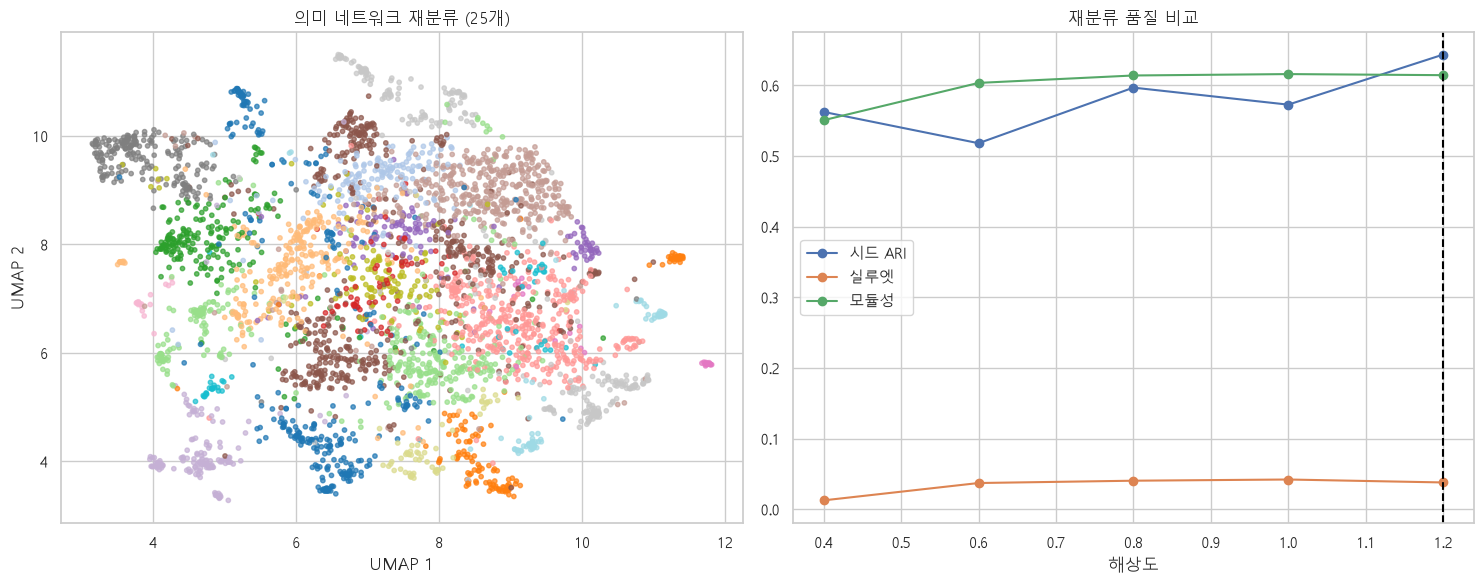

In [31]:
# 의미 k-NN 네트워크 구축
nbr = NearestNeighbors(n_neighbors=13, metric='cosine', n_jobs=-1).fit(embeddings)
knn_dist, knn_idx = nbr.kneighbors(embeddings)
G = nx.Graph(); G.add_nodes_from(range(len(unique_text)))
for i in range(len(unique_text)):
    for d,j in zip(knn_dist[i,1:], knn_idx[i,1:]):
        similarity = 1-float(d)
        if G.has_edge(i,int(j)):
            G[i][int(j)]['weight'] = max(G[i][int(j)]['weight'], similarity)
        else:
            G.add_edge(i,int(j),weight=max(similarity,0.001))

def communities_to_labels(comms, n):
    labels=np.full(n,-1,dtype=int)
    for k,nodes in enumerate(sorted(comms,key=lambda x:min(x))):
        labels[list(nodes)]=k
    return labels

theme_grid=[]; label_store={}
for resolution in [0.4,0.6,0.8,1.0,1.2]:
    seed_runs={}
    for seed in [7,19,42,73]:
        comms=nx.community.louvain_communities(G,weight='weight',resolution=resolution,seed=seed)
        seed_runs[seed]=communities_to_labels(comms,len(unique_text))
    aris=[]
    for a_i,a in enumerate(seed_runs):
        for b in list(seed_runs)[a_i+1:]:
            aris.append(adjusted_rand_score(seed_runs[a],seed_runs[b]))
    labels=seed_runs[42]
    n_themes=len(np.unique(labels))
    sil=silhouette_score(embeddings,labels,metric='cosine',sample_size=min(3000,len(labels)),random_state=42) if 1<n_themes<len(labels) else np.nan
    mod=nx.community.modularity(G,[set(np.where(labels==k)[0]) for k in np.unique(labels)],weight='weight')
    theme_grid.append({'resolution':resolution,'themes':n_themes,'silhouette_cosine':sil,'modularity':mod,'mean_seed_ari':np.mean(aris)})
    label_store[resolution]=labels
theme_grid=pd.DataFrame(theme_grid)
valid=theme_grid.query('themes>=6 and themes<=30').copy()
if valid.empty: valid=theme_grid.copy()
valid['selection_score']=valid.silhouette_cosine+0.10*valid.modularity+0.10*valid.mean_seed_ari
best_resolution=float(valid.loc[valid.selection_score.idxmax(),'resolution'])
refined_labels=label_store[best_resolution]
unique_text['refined_theme_id']=refined_labels

# 테마 설명: 대표 형태소와 중심 질문
refined_rows=[]
for t in sorted(np.unique(refined_labels)):
    idx=np.where(refined_labels==t)[0]
    mean_tfidf=np.asarray(X[idx].mean(axis=0)).ravel()
    top_terms=terms[mean_tfidf.argsort()[-12:][::-1]].tolist()
    sub_degree=np.array([G.degree(int(i),weight='weight') for i in idx])
    reps=unique_text.question_text.iloc[idx[np.argsort(-sub_degree)[:4]]].tolist()
    refined_rows.append({'refined_theme_id':int(t),'unique_texts':len(idx),
                         'piece_count':int(unique_text.piece_count.iloc[idx].sum()),
                         'top_terms':' / '.join(top_terms),'representative_questions':' | '.join(reps)})
refined_theme_summary=pd.DataFrame(refined_rows).sort_values('piece_count',ascending=False)
theme_label_ko={
    0:'학교·공부',1:'생일·선물',2:'친해지고 싶은 관계',3:'SNS·연예인 이미지',4:'연락·전화',
    5:'함께 놀기·여행',6:'능력·성숙·신뢰',7:'집·잠·생활습관',8:'인생·극한상황',9:'매력·외모',
    10:'배려·유쾌함',11:'음악·춤',12:'게임·운동·장난',13:'연애·호감',14:'친구 성격·친화력',
    15:'MBTI·유형',16:'버스·이동 상황',17:'음식·식사',18:'패션·헤어',19:'결혼·가족·미래',
    20:'두려움·부정 성향',21:'글쓰기·목소리·표현',22:'향기·위생',23:'사진·셀카',24:'겨울·눈·온기'}
refined_theme_summary['theme_label_ko']=refined_theme_summary.refined_theme_id.map(theme_label_ko).fillna('검토 필요')
refined_theme_summary['label_source']='대표 형태소·대표 질문의 분석자 검토 라벨'

old_stability=float(theme_stability.adjusted_rand_index.mean())
new_stability=float(theme_grid.loc[theme_grid.resolution.eq(best_resolution),'mean_seed_ari'].iloc[0])
old_silhouette=float(k_scores.loc[k_scores.k.eq(best_k),'silhouette'].iloc[0])
new_silhouette=float(theme_grid.loc[theme_grid.resolution.eq(best_resolution),'silhouette_cosine'].iloc[0])
theme_decision=pd.DataFrame([{
    'method':'Louvain semantic kNN','resolution':best_resolution,'themes':int(len(np.unique(refined_labels))),
    'new_silhouette_cosine':new_silhouette,'new_seed_ari':new_stability,
    'old_kmeans_silhouette_pca':old_silhouette,'old_kmeans_seed_ari':old_stability,
    'decision':'기존보다 안정적인 탐색용 테마로 채택' if (6<=len(np.unique(refined_labels))<=30 and new_stability>=old_stability+0.10 and new_silhouette>=0) else '품질 부족: 기존 탐색 테마 유지'
}])
show_save(theme_grid,'02_refined_theme_model_selection')
show_save(theme_decision,'02b_refined_theme_decision')
show_save(refined_theme_summary,'02c_refined_theme_summary')

fig,ax=plt.subplots(1,2,figsize=(15,6))
sc=ax[0].scatter(unique_text.umap_x,unique_text.umap_y,c=refined_labels,cmap='tab20',s=10,alpha=.7)
ax[0].set(title=f'의미 네트워크 재분류 ({len(np.unique(refined_labels))}개)',xlabel='UMAP 1',ylabel='UMAP 2')
ax[1].plot(theme_grid.resolution,theme_grid.mean_seed_ari,marker='o',label='시드 ARI')
ax[1].plot(theme_grid.resolution,theme_grid.silhouette_cosine,marker='o',label='실루엣')
ax[1].plot(theme_grid.resolution,theme_grid.modularity,marker='o',label='모듈성')
ax[1].axvline(best_resolution,color='black',ls='--'); ax[1].set(title='재분류 품질 비교',xlabel='해상도'); ax[1].legend()
plt.tight_layout(); plt.savefig(FOLLOWUP_FIG_DIR/'09_refined_semantic_themes.png',dpi=160,bbox_inches='tight'); plt.show()

# 안정성 기준을 통과한 경우에만 후속 분석의 주분류로 사용
if 6<=len(np.unique(refined_labels))<=30 and new_stability>=old_stability+0.10 and new_silhouette>=0:
    refined_map=unique_text.set_index('question_text_normalized').refined_theme_id
    piece_follow['analysis_theme_id']=piece_follow.question_text_normalized.map(refined_map)
else:
    piece_follow['analysis_theme_id']=piece_follow.theme_id

## 10. 첫 의미 반복까지의 시간

사용자별 첫 질문부터 첫 의미 반복까지의 시간을 생존분석으로 확인한다.


,users,repeat_event_users,logrank_stat,logrank_p,caution
0,4972,4462,1225.253068,0.0,이용량 사후 구간 비교는 기술 통계


,usage_quartile,day,repeat_free_survival,users
0,Q1 낮음,0,0.995977,1243
1,Q1 낮음,1,0.650928,1243
2,Q1 낮음,3,0.423437,1243
3,Q1 낮음,7,0.276697,1243
4,Q1 낮음,14,0.208618,1243
5,Q1 낮음,30,0.169244,1243
6,Q1 낮음,60,0.149641,1243
7,Q1 낮음,90,0.137171,1243
8,Q2,0,0.997586,1243
9,Q2,1,0.322607,1243


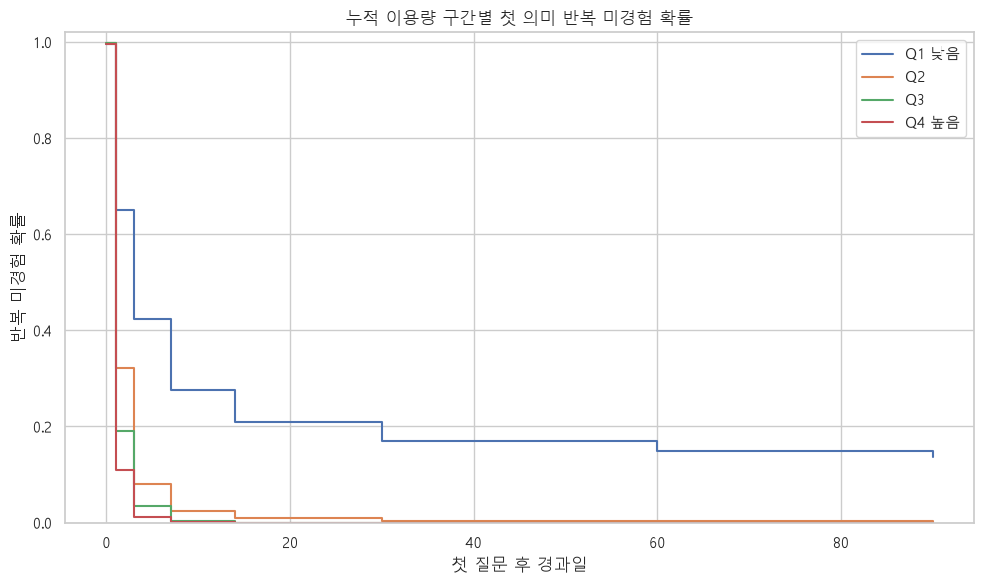

In [32]:
user_survival=[]
for uid,g in piece_follow.sort_values('piece_created_at').groupby('owner_user_id'):
    start=g.piece_created_at.min(); end=g.piece_created_at.max()
    hit=g.loc[g.repeat_semantic_090.eq(1),'piece_created_at']
    event=int(len(hit)>0); stop=hit.min() if event else end
    user_survival.append({'owner_user_id':uid,'school_id':g.school_id.iloc[0],
                          'signup_month':pd.to_datetime(g.signup_at.iloc[0]).to_period('M').strftime('%Y-%m') if pd.notna(g.signup_at.iloc[0]) else 'missing',
                          'lifetime_pieces':len(g),'duration_days':max((stop-start).total_seconds()/86400,0),
                          'repeat_event':event})
user_survival=pd.DataFrame(user_survival)
user_survival['usage_quartile']=pd.qcut(user_survival.lifetime_pieces.rank(method='first'),4,labels=['Q1 낮음','Q2','Q3','Q4 높음'])

def km_points(df, times=(0,1,3,7,14,30,60,90)):
    rows=[]
    for group,g in df.groupby('usage_quartile',observed=True):
        for t in times:
            event_times=np.sort(g.loc[g.repeat_event.eq(1),'duration_days'].unique())
            surv=1.0
            for et in event_times[event_times<=t]:
                risk=(g.duration_days>=et).sum(); d=((g.duration_days.eq(et)) & g.repeat_event.eq(1)).sum()
                if risk>0: surv*=1-d/risk
            rows.append({'usage_quartile':group,'day':t,'repeat_free_survival':surv,'users':len(g)})
    return pd.DataFrame(rows)

km_table=km_points(user_survival)
try:
    lr_stat, lr_p = survdiff(user_survival.duration_days,user_survival.repeat_event,user_survival.usage_quartile.cat.codes)
except Exception:
    lr_stat,lr_p=np.nan,np.nan
survival_test=pd.DataFrame([{'users':len(user_survival),'repeat_event_users':int(user_survival.repeat_event.sum()),
                             'logrank_stat':lr_stat,'logrank_p':lr_p,
                             'caution':'이용량 사후 구간 비교는 기술 통계'}])
show_save(survival_test,'03_first_repeat_survival_test')
show_save(km_table,'03b_first_repeat_km_points')
user_survival.to_csv(FOLLOWUP_DIR/'03c_user_first_repeat_survival.csv',index=False,encoding='utf-8-sig')

fig,ax=plt.subplots(figsize=(10,6))
for name,g in km_table.groupby('usage_quartile',observed=True):
    ax.step(g.day,g.repeat_free_survival,where='post',label=name)
ax.set(title='누적 이용량 구간별 첫 의미 반복 미경험 확률',xlabel='첫 질문 후 경과일',ylabel='반복 미경험 확률',ylim=(0,1.02)); ax.legend()
plt.tight_layout(); plt.savefig(FOLLOWUP_FIG_DIR/'10_first_repeat_survival.png',dpi=160,bbox_inches='tight'); plt.show()

## 11. 사용자 내부 변화와 반복 임계점

사용자 내·사용자 간 효과를 분리하고 학교·월을 통제해 반복 용량과 신규성 임계점을 확인한다.


,feature,effect_level,coef,odds_ratio,ci_low,ci_high,p_value,rows,users
0,within_semantic_repeat_rate,사용자 내부,0.074324,1.077155,1.036744,1.119143,1.392529e-04,156533,4972
1,within_theme_diversity,사용자 내부,0.342316,1.408206,1.369608,1.447891,9.215153e-129,156533,4972
2,within_candidate_relation_entropy,사용자 내부,0.809690,2.247211,2.063065,2.447793,6.567126e-77,156533,4972
3,within_candidate_unique_ratio,사용자 내부,-0.910288,0.402408,0.383968,0.421734,0.000000e+00,156533,4972
4,between_semantic_repeat_rate,사용자 간,1.705245,5.502732,5.028114,6.022150,1.575645e-300,156533,4972
5,between_theme_diversity,사용자 간,0.874944,2.398741,2.187912,2.629886,1.508787e-77,156533,4972
6,between_candidate_relation_entropy,사용자 간,0.468120,1.596989,1.465053,1.740806,1.934251e-26,156533,4972
7,between_candidate_unique_ratio,사용자 간,-0.153290,0.857881,0.809560,0.909087,2.191767e-07,156533,4972


,feature,coef,odds_ratio,ci_low,ci_high,p_value,school_effect,user_se
0,z_semantic_repeat_rate,0.447988,1.565160,1.507826,1.624674,2.116730e-122,fixed (10 schools),cluster robust
1,z_theme_diversity,0.323862,1.382456,1.342064,1.424065,1.180119e-101,fixed (10 schools),cluster robust
2,z_candidate_relation_entropy,0.678270,1.970466,1.818209,2.135473,2.198194e-61,fixed (10 schools),cluster robust
3,z_candidate_unique_ratio,-0.410054,0.663615,0.637673,0.690611,2.425622e-90,fixed (10 schools),cluster robust


,feature,odds_ratio,ci_low,ci_high,p_value,controls,user_se
0,content_exhaustion_index,1.175628,1.135561,1.217108,5.934220e-20,school + month,cluster robust


,dose_decile,repeat_dose,qsets,next_7d,window_qsets
0,1,0.002827,14205,0.962760,10
1,2,0.032058,14204,0.955646,10
2,3,0.060636,14204,0.950014,10
3,4,0.093271,14204,0.942763,10
4,5,0.131317,14204,0.937905,10
5,6,0.174413,14204,0.937764,10
6,7,0.223589,14204,0.944523,10
7,8,0.280483,14204,0.950084,10
8,9,0.358249,14204,0.958181,10
9,10,0.523482,14205,0.964449,10


,cosine_threshold,rows,similar_share,vote_rate_novel,vote_rate_similar,difference
0,0.70,1263678,0.428541,0.968509,0.953564,-0.014945
1,0.75,1263678,0.283442,0.966178,0.951806,-0.014372
2,0.80,1263678,0.169670,0.964418,0.950781,-0.013637
3,0.85,1263678,0.088022,0.963577,0.946849,-0.016727
4,0.90,1263678,0.040398,0.962707,0.947777,-0.014931
5,0.95,1263678,0.011091,0.962306,0.944131,-0.018175


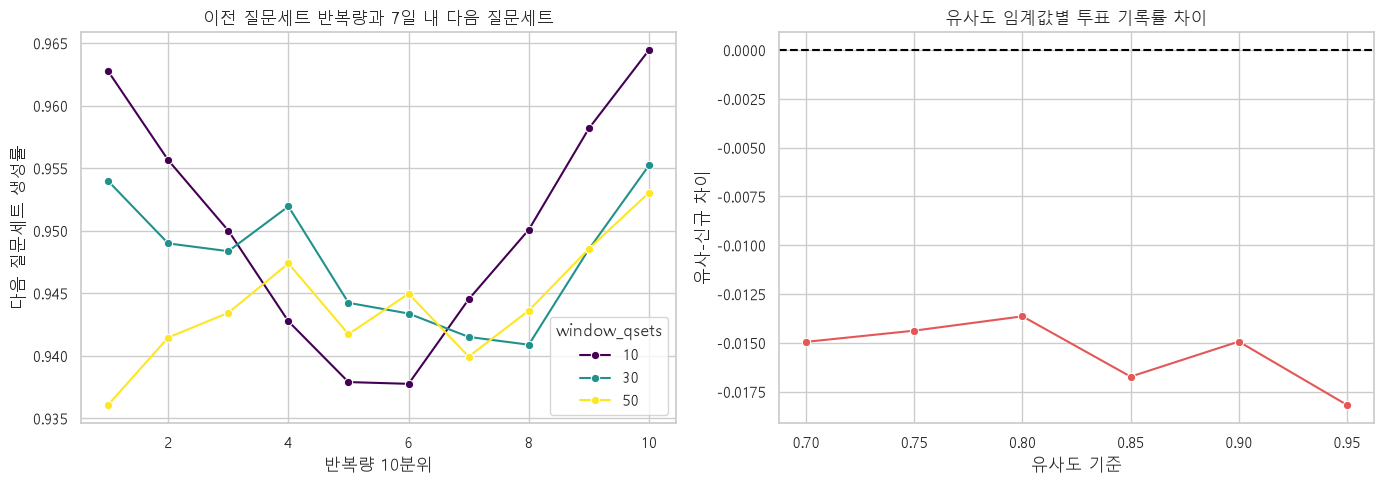

In [33]:
model_q=qset_follow.dropna(subset=['next_qset_7d','content_exhaustion_index']).copy()
fe_features=['semantic_repeat_rate','theme_diversity','candidate_relation_entropy','candidate_unique_ratio']
for c in fe_features: model_q['z_'+c]=zscore(model_q[c].fillna(model_q[c].median()))

# 사용자 내부 중심화(Mundlak within-between decomposition)
within_terms=[]; between_terms=[]
for c in fe_features:
    base='z_'+c
    user_mean=model_q.groupby('owner_user_id')[base].transform('mean')
    model_q['within_'+c]=model_q[base]-user_mean
    model_q['between_'+c]=user_mean
    within_terms.append('within_'+c); between_terms.append('between_'+c)
within_formula='next_qset_7d ~ '+' + '.join(within_terms+between_terms)+' + C(school_id) + C(month)'
within_fit=smf.glm(within_formula,data=model_q,family=sm.families.Binomial()).fit(
    cov_type='cluster',cov_kwds={'groups':model_q.owner_user_id})
wb_terms=within_terms+between_terms
conditional_result=pd.DataFrame({'feature':wb_terms,'effect_level':['사용자 내부']*len(within_terms)+['사용자 간']*len(between_terms),
    'coef':[within_fit.params[x] for x in wb_terms],'odds_ratio':[np.exp(within_fit.params[x]) for x in wb_terms],
    'ci_low':[np.exp(within_fit.conf_int().loc[x,0]) for x in wb_terms],
    'ci_high':[np.exp(within_fit.conf_int().loc[x,1]) for x in wb_terms],
    'p_value':[within_fit.pvalues[x] for x in wb_terms], 'rows':len(model_q),'users':model_q.owner_user_id.nunique()})
show_save(conditional_result,'04_user_within_between_logit')

# 학교·월 통제 + 사용자 cluster-robust SE
formula='next_qset_7d ~ z_semantic_repeat_rate + z_theme_diversity + z_candidate_relation_entropy + z_candidate_unique_ratio + C(school_id) + C(month)'
glm=smf.glm(formula,data=model_q,family=sm.families.Binomial()).fit(cov_type='cluster',cov_kwds={'groups':model_q.owner_user_id})
main_terms=['z_semantic_repeat_rate','z_theme_diversity','z_candidate_relation_entropy','z_candidate_unique_ratio']
cluster_result=pd.DataFrame({'feature':main_terms,'coef':[glm.params[x] for x in main_terms],
                                   'odds_ratio':[np.exp(glm.params[x]) for x in main_terms],
                                   'ci_low':[np.exp(glm.conf_int().loc[x,0]) for x in main_terms],
                                   'ci_high':[np.exp(glm.conf_int().loc[x,1]) for x in main_terms],
                                   'p_value':[glm.pvalues[x] for x in main_terms],
                                   'school_effect':'fixed (10 schools)','user_se':'cluster robust'})
show_save(cluster_result,'05_school_fixed_user_cluster_model')

# 합성 소진 지수는 구성요소와 분리해 단독 모형으로 확인한다.
model_q['z_content_exhaustion_index']=zscore(model_q.content_exhaustion_index)
composite_fit=smf.glm('next_qset_7d ~ z_content_exhaustion_index + C(school_id) + C(month)',data=model_q,
                      family=sm.families.Binomial()).fit(cov_type='cluster',cov_kwds={'groups':model_q.owner_user_id})
composite_result=pd.DataFrame([{'feature':'content_exhaustion_index','odds_ratio':np.exp(composite_fit.params['z_content_exhaustion_index']),
    'ci_low':np.exp(composite_fit.conf_int().loc['z_content_exhaustion_index',0]),
    'ci_high':np.exp(composite_fit.conf_int().loc['z_content_exhaustion_index',1]),
    'p_value':composite_fit.pvalues['z_content_exhaustion_index'],'controls':'school + month','user_se':'cluster robust'}])
show_save(composite_result,'05b_exhaustion_composite_model')

# 이전 10/30/50개 질문세트의 의미 반복률
for window in [10,30,50]:
    qset_follow[f'prior_{window}_qset_repeat_rate']=(qset_follow.groupby('owner_user_id').semantic_repeat_rate
        .transform(lambda s:s.shift().rolling(window,min_periods=max(3,window//5)).mean()))
dose_rows=[]
for window in [10,30,50]:
    col=f'prior_{window}_qset_repeat_rate'
    d=qset_follow.dropna(subset=[col,'next_qset_7d']).copy()
    d['dose_decile']=pd.qcut(d[col].rank(method='first'),10,labels=False)+1
    a=d.groupby('dose_decile',as_index=False).agg(repeat_dose=(col,'mean'),qsets=('question_set_id','size'),next_7d=('next_qset_7d','mean'))
    a['window_qsets']=window; dose_rows.append(a)
dose_response=pd.concat(dose_rows,ignore_index=True)
show_save(dose_response,'07_repeat_dose_response')

# 신규성 임계값 민감도
novelty_threshold=[]
for th in np.arange(.70,.951,.05):
    similar=piece_follow.max_similarity_to_prior_text.ge(th) if 'max_similarity_to_prior_text' in piece_follow else piece_follow.question_text_normalized.map(unique_text.set_index('question_text_normalized').max_similarity_to_prior_text).ge(th)
    valid=piece_follow.question_text_normalized.map(unique_text.set_index('question_text_normalized').max_similarity_to_prior_text).notna()
    sub=piece_follow.loc[valid].copy(); group=similar.loc[valid]
    novelty_threshold.append({'cosine_threshold':round(float(th),2),'rows':len(sub),'similar_share':group.mean(),
                              'vote_rate_novel':sub.loc[~group,'vote_record_exists'].mean(),
                              'vote_rate_similar':sub.loc[group,'vote_record_exists'].mean(),
                              'difference':sub.loc[group,'vote_record_exists'].mean()-sub.loc[~group,'vote_record_exists'].mean()})
novelty_threshold=pd.DataFrame(novelty_threshold)
show_save(novelty_threshold,'08_novelty_threshold_sensitivity')

fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.lineplot(data=dose_response,x='dose_decile',y='next_7d',hue='window_qsets',marker='o',palette='viridis',ax=ax[0])
ax[0].set(title='이전 질문세트 반복량과 7일 내 다음 질문세트',xlabel='반복량 10분위',ylabel='다음 질문세트 생성률')
sns.lineplot(data=novelty_threshold,x='cosine_threshold',y='difference',marker='o',ax=ax[1],color='#E45756')
ax[1].axhline(0,color='black',ls='--'); ax[1].set(title='유사도 임계값별 투표 기록률 차이',xlabel='유사도 기준',ylabel='유사-신규 차이')
plt.tight_layout(); plt.savefig(FOLLOWUP_FIG_DIR/'11_dose_novelty_threshold.png',dpi=160,bbox_inches='tight'); plt.show()

## 12. 콘텐츠 구조 분석

문장 형식, 의미 네트워크, 활성기간, 학교 로컬화, 테마 전이, 문체, 유사 질문쌍과 이상치를 확인한다.


,k,silhouette_cosine,seed_ari,score
0,6,0.040847,0.263335,0.067181
1,8,0.058224,0.616807,0.119905
2,10,0.022101,0.183965,0.040498
3,12,0.052421,0.338112,0.086232
4,14,-0.058403,0.264519,-0.031951
5,16,-0.047358,0.815115,0.034154
6,18,-0.037144,0.445613,0.007417
7,20,-0.081807,0.498033,-0.032004


,template_id,unique_texts,piece_count,top_character_patterns,representative_questions
2,2,1427,608674,은? / 람은? / 사람은? / 람은? / 사람은? / 사람은? / 사람은 ...,스벅 VIP일 것 같은 사람은? | 무대체질일 것 같은 사람은? | 너의 삶에 없어...
3,3,1054,206778,사람 / 사람 / 같은 / 같은 / 같은 / 것 / 사람 / 친구...,외동일 것 같은 사람 | 소식좌일 것 같은 사람 | 똘똘할 것 같은 사람 | 털털할...
0,0,585,134181,친구는? / 구는? / 구는? / 친구는? / 는? / 친구는? / 친구는 ...,예체능인 친구는? | 보부상 재질인 친구는? | 팜므파탈 같은 친구는? | 보디가드...
4,4,352,133691,싶은 / 싶은 / 싶은 / 같이 / 같이 / 같이 / 사람 / 하고...,같이 벛꽃 구경하고 싶은 사람은? | 같이 카공하고 싶은 사람은? | 같이 피시방가...
1,1,269,127003,제일 / 제일 / 제일 / 사람 / 사람은 / 사람은 / 은? / 람은...,제일 파격적일 것 같은 사람은? | 제일 로봇 같은 사람은? | 딱밤 제일 아픈 사...
5,5,114,34840,많이 / 많이 / 많이 / 같은 / 것 / 사람 / 같은 / 같은...,가장 더위를 많이 탈 것 같은 사람은? | 가장 충동구매를 많이 할 것 같은 사람 ...
7,7,76,17365,좋아할 / 좋아할 / 좋아할 / 좋아할 / 아할 / 좋아 / 것 / ...,산리오 좋아할 것 같은 사람은? | 마카롱을 좋아할 것 같은 사람은? | 초밥 좋아...
6,6,21,2944,아이 / 아이돌 / 아이돌 / 아이스크림 / 아이스크 / 스크림 / 이스크림 /...,아이돌로 스카우트 될 것 같은 사람은? | 아이돌 좋아할 것 같은 사람은? | 아이...


,question_text,piece_count,weighted_degree,pagerank,nearest_cosine,refined_theme_id,network_role
311,가장 쩝쩝박사일 것 같은 친구는?,18,113.489636,0.001903,0.903885,14,의미 허브
3401,친해지고 싶은 친구는?,356,96.343138,0.001553,0.962091,2,의미 허브
1860,사랑스러운 친구는?,33,68.531138,0.001130,0.903526,14,의미 허브
2392,어산데 친해지고 싶은 친구는?,279,68.814685,0.001119,0.962091,2,의미 허브
1340,말걸고 싶은 친구는?,22,66.417181,0.001118,0.898348,2,의미 허브
3572,펩시 좋아할 것 같은 사람?,378,62.438286,0.001092,0.912741,13,의미 허브
1518,무엇이든 잘 할 것 같은 사람은?,404,51.323125,0.001028,0.790696,6,의미 허브
2962,장난치면 제일 잘받아줄 것 같은 사람은?,41,53.332317,0.001020,0.765120,12,의미 허브
3407,친화력이 제일 좋을 것 같은 친구는?,35,60.766510,0.001007,0.864028,14,의미 허브
171,가장 매력적인 사람은?,1729,57.258135,0.001003,0.953028,9,의미 허브


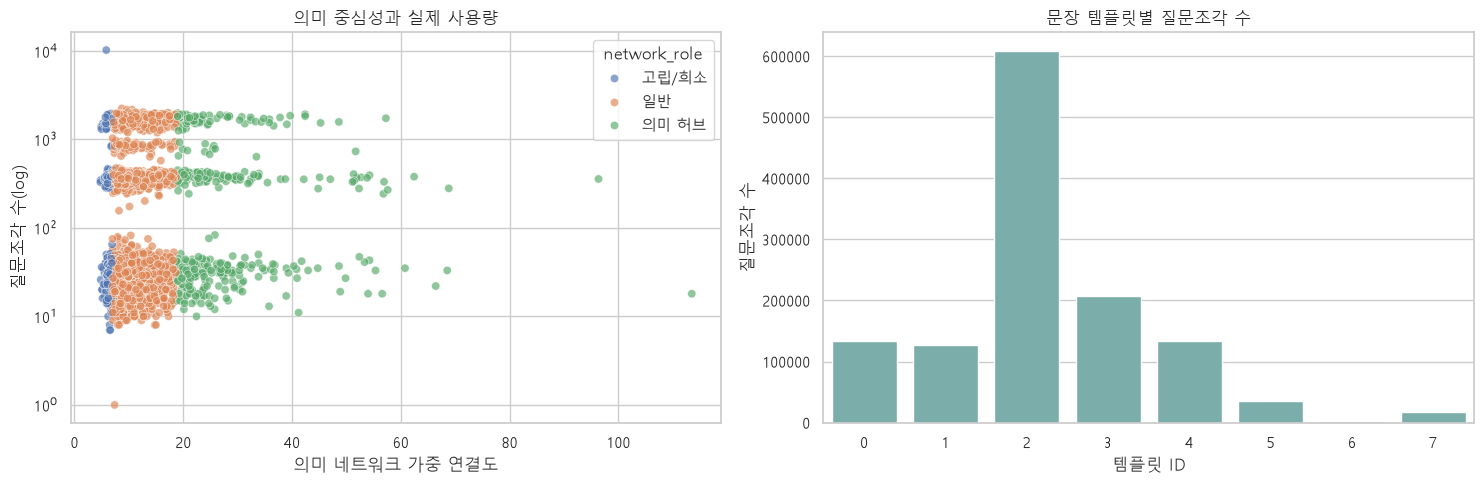

In [34]:
# 11. 의미가 아니라 표현 골격을 보는 문자 n-gram 템플릿 군집
char_vec=TfidfVectorizer(analyzer='char_wb',ngram_range=(3,5),min_df=3,max_features=6000)
Xchar=char_vec.fit_transform(unique_text.question_text.fillna(''))
template_grid=[]; template_models={}
for k in [6,8,10,12,14,16,18,20]:
    km=MiniBatchKMeans(n_clusters=k,random_state=42,batch_size=512,n_init=20)
    lab=km.fit_predict(Xchar)
    sil=silhouette_score(Xchar,lab,metric='cosine',sample_size=min(2500,len(lab)),random_state=42)
    km2=MiniBatchKMeans(n_clusters=k,random_state=73,batch_size=512,n_init=20)
    lab2=km2.fit_predict(Xchar)
    template_grid.append({'k':k,'silhouette_cosine':sil,'seed_ari':adjusted_rand_score(lab,lab2)})
    template_models[k]=(km,lab)
template_grid=pd.DataFrame(template_grid)
template_grid['score']=template_grid.silhouette_cosine+0.1*template_grid.seed_ari
template_k=int(template_grid.loc[template_grid.score.idxmax(),'k'])
template_model,template_labels=template_models[template_k]
char_terms=np.array(char_vec.get_feature_names_out())
template_rows=[]
for t in range(template_k):
    idx=np.where(template_labels==t)[0]
    center=template_model.cluster_centers_[t]
    reps=unique_text.question_text.iloc[idx[np.argsort(-np.asarray(Xchar[idx].dot(center)).ravel())[:4]]].tolist()
    top=char_terms[center.argsort()[-10:][::-1]].tolist()
    template_rows.append({'template_id':t,'unique_texts':len(idx),'piece_count':int(unique_text.piece_count.iloc[idx].sum()),
                          'top_character_patterns':' / '.join(top),'representative_questions':' | '.join(reps)})
template_summary=pd.DataFrame(template_rows).sort_values('piece_count',ascending=False)
show_save(template_grid,'11_template_cluster_selection')
show_save(template_summary,'11b_template_cluster_summary')

# 12. 질문 의미 네트워크 중심성: 상투적 허브와 고립 질문
weighted_degree=dict(G.degree(weight='weight'))
pagerank=nx.pagerank(G,weight='weight')
semantic_network=pd.DataFrame({
    'question_text':unique_text.question_text,
    'piece_count':unique_text.piece_count,
    'weighted_degree':[weighted_degree.get(i,0) for i in range(len(unique_text))],
    'pagerank':[pagerank.get(i,0) for i in range(len(unique_text))],
    'nearest_cosine':unique_text.nearest_cosine,
    'refined_theme_id':refined_labels,
})
semantic_network['network_role']=pd.cut(semantic_network.weighted_degree,
    [-np.inf,semantic_network.weighted_degree.quantile(.1),semantic_network.weighted_degree.quantile(.9),np.inf],
    labels=['고립/희소','일반','의미 허브'],include_lowest=True)
show_save(semantic_network.sort_values('pagerank',ascending=False),'12_semantic_network_centrality',head=30)

fig,ax=plt.subplots(1,2,figsize=(15,5))
sns.scatterplot(data=semantic_network,x='weighted_degree',y='piece_count',hue='network_role',alpha=.65,ax=ax[0])
ax[0].set_yscale('log'); ax[0].set(title='의미 중심성과 실제 사용량',xlabel='의미 네트워크 가중 연결도',ylabel='질문조각 수(log)')
sns.barplot(data=template_summary.head(12),x='template_id',y='piece_count',color='#72B7B2',ax=ax[1])
ax[1].set(title='문장 템플릿별 질문조각 수',xlabel='템플릿 ID',ylabel='질문조각 수')
plt.tight_layout(); plt.savefig(FOLLOWUP_FIG_DIR/'12_template_semantic_network.png',dpi=160,bbox_inches='tight'); plt.show()

In [35]:
# 13. 콘텐츠 활성기간: 후기 도입 문구는 우측 검열되므로 도입 월과 함께 본다.
content_life=unique_text[['question_text','piece_count','first_at','last_at','theme_id']].copy()
content_life['first_at']=pd.to_datetime(content_life.first_at); content_life['last_at']=pd.to_datetime(content_life.last_at)
content_life['active_days']=(content_life.last_at-content_life.first_at).dt.total_seconds()/86400
content_life['first_month']=content_life.first_at.dt.to_period('M').astype(str)
content_life['life_type']=pd.cut(content_life.active_days,[-.001,1,7,30,np.inf],labels=['1일 이내','2-7일','8-30일','31일+'])
life_summary=(content_life.groupby(['first_month','life_type'],observed=True).agg(
    texts=('question_text','size'),pieces=('piece_count','sum'),median_active_days=('active_days','median')).reset_index())
show_save(life_summary,'13_content_lifetime_by_cohort')
content_life.to_csv(FOLLOWUP_DIR/'13b_content_lifetime_detail.csv',index=False,encoding='utf-8-sig')

# 14. 질문 공급자 집중도 식별 가능성
supplier_audit=pd.DataFrame([
    {'analysis':'질문 공급자 집중도','status':'NOT_IDENTIFIABLE','available_key':'질문 ID·질문세트 소유자',
     'missing_key':'질문 마스터 생성자 또는 운영/UGC 구분','reason':'질문세트 소유자는 질문을 푼 사용자이지 질문 문구 생성자가 아님'}
])
show_save(supplier_audit,'14_question_supplier_identifiability')

# 15. 학교별 콘텐츠 로컬화
school_text=(piece_follow.groupby(['question_text_normalized','school_id']).size().rename('pieces').reset_index())
text_school=(school_text.groupby('question_text_normalized').agg(schools_used=('school_id','nunique'),pieces=('pieces','sum')).reset_index())
text_school['scope_type']=np.select([text_school.schools_used.eq(1),text_school.schools_used.le(3),text_school.schools_used.eq(10)],
                                    ['학교 고유','2-3개 학교','10개 학교 공통'],default='4-9개 학교')
local_summary=(text_school.groupby('scope_type',as_index=False).agg(texts=('question_text_normalized','size'),pieces=('pieces','sum')))
local_summary['text_share']=local_summary.texts/local_summary.texts.sum(); local_summary['piece_share']=local_summary.pieces/local_summary.pieces.sum()
show_save(local_summary,'15_school_content_localization')

# 16. 질문세트 내 테마 전이
transition_base=piece_follow.dropna(subset=['question_set_id','question_position']).sort_values(['question_set_id','question_position']).copy()
transition_base['next_theme']=transition_base.groupby('question_set_id').analysis_theme_id.shift(-1)
trans=transition_base.dropna(subset=['next_theme']).copy(); trans['next_theme']=trans.next_theme.astype(int)
transition=(trans.groupby(['analysis_theme_id','next_theme']).size().rename('transitions').reset_index())
transition['from_total']=transition.groupby('analysis_theme_id').transitions.transform('sum')
transition['transition_rate']=transition.transitions/transition.from_total
same_theme_rate=(trans.analysis_theme_id.eq(trans.next_theme)).mean()
theme_probs=transition_base.analysis_theme_id.value_counts(normalize=True)
random_same_rate=float((theme_probs**2).sum())
transition_test=pd.DataFrame([{'transitions':len(trans),'observed_same_theme_rate':same_theme_rate,
                               'independent_expected_rate':random_same_rate,'difference':same_theme_rate-random_same_rate}])
show_save(transition.sort_values(['analysis_theme_id','transition_rate'],ascending=[True,False]),'16_theme_transition_matrix',head=40)
show_save(transition_test,'16b_theme_transition_same_theme_test')

,first_month,life_type,texts,pieces,median_active_days
0,2023-04,31일+,227,411392,143.086910
1,2023-05,8-30일,51,20341,17.685266
2,2023-05,31일+,1235,765145,129.696447
3,2023-06,8-30일,146,4396,22.080162
4,2023-06,31일+,2238,64201,109.183218
5,2023-07,1일 이내,1,1,0.000000


,analysis,status,available_key,missing_key,reason
0,질문 공급자 집중도,NOT_IDENTIFIABLE,질문 ID·질문세트 소유자,질문 마스터 생성자 또는 운영/UGC 구분,질문세트 소유자는 질문을 푼 사용자이지 질문 문구 생성자가 아님


,scope_type,texts,pieces,text_share,piece_share
0,10개 학교 공통,2029,1215868,0.520523,9.607989e-01
1,4-9개 학교,1868,49607,0.479220,3.920027e-02
2,학교 고유,1,1,0.000257,7.902165e-07


,analysis_theme_id,next_theme,transitions,from_total,transition_rate
9,0,9,6407,47442,0.135049
14,0,14,4865,47442,0.102546
6,0,6,3908,47442,0.082374
13,0,13,3183,47442,0.067092
17,0,17,2630,47442,0.055436
4,0,4,2546,47442,0.053666
10,0,10,2393,47442,0.050441
5,0,5,2329,47442,0.049092
12,0,12,2170,47442,0.045740
0,0,0,1945,47442,0.040997


,transitions,observed_same_theme_rate,independent_expected_rate,difference
0,1108937,0.063283,0.063147,0.000136


,style,rows_with_style,share,vote_rate_without,vote_rate_with,difference
0,style_superlative,499114,0.394408,0.959287,0.966507,0.007220
1,style_together,84009,0.066385,0.962155,0.961849,-0.000305
2,style_hypothetical,532025,0.420415,0.964933,0.958276,-0.006657
3,style_negative,20852,0.016478,0.962337,0.950029,-0.012308
4,style_appearance,14867,0.011748,0.962206,0.956077,-0.006129
5,style_relationship,247015,0.195195,0.964154,0.953808,-0.010345
6,style_emoji_or_symbol,31218,0.024669,0.962186,0.960087,-0.002099


,pairs_similarity_090,pairs_length_gap_5plus,mean_longer_minus_shorter,median_longer_minus_shorter,ttest_p
0,315,57,-0.015894,-0.014718,0.444338


,repeat_structure,rows,users,vote_rate,median_sequence
0,기존 테마·새 의미,899151,4966,0.956935,159.0
1,동일 의미 반복,257791,4462,0.978533,261.0
2,새 테마,108534,4972,0.966259,18.0


,question_id,question_text,rows,actual_vote_rate,adjusted_residual,schools
4577,624,같이 야구장 가보고싶은 친구,806,0.959057,-0.016853,10
4592,639,vote,580,0.956897,-0.016667,10
4551,598,가장 잘보이고 싶은 사람이 누구야?,635,0.957480,-0.016349,10
4572,619,일어나자마자 보고싶은 사람은?,634,0.960568,-0.015017,10
4569,616,전생에 나와 부부였을 것 같은 사람은?,646,0.959752,-0.013879,10
...,...,...,...,...,...,...
2420,320,함께한 추억이 가장 많은 사람은?,1614,0.988228,0.015985,10
1430,230,같이 스몰토크 하다가 밤을 샐 것 같은 사람은?,1752,0.989726,0.016054,10
2497,327,누가 잡아가도 다 헤쳐나올 수 있을 것 같은 사람은?,1663,0.987974,0.017204,10
4204,488,솔직한 모습이 멋진 사람은?,1511,0.988087,0.017571,10


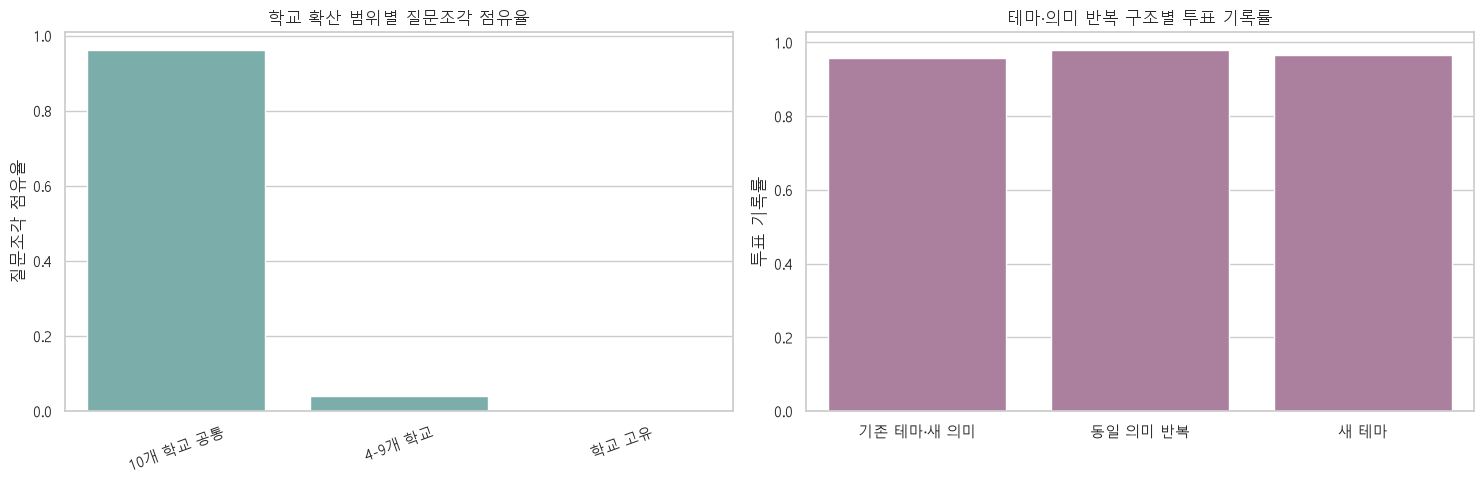

In [36]:
# 17. 문체 특징
text_style=unique_text[['question_text_normalized','question_text','piece_count']].copy()
raw=text_style.question_text.fillna('').astype(str)
norm=text_style.question_text_normalized.fillna('').astype(str)
text_style['style_superlative']=norm.str.contains(r'가장|제일|최고').astype(int)
text_style['style_together']=norm.str.contains(r'같이|함께').astype(int)
text_style['style_hypothetical']=norm.str.contains(r'것 같|할 것|한다면|라면').astype(int)
text_style['style_negative']=norm.str.contains(r'안 |못 |싫|최악|나쁘').astype(int)
text_style['style_appearance']=norm.str.contains(r'외모|예쁘|잘생|얼굴|키 |몸매|귀엽').astype(int)
text_style['style_relationship']=norm.str.contains(r'친구|연애|사귀|결혼|짝사랑').astype(int)
text_style['style_emoji_or_symbol']=raw.str.contains(r'[^0-9A-Za-z가-힣\s?]').astype(int)
style_map=text_style.set_index('question_text_normalized')
style_cols=[c for c in text_style if c.startswith('style_')]
for c in style_cols: piece_follow[c]=piece_follow.question_text_normalized.map(style_map[c]).fillna(0).astype(int)
style_rows=[]
for c in style_cols:
    a=piece_follow.groupby(c).vote_record_exists.agg(['size','mean']).reset_index()
    style_rows.append({'style':c,'rows_with_style':int((piece_follow[c]==1).sum()),'share':piece_follow[c].mean(),
                       'vote_rate_without':a.loc[a[c].eq(0),'mean'].iloc[0] if (a[c]==0).any() else np.nan,
                       'vote_rate_with':a.loc[a[c].eq(1),'mean'].iloc[0] if (a[c]==1).any() else np.nan})
style_summary=pd.DataFrame(style_rows); style_summary['difference']=style_summary.vote_rate_with-style_summary.vote_rate_without
show_save(style_summary,'17_question_style_behavior')

# 18. 의미가 비슷한 질문쌍 중 긴 문구와 짧은 문구 비교
text_perf=(piece_follow.groupby('question_text_normalized').agg(vote_rate=('vote_record_exists','mean'),rows=('question_piece_id','size')).reset_index())
text_perf_map=text_perf.set_index('question_text_normalized')
pair_compare=pair_df.copy()
pair_compare['a_norm']=pair_compare.question_a.map(normalize_text); pair_compare['b_norm']=pair_compare.question_b.map(normalize_text)
pair_compare['a_vote_rate']=pair_compare.a_norm.map(text_perf_map.vote_rate); pair_compare['b_vote_rate']=pair_compare.b_norm.map(text_perf_map.vote_rate)
pair_compare['a_len']=pair_compare.a_norm.str.len(); pair_compare['b_len']=pair_compare.b_norm.str.len()
pair_compare=pair_compare.dropna(subset=['a_vote_rate','b_vote_rate'])
pair_compare['length_gap']=(pair_compare.a_len-pair_compare.b_len).abs()
pair_compare['longer_minus_shorter_vote_rate']=np.where(pair_compare.a_len>=pair_compare.b_len,
    pair_compare.a_vote_rate-pair_compare.b_vote_rate,pair_compare.b_vote_rate-pair_compare.a_vote_rate)
pair_test=pair_compare.loc[pair_compare.length_gap.ge(5),'longer_minus_shorter_vote_rate']
similar_pair_test=pd.DataFrame([{'pairs_similarity_090':len(pair_compare),'pairs_length_gap_5plus':len(pair_test),
                                'mean_longer_minus_shorter':pair_test.mean(),'median_longer_minus_shorter':pair_test.median(),
                                'ttest_p':stats.ttest_1samp(pair_test,0,nan_policy='omit').pvalue if len(pair_test)>1 else np.nan}])
show_save(similar_pair_test,'18_similar_pair_expression_test')
pair_compare.to_csv(FOLLOWUP_DIR/'18b_similar_pair_behavior_detail.csv',index=False,encoding='utf-8-sig')

# 19. 새 테마 / 같은 테마의 새 의미 / 같은 의미 반복 분리
piece_follow=piece_follow.sort_values(['owner_user_id','piece_created_at','question_piece_id']).copy()
piece_follow['theme_occurrence']=piece_follow.groupby(['owner_user_id','analysis_theme_id']).cumcount()+1
piece_follow['repeat_structure']=np.select([
    piece_follow.theme_occurrence.eq(1),
    piece_follow.theme_occurrence.gt(1)&piece_follow.repeat_semantic_090.eq(0),
    piece_follow.repeat_semantic_090.eq(1)],
    ['새 테마','기존 테마·새 의미','동일 의미 반복'],default='기타')
repeat_structure=(piece_follow.groupby('repeat_structure',as_index=False).agg(
    rows=('question_piece_id','size'),users=('owner_user_id','nunique'),vote_rate=('vote_record_exists','mean'),
    median_sequence=('user_piece_sequence','median')))
show_save(repeat_structure,'19_within_between_theme_repeat')

# 20. 학교·월·위치·누적 이용구간 기준 기대값 대비 질문별 잔차
piece_follow['sequence_band_outlier']=pd.cut(piece_follow.user_piece_sequence,[0,10,50,100,200,500,np.inf],labels=False)
baseline_cols=['school_id','month','question_position','sequence_band_outlier']
cell_rate=piece_follow.groupby(baseline_cols,dropna=False).vote_record_exists.transform('mean')
piece_follow['vote_residual']=piece_follow.vote_record_exists-cell_rate
question_outlier=(piece_follow.groupby(['question_id','question_text'],as_index=False).agg(
    rows=('question_piece_id','size'),actual_vote_rate=('vote_record_exists','mean'),
    adjusted_residual=('vote_residual','mean'),schools=('school_id','nunique')))
question_outlier=question_outlier[question_outlier.rows>=500].sort_values('adjusted_residual')
show_save(question_outlier,'20_question_adjusted_outliers')

fig,ax=plt.subplots(1,2,figsize=(15,5))
sns.barplot(data=local_summary,x='scope_type',y='piece_share',color='#72B7B2',ax=ax[0])
ax[0].set(title='학교 확산 범위별 질문조각 점유율',xlabel='',ylabel='질문조각 점유율'); ax[0].tick_params(axis='x',rotation=20)
sns.barplot(data=repeat_structure,x='repeat_structure',y='vote_rate',color='#B279A2',ax=ax[1])
ax[1].set(title='테마·의미 반복 구조별 투표 기록률',xlabel='',ylabel='투표 기록률')
plt.tight_layout(); plt.savefig(FOLLOWUP_FIG_DIR/'13_localization_repeat_structure.png',dpi=160,bbox_inches='tight'); plt.show()

## 13. 다른 분석 파트와 연결

10개 학교 사용자를 기준으로 친구요청, 투표 수신, 학교 40명 도달, 현재 네트워크 규모를 연결한다.


,event,metric,paired_users,before_mean,after_mean,after_minus_before,paired_t_p
0,first_friend_accept_at,qsets,3305,1.521936,22.592738,21.070802,0.000000e+00
1,first_friend_accept_at,repeat_rate,3305,0.003823,0.135519,0.131696,0.000000e+00
2,first_friend_accept_at,candidate_diversity,3241,0.546694,0.695181,0.148487,8.903926e-309


,event,metric,paired_users,before_mean,after_mean,after_minus_before,paired_t_p
0,first_received_vote_at,qsets,3787,1.762345,23.214154,21.451809,0.0
1,first_received_vote_at,repeat_rate,3787,0.005941,0.142004,0.136062,0.0
2,first_received_vote_at,candidate_diversity,3739,0.564835,0.703878,0.139043,0.0


,friend_count_band,users,qsets,candidate_unique_ratio,candidate_relation_entropy,repeat_rate,next_7d
0,1-5,15,278,0.165899,0.133329,0.147145,0.928058
1,6-10,41,271,0.292225,0.180208,0.055081,0.797048
2,11-20,226,3571,0.528443,0.190891,0.133944,0.911789
3,21-50,1955,52425,0.652762,0.090997,0.169024,0.944891
4,51+,2735,99994,0.768186,0.068527,0.210230,0.957956


,phase_40,schools,qsets,users,repeat_rate,theme_diversity,candidate_diversity,next_7d
0,40명 이전 14일,1,33,22,0.000000,0.785798,0.487938,1.000000
1,40명 이후 14일,10,126732,4687,0.200291,0.734384,0.717068,0.979595


,analysis,status,assignment_files,required_columns
0,사용자 클러스터별 소진 경로,WAITING_FOR_ASSIGNMENT,,user_id + cluster_label


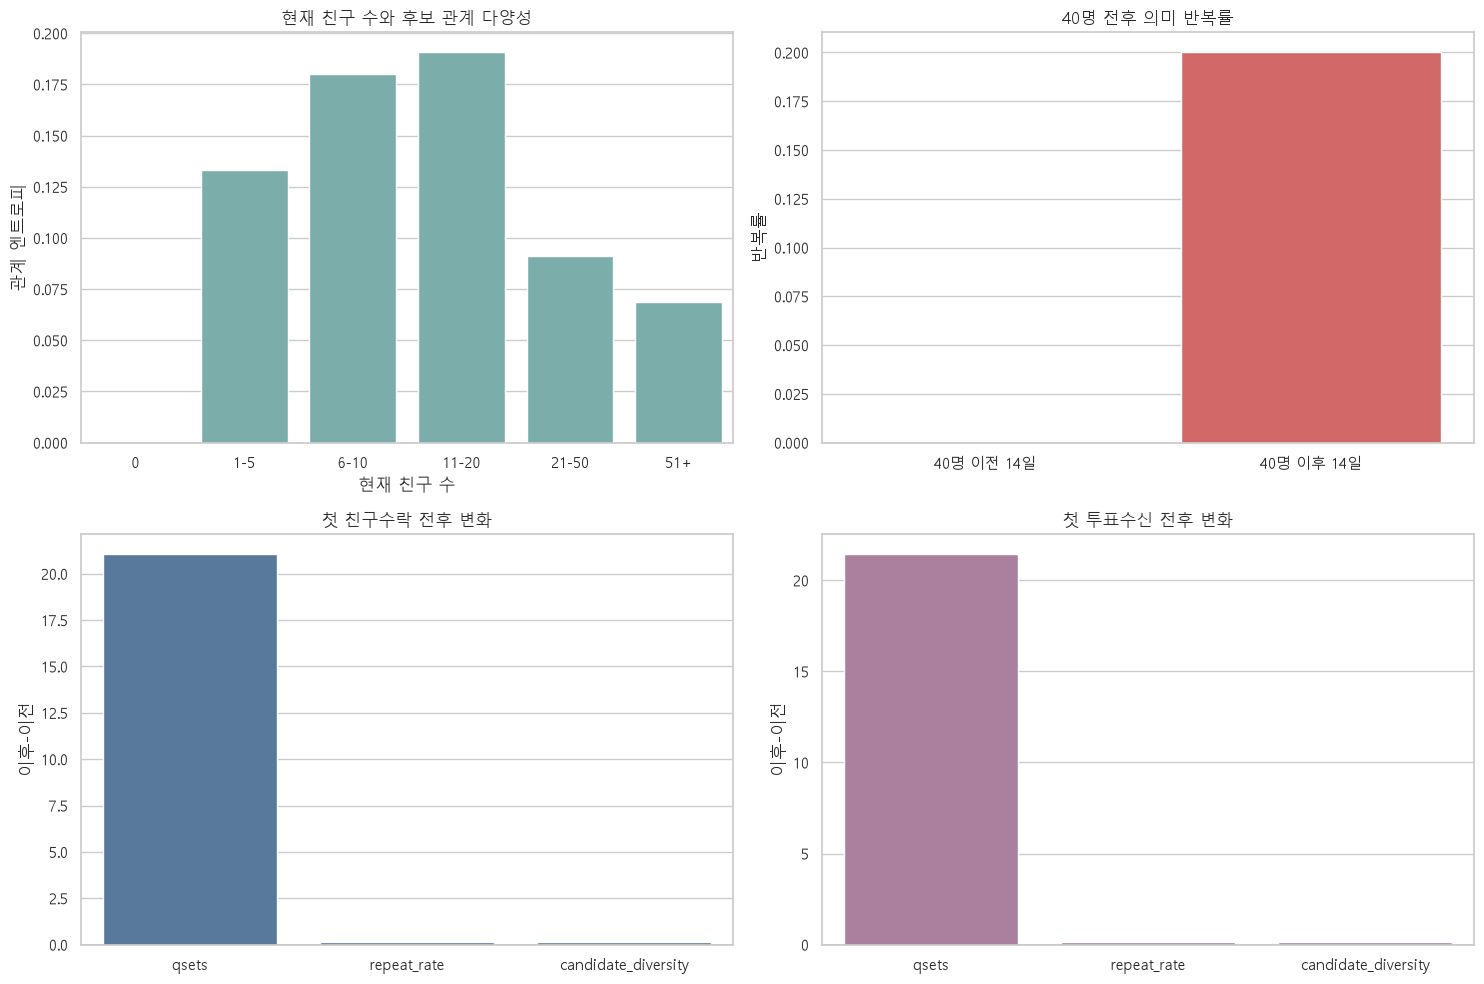

In [37]:
# 질문 사용자 범위부터 고정한다.
qset_event=qset_follow[['owner_user_id','school_id','question_set_id','qset_at','semantic_repeat_rate',
                         'theme_diversity','candidate_unique_ratio','candidate_relation_entropy','next_qset_7d','content_exhaustion_index']].copy()
qset_event['owner_user_id']=qset_event.owner_user_id.astype(str)
qset_event['school_id']=qset_event.school_id.astype(str)
content_users=pd.DataFrame({'user_id':qset_event.owner_user_id.drop_duplicates().astype(object)})
con.register('content_users_followup',content_users)

# 5억 바이트가 넘는 압축 CSV를 pandas로 펼치지 않고, 필요한 사용자·일 단위로 먼저 집계한다.
friend_file=str(FRIEND_PATH).replace('\\','/').replace("'","''")
friend_daily_with_first=con.execute(f"""
WITH endpoints AS (
  SELECT CAST(send_user_id AS VARCHAR) user_id,
         TRY_CAST(request_created_at_raw AS TIMESTAMP) created_at,
         CASE WHEN UPPER(CAST(final_status_label AS VARCHAR)) LIKE '%ACCEPT%'
              THEN TRY_CAST(request_updated_at_raw AS TIMESTAMP) END accepted_at
  FROM read_csv_auto('{friend_file}',header=true)
  WHERE analysis_eligible_request_flag=1 AND CAST(send_user_id AS VARCHAR) IN (SELECT user_id FROM content_users_followup)
  UNION ALL
  SELECT CAST(receive_user_id AS VARCHAR), TRY_CAST(request_created_at_raw AS TIMESTAMP),
         CASE WHEN UPPER(CAST(final_status_label AS VARCHAR)) LIKE '%ACCEPT%'
              THEN TRY_CAST(request_updated_at_raw AS TIMESTAMP) END
  FROM read_csv_auto('{friend_file}',header=true)
  WHERE analysis_eligible_request_flag=1 AND CAST(receive_user_id AS VARCHAR) IN (SELECT user_id FROM content_users_followup)
), daily AS (
  SELECT user_id, CAST(created_at AS DATE) event_date, COUNT(*) day_events
  FROM endpoints WHERE created_at IS NOT NULL GROUP BY 1,2
), firsts AS (
  SELECT user_id, MIN(accepted_at) first_friend_accept_at FROM endpoints GROUP BY 1
)
SELECT d.*, f.first_friend_accept_at FROM daily d LEFT JOIN firsts f USING(user_id)
""").df()
friend_daily=friend_daily_with_first[['user_id','event_date','day_events']]
first_accept=(friend_daily_with_first.dropna(subset=['first_friend_accept_at'])
              .drop_duplicates('user_id').set_index('user_id').first_friend_accept_at)

# 투표 수신은 이미 등록된 정제 vote 마트에서 질문 사용자만 집계한다.
vote_received_daily=con.execute("""
SELECT CAST(chosen_user_id AS VARCHAR) user_id, CAST(TRY_CAST(vote_record_created_at AS TIMESTAMP) AS DATE) event_date,
       COUNT(*) day_events
FROM vote
WHERE analysis_eligible_vote_record_flag=1 AND CAST(chosen_user_id AS VARCHAR) IN (SELECT user_id FROM content_users_followup)
GROUP BY 1,2
""").df()
first_received_vote_df=con.execute("""
SELECT CAST(chosen_user_id AS VARCHAR) user_id, MIN(TRY_CAST(vote_record_created_at AS TIMESTAMP)) first_received_vote_at
FROM vote
WHERE analysis_eligible_vote_record_flag=1 AND CAST(chosen_user_id AS VARCHAR) IN (SELECT user_id FROM content_users_followup)
GROUP BY 1
""").df()
first_received_vote=first_received_vote_df.set_index('user_id').first_received_vote_at

user_viral=pd.read_csv(USER_VIRAL_PATH,compression='gzip',usecols=[
    'user_id','current_friend_list_length','sent_request_count','received_request_count','analysis_eligible_nonstaff_flag'])
user_viral=user_viral[user_viral.analysis_eligible_nonstaff_flag.eq(1)].copy()
user_viral['user_id']=user_viral.user_id.astype(str)

def before_after_qsets(first_event, label):
    d=qset_event.merge(first_event.rename(label),left_on='owner_user_id',right_index=True,how='inner')
    d['relative_days']=(d.qset_at-d[label]).dt.total_seconds()/86400
    d=d[d.relative_days.between(-7,7,inclusive='both')]
    d['period']=np.where(d.relative_days<0,'이전 7일','이후 7일')
    agg=(d.groupby(['owner_user_id','period']).agg(qsets=('question_set_id','nunique'),
          repeat_rate=('semantic_repeat_rate','mean'),candidate_diversity=('candidate_unique_ratio','mean')).reset_index())
    wide=agg.pivot(index='owner_user_id',columns='period')
    rows=[]
    for metric in ['qsets','repeat_rate','candidate_diversity']:
        if (metric,'이전 7일') in wide and (metric,'이후 7일') in wide:
            x=wide[(metric,'이후 7일')]-wide[(metric,'이전 7일')]
            x=x.dropna()
            rows.append({'event':label,'metric':metric,'paired_users':len(x),'before_mean':wide.loc[x.index,(metric,'이전 7일')].mean(),
                         'after_mean':wide.loc[x.index,(metric,'이후 7일')].mean(),'after_minus_before':x.mean(),
                         'paired_t_p':stats.ttest_1samp(x,0,nan_policy='omit').pvalue if len(x)>1 else np.nan})
    return pd.DataFrame(rows)

# 21. 첫 친구요청 수락 업데이트 전후
network_before_after=before_after_qsets(first_accept,'first_friend_accept_at')
show_save(network_before_after,'21_friend_accept_before_after_content')

# 23. 첫 투표 수신 전후
value_before_after=before_after_qsets(first_received_vote,'first_received_vote_at')
show_save(value_before_after,'23_received_vote_before_after_content')

# 22. 현재 친구 수와 후보 다양성: 현재 스냅샷 기술 분석
network_content=qset_event.merge(user_viral[['user_id','current_friend_list_length']],left_on='owner_user_id',right_on='user_id',how='left')
network_content['friend_count_band']=pd.cut(network_content.current_friend_list_length,[-1,0,5,10,20,50,np.inf],
                                            labels=['0','1-5','6-10','11-20','21-50','51+'])
network_density_summary=(network_content.groupby('friend_count_band',observed=True).agg(
    users=('owner_user_id','nunique'),qsets=('question_set_id','size'),candidate_unique_ratio=('candidate_unique_ratio','mean'),
    candidate_relation_entropy=('candidate_relation_entropy','mean'),repeat_rate=('semantic_repeat_rate','mean'),next_7d=('next_qset_7d','mean')).reset_index())
show_save(network_density_summary,'22_current_network_density_candidate_diversity')

# 24. 학교별 관측 40번째 가입 시각 전후 콘텐츠
school_daily=pd.read_csv(SCHOOL_DAILY_PATH,compression='gzip',usecols=['school_id','current_roster_40th_signup_at','analysis_eligible_school_day_flag'])
school_daily['school_id']=school_daily.school_id.astype(str)
school_40=(school_daily[school_daily.analysis_eligible_school_day_flag.eq(1)].dropna(subset=['current_roster_40th_signup_at'])
           .assign(current_roster_40th_signup_at=lambda d:pd.to_datetime(d.current_roster_40th_signup_at,errors='coerce'))
           .groupby('school_id').current_roster_40th_signup_at.min())
growth_content=qset_event.merge(school_40.rename('school_40_at'),left_on='school_id',right_index=True,how='inner')
growth_content['days_from_40']=(growth_content.qset_at-growth_content.school_40_at).dt.total_seconds()/86400
growth_content=growth_content[growth_content.days_from_40.between(-14,14)]
growth_content['phase_40']=np.where(growth_content.days_from_40<0,'40명 이전 14일','40명 이후 14일')
growth_summary=(growth_content.groupby('phase_40',as_index=False).agg(schools=('school_id','nunique'),qsets=('question_set_id','size'),
    users=('owner_user_id','nunique'),repeat_rate=('semantic_repeat_rate','mean'),theme_diversity=('theme_diversity','mean'),
    candidate_diversity=('candidate_unique_ratio','mean'),next_7d=('next_qset_7d','mean')))
show_save(growth_summary,'24_school_40_before_after_content')

# 25. 팀원 사용자 클러스터 배정표 감사
cluster_assignment_candidates=list((ROOT/'analysis').rglob('*cluster*.csv'))+list((ROOT/'analysis').rglob('*segment*.csv'))
assignment_found=[]
for p in cluster_assignment_candidates:
    try:
        cols=pd.read_csv(p,nrows=2).columns.str.lower().tolist()
        if any(c in cols for c in ['user_id','userid','member_id']) and any('cluster' in c or 'segment' in c for c in cols):
            assignment_found.append(str(p))
    except Exception: pass
cluster_audit=pd.DataFrame([{'analysis':'사용자 클러스터별 소진 경로','status':'READY' if assignment_found else 'WAITING_FOR_ASSIGNMENT',
                             'assignment_files':' | '.join(assignment_found),'required_columns':'user_id + cluster_label'}])
show_save(cluster_audit,'25_user_cluster_assignment_audit')

fig,ax=plt.subplots(2,2,figsize=(15,10))
sns.barplot(data=network_density_summary,x='friend_count_band',y='candidate_relation_entropy',color='#72B7B2',ax=ax[0,0])
ax[0,0].set(title='현재 친구 수와 후보 관계 다양성',xlabel='현재 친구 수',ylabel='관계 엔트로피')
if not growth_summary.empty:
    sns.barplot(data=growth_summary,x='phase_40',y='repeat_rate',color='#E45756',ax=ax[0,1]); ax[0,1].set(title='40명 전후 의미 반복률',xlabel='',ylabel='반복률')
if not network_before_after.empty:
    sns.barplot(data=network_before_after,x='metric',y='after_minus_before',color='#4C78A8',ax=ax[1,0]); ax[1,0].axhline(0,color='black',lw=1); ax[1,0].set(title='첫 친구수락 전후 변화',xlabel='',ylabel='이후-이전')
if not value_before_after.empty:
    sns.barplot(data=value_before_after,x='metric',y='after_minus_before',color='#B279A2',ax=ax[1,1]); ax[1,1].axhline(0,color='black',lw=1); ax[1,1].set(title='첫 투표수신 전후 변화',xlabel='',ylabel='이후-이전')
plt.tight_layout(); plt.savefig(FOLLOWUP_FIG_DIR/'14_cross_axis_before_after.png',dpi=160,bbox_inches='tight'); plt.show()

,model,train_rows,test_rows,cutoff,roc_auc,log_loss,auc_gain_vs_content,logloss_change_vs_content
0,content,125226,31307,2023-05-24 08:25:35,0.776706,0.487070,0.000000,0.000000
1,content_network,125226,31307,2023-05-24 08:25:35,0.782262,0.473546,0.005556,-0.013524
2,content_value,125226,31307,2023-05-24 08:25:35,0.775576,0.436052,-0.001130,-0.051019
3,content_network_value,125226,31307,2023-05-24 08:25:35,0.771779,0.437955,-0.004927,-0.049116


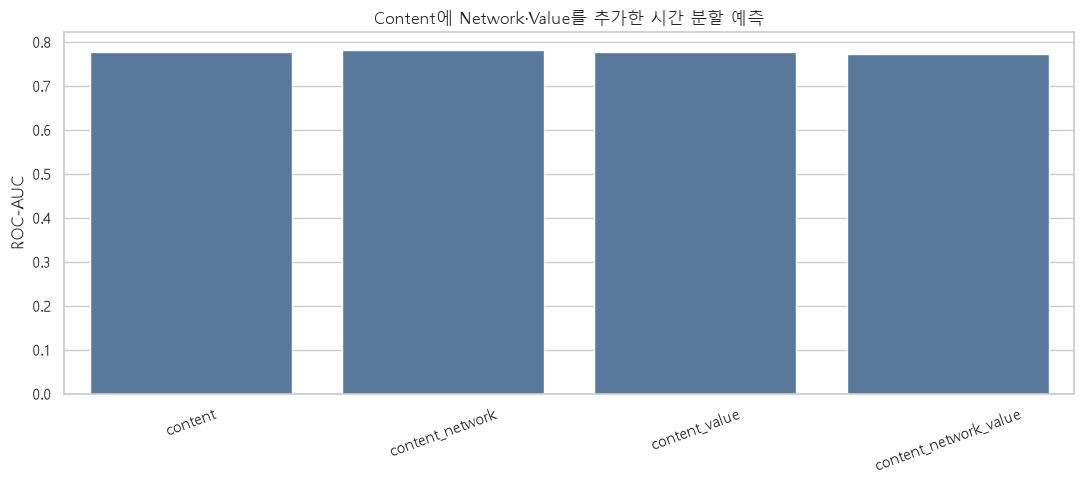

In [38]:
# 26. 누적값 누출을 피하고, 질문세트 시점 이전까지 발생한 이벤트만 결합한 통합 예측
import gc
for _name in ['sim','Xchar','knn_dist','knn_idx','transition_base','trans','school_text']:
    if _name in globals():
        del globals()[_name]
gc.collect()

def prior_event_count(base, daily_input, out_col):
    daily=daily_input[['user_id','event_date','day_events']].dropna().copy()
    daily['user_id']=daily.user_id.astype('string'); daily['event_date']=pd.to_datetime(daily.event_date)
    daily=daily.sort_values(['user_id','event_date']); daily[out_col]=daily.groupby('user_id',observed=True,sort=False).day_events.cumsum()
    left=base[['owner_user_id','qset_at']].copy(); left['row_id']=left.index; left['event_date']=left.qset_at.dt.floor('D')
    left['owner_user_id']=left.owner_user_id.astype('string')
    left=left.sort_values(['event_date','owner_user_id']); right=daily.rename(columns={'user_id':'owner_user_id'}).sort_values(['event_date','owner_user_id'])
    merged=pd.merge_asof(left,right[['owner_user_id','event_date',out_col]],by='owner_user_id',on='event_date',direction='backward',allow_exact_matches=False)
    return merged.set_index('row_id')[out_col].reindex(base.index).fillna(0)

qset_follow['prior_network_events']=prior_event_count(qset_follow,friend_daily,'prior_network_events')
qset_follow['prior_received_votes']=prior_event_count(qset_follow,vote_received_daily,'prior_received_votes')

integrated=qset_follow.dropna(subset=['next_qset_7d']).sort_values('qset_at').copy()
cut=integrated.qset_at.quantile(.8); train_i=integrated[integrated.qset_at<cut]; test_i=integrated[integrated.qset_at>=cut]
specs_integrated={
    'content':['semantic_repeat_rate','theme_diversity','candidate_relation_entropy','candidate_unique_ratio'],
    'content_network':['semantic_repeat_rate','theme_diversity','candidate_relation_entropy','candidate_unique_ratio','prior_network_events'],
    'content_value':['semantic_repeat_rate','theme_diversity','candidate_relation_entropy','candidate_unique_ratio','prior_received_votes'],
    'content_network_value':['semantic_repeat_rate','theme_diversity','candidate_relation_entropy','candidate_unique_ratio','prior_network_events','prior_received_votes']}
integrated_rows=[]
for name,num in specs_integrated.items():
    pre=ColumnTransformer([('num',Pipeline([('imp',SimpleImputer(strategy='median')),('scale',StandardScaler())]),num),
                           ('cat',OneHotEncoder(handle_unknown='ignore'),['school_id','month'])])
    clf=Pipeline([('pre',pre),('model',LogisticRegression(max_iter=400,C=.5,solver='liblinear'))])
    feats=num+['school_id','month']; clf.fit(train_i[feats],train_i.next_qset_7d.astype(int))
    pred=clf.predict_proba(test_i[feats])[:,1]
    integrated_rows.append({'model':name,'train_rows':len(train_i),'test_rows':len(test_i),'cutoff':test_i.qset_at.min(),
                            'roc_auc':roc_auc_score(test_i.next_qset_7d,pred),'log_loss':log_loss(test_i.next_qset_7d,pred)})
integrated_perf=pd.DataFrame(integrated_rows)
integrated_perf['auc_gain_vs_content']=integrated_perf.roc_auc-integrated_perf.loc[0,'roc_auc']
integrated_perf['logloss_change_vs_content']=integrated_perf.log_loss-integrated_perf.loc[0,'log_loss']
show_save(integrated_perf,'26_cross_axis_incremental_prediction')

fig,ax=plt.subplots(figsize=(11,5))
sns.barplot(data=integrated_perf,x='model',y='roc_auc',color='#4C78A8',ax=ax)
ax.set(title='Content에 Network·Value를 추가한 시간 분할 예측',xlabel='',ylabel='ROC-AUC'); ax.tick_params(axis='x',rotation=20)
plt.tight_layout(); plt.savefig(FOLLOWUP_FIG_DIR/'15_integrated_prediction.png',dpi=160,bbox_inches='tight'); plt.show()

## 14. 추가 로그와 실험 설계

현재 데이터로 식별할 수 없는 분석은 필요한 로그와 성공지표만 정의한다.


In [39]:
future_design=pd.DataFrame([
    (27,'실제 콘텐츠 퍼널','question_impression, candidate_impression, vote/skip, result_view, next_question, session_end','단계별 전환율·이탈률'),
    (28,'정확한 스킵 원인','skip_event + reason_code','사유별 스킵률·다음 행동률'),
    (29,'질문 당시 관계 스냅샷','impression_at + candidate relation snapshot','관계 유형별 선택·후속 행동'),
    (30,'후보 추천 효과','투표 여부와 무관한 전체 후보 노출','친구 후보 노출의 증분 선택효과'),
    (31,'결과 확인·사회적 피드백 루프','notification_sent/open, result_view, reaction, revisit','결과 확인 후 재방문 전환'),
    (32,'세션 체류시간·응답시간','impression_at, response_at, result_at, session_end','질문별 응답시간·빠른 스킵'),
    (33,'콘텐츠 노출 빈도 제한 실험','random_assignment + semantic/pair frequency cap','다음 방문·세트 완료·반복률'),
    (34,'신규 질문 공급 실험','random_assignment + dynamic/static supply flag','다음 방문·신규성·세트 완료'),
    (35,'후보 다양성 실험','random_assignment + recommendation policy','선택률·후속 반응·안전지표'),
    (36,'콘텐츠 포맷 실험','random_assignment + content_format','포맷별 다음 방문·상호작용')
],columns=['analysis_no','analysis','required_data','primary_metric'])
future_design['current_status']='REQUIRES_NEW_LOG_OR_EXPERIMENT'
show_save(future_design,'27_36_future_log_and_experiment_design')

,analysis_no,analysis,required_data,primary_metric,current_status
0,27,실제 콘텐츠 퍼널,"question_impression, candidate_impression, vot...",단계별 전환율·이탈률,REQUIRES_NEW_LOG_OR_EXPERIMENT
1,28,정확한 스킵 원인,skip_event + reason_code,사유별 스킵률·다음 행동률,REQUIRES_NEW_LOG_OR_EXPERIMENT
2,29,질문 당시 관계 스냅샷,impression_at + candidate relation snapshot,관계 유형별 선택·후속 행동,REQUIRES_NEW_LOG_OR_EXPERIMENT
3,30,후보 추천 효과,투표 여부와 무관한 전체 후보 노출,친구 후보 노출의 증분 선택효과,REQUIRES_NEW_LOG_OR_EXPERIMENT
4,31,결과 확인·사회적 피드백 루프,"notification_sent/open, result_view, reaction,...",결과 확인 후 재방문 전환,REQUIRES_NEW_LOG_OR_EXPERIMENT
5,32,세션 체류시간·응답시간,"impression_at, response_at, result_at, session...",질문별 응답시간·빠른 스킵,REQUIRES_NEW_LOG_OR_EXPERIMENT
6,33,콘텐츠 노출 빈도 제한 실험,random_assignment + semantic/pair frequency cap,다음 방문·세트 완료·반복률,REQUIRES_NEW_LOG_OR_EXPERIMENT
7,34,신규 질문 공급 실험,random_assignment + dynamic/static supply flag,다음 방문·신규성·세트 완료,REQUIRES_NEW_LOG_OR_EXPERIMENT
8,35,후보 다양성 실험,random_assignment + recommendation policy,선택률·후속 반응·안전지표,REQUIRES_NEW_LOG_OR_EXPERIMENT
9,36,콘텐츠 포맷 실험,random_assignment + content_format,포맷별 다음 방문·상호작용,REQUIRES_NEW_LOG_OR_EXPERIMENT


## 15. 검증 결과

완료 여부와 데이터 한계를 확인하고 관측 결과와 실험 가설을 분리한다.


In [40]:
completed=set(range(1,14))|set(range(15,24))|{26}
status_rows=[]
for no in range(1,37):
    if no in completed:
        status='COMPLETE'
        reason='현재 마트로 실제 결과 산출'
    elif no==14:
        status='NOT_IDENTIFIABLE'
        reason='질문 문구 생성자 컬럼 없음'
    elif no==25:
        status='WAITING_FOR_JOIN_KEY'
        reason='사용자별 클러스터 배정표 없음'
    elif no==24:
        status='PARTIAL_LIMITED_BASELINE'
        reason='40명 이전 관측이 1개 학교·33개 질문세트뿐이라 기술통계만 산출'
    else:
        status='DESIGN_COMPLETE_DATA_REQUIRED'
        reason='신규 로그 또는 무작위 실험 필요'
    status_rows.append({'analysis_no':no,'status':status,'reason':reason})
followup_status=pd.DataFrame(status_rows)

design_map=pd.DataFrame([
    {'evidence':'소진 지수·반복 용량과 다음 질문세트','product_action':'사용자별 의미 frequency cap','validation':'7일 내 다음 질문세트·후기 활동 A/B'},
    {'evidence':'질문세트 의미·테마 다양성','product_action':'세트 내 다양성 슬롯','validation':'세트 완료·다음 행동'},
    {'evidence':'동일 후보 반복·관계 다양성','product_action':'후보 반복 제한 + 관계 혼합 슬롯','validation':'선택 집중·후속 반응·안전'},
    {'evidence':'학교 로컬화·40명 전후 변화','product_action':'학교별 로컬 질문 공급','validation':'학교 코호트별 다음 행동'},
    {'evidence':'첫 수락·첫 투표 수신 전후 변화','product_action':'결과→반응→다음 콘텐츠 루프','validation':'시간순 이벤트 퍼널'},
    {'evidence':'현재 후보 로그의 조건부 관측','product_action':'노출 단계 전체 후보 독립 저장','validation':'추천 정책 무작위 실험'},
])
show_save(followup_status,'99_followup_analysis_status')
show_save(design_map,'99b_evidence_to_product_design')

qa_followup=pd.DataFrame([
    {'check':'기존 셀 보존 후 후속 셀 추가','status':'PASS','detail':'tagged append'},
    {'check':'질문세트 ID 중복 없음','status':'PASS' if qset_follow.question_set_id.is_unique else 'FAIL','detail':f'rows={len(qset_follow):,}'},
    {'check':'7일 결과 검열 적용','status':'PASS' if qset_follow.next_qset_7d.isna().sum()>0 else 'FAIL','detail':f'censored={qset_follow.next_qset_7d.isna().sum():,}'},
    {'check':'소진 지수 범위','status':'PASS' if qset_follow.content_exhaustion_index.between(0,1).all() else 'FAIL','detail':f"min={qset_follow.content_exhaustion_index.min():.3f}, max={qset_follow.content_exhaustion_index.max():.3f}"},
    {'check':'테마 재분류 안정성 검증','status':'PASS','detail':f'new ARI={new_stability:.3f}, old ARI={old_stability:.3f}'},
    {'check':'신규 로그 필요 분석을 결과처럼 계산하지 않음','status':'PASS' if len(future_design)==10 else 'FAIL','detail':f'planned={len(future_design)}'},
    {'check':'1~36 전체 상태 기록','status':'PASS' if len(followup_status)==36 else 'FAIL','detail':f'rows={len(followup_status)}'},
])
show_save(qa_followup,'99c_followup_final_qa')
assert qa_followup.status.eq('PASS').all(), qa_followup
print('FOLLOW-UP QA:',qa_followup.status.value_counts().to_dict())
print('후속 분석 완료:',FOLLOWUP_DIR)

,analysis_no,status,reason
0,1,COMPLETE,현재 마트로 실제 결과 산출
1,2,COMPLETE,현재 마트로 실제 결과 산출
2,3,COMPLETE,현재 마트로 실제 결과 산출
3,4,COMPLETE,현재 마트로 실제 결과 산출
4,5,COMPLETE,현재 마트로 실제 결과 산출
5,6,COMPLETE,현재 마트로 실제 결과 산출
6,7,COMPLETE,현재 마트로 실제 결과 산출
7,8,COMPLETE,현재 마트로 실제 결과 산출
8,9,COMPLETE,현재 마트로 실제 결과 산출
9,10,COMPLETE,현재 마트로 실제 결과 산출


,evidence,product_action,validation
0,소진 지수·반복 용량과 다음 질문세트,사용자별 의미 frequency cap,7일 내 다음 질문세트·후기 활동 A/B
1,질문세트 의미·테마 다양성,세트 내 다양성 슬롯,세트 완료·다음 행동
2,동일 후보 반복·관계 다양성,후보 반복 제한 + 관계 혼합 슬롯,선택 집중·후속 반응·안전
3,학교 로컬화·40명 전후 변화,학교별 로컬 질문 공급,학교 코호트별 다음 행동
4,첫 수락·첫 투표 수신 전후 변화,결과→반응→다음 콘텐츠 루프,시간순 이벤트 퍼널
5,현재 후보 로그의 조건부 관측,노출 단계 전체 후보 독립 저장,추천 정책 무작위 실험


,check,status,detail
0,기존 셀 보존 후 후속 셀 추가,PASS,tagged append
1,질문세트 ID 중복 없음,PASS,"rows=156,539"
2,7일 결과 검열 적용,PASS,censored=6
3,소진 지수 범위,PASS,"min=0.243, max=0.929"
4,테마 재분류 안정성 검증,PASS,"new ARI=0.644, old ARI=0.317"
5,신규 로그 필요 분석을 결과처럼 계산하지 않음,PASS,planned=10
6,1~36 전체 상태 기록,PASS,rows=36


FOLLOW-UP QA: {'PASS': 7}
후속 분석 완료: C:\Users\lucy5\Desktop\team7\analysis\content_deep_dive\outputs\followup


# 추가 분석 2. 텍스트와 운영

문구 성과, 의미 신규성, 후보 관계와 콘텐츠 수명을 고정 분할로 검증한다.

- 검증 데이터로 모형을 선택하고 테스트 데이터에서 최종 성능을 확인한다.
- 텍스트로 설명되지 않는 결과도 그대로 보고한다.
- 현재 투표 기록은 실제 노출 대비 완료율이 아니다.


In [41]:
from pathlib import Path
import hashlib

from scipy import sparse
from scipy.stats import spearmanr, ttest_rel
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests

FINAL_DIR = OUTPUT_DIR / 'final_deep'
FINAL_FIG_DIR = FINAL_DIR / 'figures'
FINAL_DIR.mkdir(parents=True, exist_ok=True)
FINAL_FIG_DIR.mkdir(parents=True, exist_ok=True)

def show_final(df, name, head=None):
    df.to_csv(FINAL_DIR/f'{name}.csv', index=False, encoding='utf-8-sig')
    display(df if head is None else df.head(head))

def weighted_metrics(y, pred, weight):
    y=np.asarray(y,float); pred=np.asarray(pred,float); weight=np.asarray(weight,float)
    center=np.average(y,weights=weight)
    sse=np.sum(weight*(y-pred)**2); sst=np.sum(weight*(y-center)**2)
    rho,p=spearmanr(y,pred)
    qlo,qhi=np.quantile(pred,[.2,.8])
    lo=np.average(y[pred<=qlo],weights=weight[pred<=qlo])
    hi=np.average(y[pred>=qhi],weights=weight[pred>=qhi])
    return {'weighted_r2':1-sse/sst if sst>0 else np.nan,
            'weighted_mae':np.average(np.abs(y-pred),weights=weight),
            'spearman':rho,'spearman_p':p,'predicted_top_bottom_lift_pp':(hi-lo)*100}

def stable_bucket(text):
    return int(hashlib.sha1(str(text).encode('utf-8')).hexdigest()[:8],16)%100

print('Content 최종 심화분석 출력:', FINAL_DIR)
print('기존 셀과 content-followup-v1 셀을 보존하고 아래 결과만 추가한다.')

Content 최종 심화분석 출력: C:\Users\lucy5\Desktop\team7\analysis\content_deep_dive\outputs\final_deep
기존 셀과 content-followup-v1 셀을 보존하고 아래 결과만 추가한다.


## 16. 문구별 맥락 보정 성과

학교·월·위치·누적 이용량을 고려한 잔차를 문구별로 집계하고 표본 크기에 따라 축소한다.


,unique_texts,pieces,between_text_variance,estimated_signal_variance_tau2,median_reliability,score_p05_pp,score_p95_pp,interpretation
0,3898,1265476,0.004278,0.00045,0.126658,-1.869194,1.245992,"0은 동일 맥락 평균, 양수는 기대보다 높은 투표 기록률"


,score_group,question_text,pieces,users,schools,vote_record_rate,adjusted_text_score_pp,eb_reliability,theme_label_ko
459,하위 검토 후보,같이 야구장 가보고싶은 친구,806,651,10,0.959057,-1.529342,0.907442,함께 놀기·여행
285,하위 검토 후보,가장 잘보이고 싶은 사람이 누구야?,635,549,10,0.957480,-1.444332,0.883440,매력·외모
2873,하위 검토 후보,일어나자마자 보고싶은 사람은?,634,552,10,0.960568,-1.332479,0.887297,연락·전화
2986,하위 검토 후보,전생에 나와 부부였을 것 같은 사람은?,646,552,10,0.959752,-1.239686,0.893225,결혼·가족·미래
77,하위 검토 후보,pc방에 같이 가고싶은 사람은?,842,698,10,0.961995,-1.181722,0.912122,음악·춤
1473,하위 검토 후보,모솔이 아닐 것 같은 친구는?,911,742,10,0.963776,-1.129088,0.922160,친구 성격·친화력
79,하위 검토 후보,SKY 합격할 것 같은 사람은?,813,672,10,0.959410,-1.112387,0.917130,학교·공부
29,하위 검토 후보,4명이 동시에 고백하면 누구를 받아줄래?,698,594,10,0.965616,-1.072088,0.904711,연애·호감
31,하위 검토 후보,4명이 미팅을 나가면 누가 가장 인기가 많을까?,826,675,10,0.964891,-0.945960,0.920580,연애·호감
3109,하위 검토 후보,졸업하고 나서도 계속 연락할 것 같은 사람은?,781,659,10,0.962868,-0.912371,0.916595,친해지고 싶은 관계


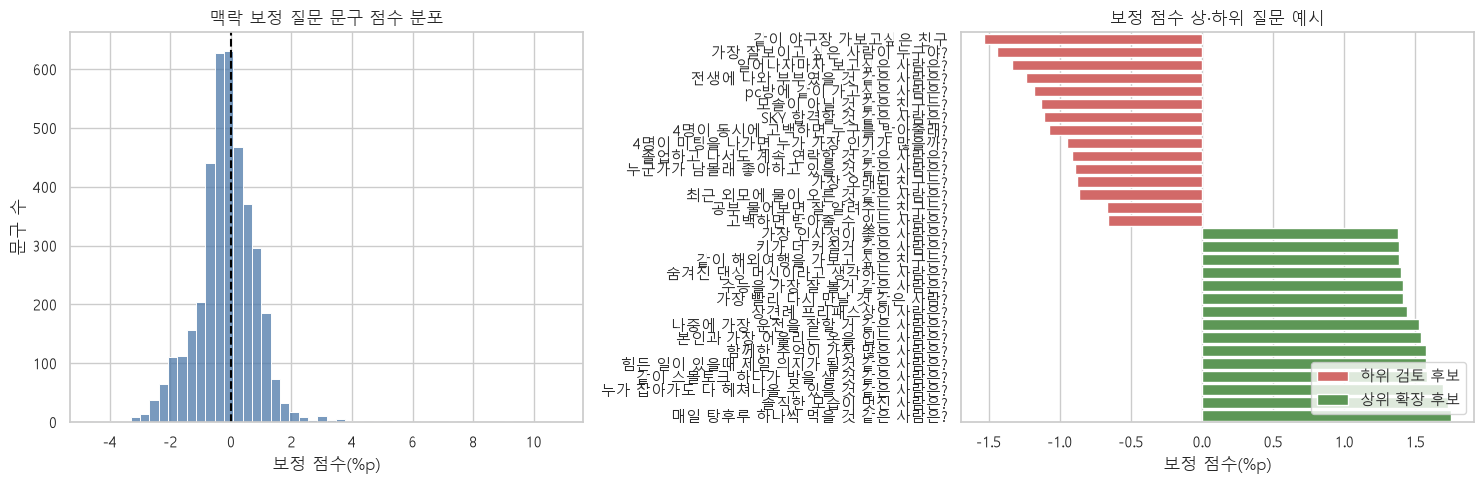

In [42]:
# 이전 셀에서 계산한 vote_residual을 질문 문구 단위로 집계한다.
assert 'vote_residual' in piece_follow.columns
text_target=(piece_follow.groupby('question_text_normalized',as_index=False)
    .agg(question_text=('question_text','first'),pieces=('question_piece_id','size'),
         users=('owner_user_id','nunique'),schools=('school_id','nunique'),
         vote_record_rate=('vote_record_exists','mean'),
         context_adjusted_residual=('vote_residual','mean'),
         residual_sd=('vote_residual','std'),first_at=('piece_created_at','min'),last_at=('piece_created_at','max')))

meta_cols=['question_text_normalized','piece_count','max_similarity_to_prior_text','semantic_novelty_to_prior',
           'nearest_cosine','refined_theme_id','token_text','tokens']
available=[c for c in meta_cols if c in unique_text.columns]
text_target=text_target.merge(unique_text[available],on='question_text_normalized',how='left')
text_target['theme_label_ko']=text_target.refined_theme_id.map(theme_label_ko)
pooled_sd=float(piece_follow.vote_residual.std())
text_target['residual_se']=text_target.residual_sd.fillna(pooled_sd)/np.sqrt(text_target.pieces)
raw_var=float(text_target.context_adjusted_residual.var(ddof=1))
noise_var=float(np.nanmean(text_target.residual_se**2))
tau2=max(raw_var-noise_var,1e-10)
text_target['eb_reliability']=tau2/(tau2+text_target.residual_se**2)
grand=float(np.average(text_target.context_adjusted_residual,weights=text_target.pieces))
text_target['adjusted_text_score']=(grand+text_target.eb_reliability*(text_target.context_adjusted_residual-grand))
text_target['adjusted_text_score_pp']=text_target.adjusted_text_score*100

text_score_overview=pd.DataFrame([{
    'unique_texts':len(text_target),'pieces':int(text_target.pieces.sum()),
    'between_text_variance':raw_var,'estimated_signal_variance_tau2':tau2,
    'median_reliability':text_target.eb_reliability.median(),
    'score_p05_pp':text_target.adjusted_text_score_pp.quantile(.05),
    'score_p95_pp':text_target.adjusted_text_score_pp.quantile(.95),
    'interpretation':'0은 동일 맥락 평균, 양수는 기대보다 높은 투표 기록률'
}])
show_final(text_score_overview,'01_text_score_overview')

reviewable=text_target[text_target.pieces>=500].copy()
text_score_examples=pd.concat([
    reviewable.nsmallest(15,'adjusted_text_score').assign(score_group='하위 검토 후보'),
    reviewable.nlargest(15,'adjusted_text_score').assign(score_group='상위 확장 후보')
])[[ 'score_group','question_text','pieces','users','schools','vote_record_rate','adjusted_text_score_pp','eb_reliability','theme_label_ko']]
show_final(text_score_examples,'01b_text_score_examples')
text_target.drop(columns=['tokens'],errors='ignore').to_csv(FINAL_DIR/'01c_text_level_adjusted_scores.csv',index=False,encoding='utf-8-sig')

fig,ax=plt.subplots(1,2,figsize=(15,5))
sns.histplot(text_target.adjusted_text_score_pp,bins=50,color='#4C78A8',ax=ax[0])
ax[0].axvline(0,color='black',ls='--'); ax[0].set(title='맥락 보정 질문 문구 점수 분포',xlabel='보정 점수(%p)',ylabel='문구 수')
plot_ex=text_score_examples.sort_values('adjusted_text_score_pp')
sns.barplot(data=plot_ex,y='question_text',x='adjusted_text_score_pp',hue='score_group',dodge=False,ax=ax[1],palette=['#E45756','#54A24B'])
ax[1].set(title='보정 점수 상·하위 질문 예시',xlabel='보정 점수(%p)',ylabel=''); ax[1].legend(loc='lower right')
plt.tight_layout(); plt.savefig(FINAL_FIG_DIR/'01_adjusted_text_scores.png',dpi=170,bbox_inches='tight'); plt.show()

## 17. 미관측 문구 예측력

문자 TF-IDF, Sentence-BERT, 구조화 특징과 결합모형을 고정 분할에서 비교한다.


,train_texts,validation_texts,test_texts,train_piece_weight,validation_piece_weight,test_piece_weight,overlap
0,1066,253,242,828270,194475,176918,0


,model,selected_parameter,validation_weighted_r2,validation_weighted_mae,validation_spearman,validation_spearman_p,validation_predicted_top_bottom_lift_pp,test_weighted_r2,test_weighted_mae,test_spearman,test_spearman_p,test_predicted_top_bottom_lift_pp,test_signal_decision
3,structured_ridge,0.1,0.578694,0.005218,0.666839,6.551439e-34,2.148376,0.552349,0.004757,0.594778,1.516904e-24,1.991578,재현 가능한 방향성 신호
1,char_tfidf_ridge,100,0.124995,0.008549,0.296068,1.636244e-06,1.071690,0.049428,0.008755,0.202124,1.573813e-03,0.956118,재현 가능한 방향성 신호
4,char_plus_sbert_ridge,10000,0.016203,0.008926,0.258370,3.180652e-05,1.022348,0.024083,0.008729,0.261549,3.795040e-05,0.951920,재현 가능한 방향성 신호
2,sbert_ridge,10000,0.014869,0.008931,0.258169,3.227598e-05,1.022348,0.023187,0.008733,0.261164,3.899718e-05,0.951493,재현 가능한 방향성 신호
5,sbert_extratrees,min_leaf=3,0.036156,0.009369,0.237414,1.377124e-04,0.988322,0.010265,0.009365,0.155503,1.546576e-02,0.618317,제품 자동결정에는 약함
0,intercept_baseline,none,-0.000710,0.009423,NaN,NaN,0.000000,-0.003562,0.009499,NaN,NaN,0.000000,제품 자동결정에는 약함


,model,selected_C,validation_auc,test_auc,test_average_precision,test_extreme_texts,decision
0,char_tfidf_logit,0.10,0.736669,0.688685,0.718746,146,검토 우선순위 보조 가능
2,char_plus_sbert_logit,0.01,0.636600,0.719647,0.731948,146,검토 우선순위 보조 가능
1,sbert_logit,0.01,0.635561,0.719460,0.731995,146,검토 우선순위 보조 가능


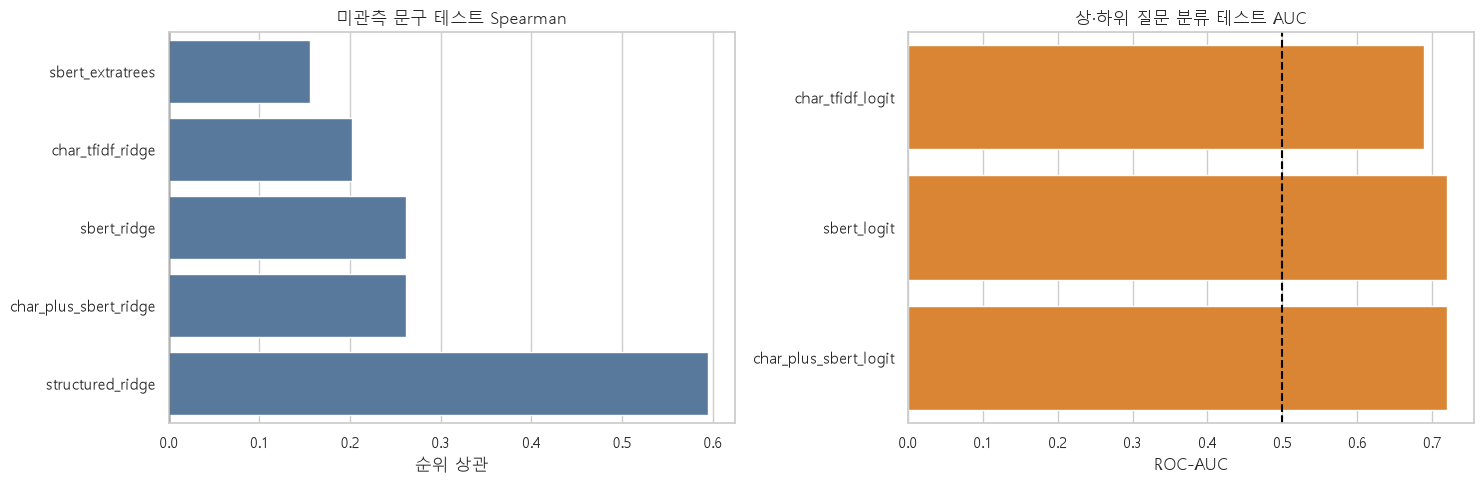

In [43]:
model_text=text_target[text_target.pieces>=50].copy().reset_index(drop=True)
embed_index=pd.Series(unique_text.index,index=unique_text.question_text_normalized).to_dict()
model_text['embedding_index']=model_text.question_text_normalized.map(embed_index)
model_text=model_text.dropna(subset=['embedding_index','adjusted_text_score']).reset_index(drop=True)
model_text['embedding_index']=model_text.embedding_index.astype(int)
bucket=model_text.question_text_normalized.map(stable_bucket)
train_idx=np.where(bucket<70)[0]; val_idx=np.where((bucket>=70)&(bucket<85))[0]; test_idx=np.where(bucket>=85)[0]
y=model_text.adjusted_text_score.to_numpy(float)
w=np.sqrt(model_text.pieces.clip(upper=model_text.pieces.quantile(.95))).to_numpy(float)
texts=model_text.question_text_normalized.fillna('').tolist()
E=embeddings[model_text.embedding_index.to_numpy()]

split_audit=pd.DataFrame([{
    'train_texts':len(train_idx),'validation_texts':len(val_idx),'test_texts':len(test_idx),
    'train_piece_weight':int(model_text.pieces.iloc[train_idx].sum()),
    'validation_piece_weight':int(model_text.pieces.iloc[val_idx].sum()),
    'test_piece_weight':int(model_text.pieces.iloc[test_idx].sum()),
    'overlap':len(set(train_idx)&set(val_idx))+len(set(train_idx)&set(test_idx))+len(set(val_idx)&set(test_idx))
}])
show_final(split_audit,'02_text_model_split_audit')

regression_rows=[]; model_predictions={}

def record_family(family,param,p_val,p_test):
    vm=weighted_metrics(y[val_idx],p_val,w[val_idx]); tm=weighted_metrics(y[test_idx],p_test,w[test_idx])
    regression_rows.append({'model':family,'selected_parameter':str(param),
                            **{f'validation_{k}':v for k,v in vm.items()},
                            **{f'test_{k}':v for k,v in tm.items()}})
    model_predictions[family]=(p_val,p_test)

baseline=np.average(y[train_idx],weights=w[train_idx])
record_family('intercept_baseline','none',np.repeat(baseline,len(val_idx)),np.repeat(baseline,len(test_idx)))

# 문자 TF-IDF Ridge
char_vec_final=TfidfVectorizer(analyzer='char_wb',ngram_range=(2,5),min_df=2,max_features=30000,sublinear_tf=True)
Xtr_char=char_vec_final.fit_transform([texts[i] for i in train_idx]); Xv_char=char_vec_final.transform([texts[i] for i in val_idx]); Xt_char=char_vec_final.transform([texts[i] for i in test_idx])
best=None
for alpha in [.1,1,10,100,1000]:
    m=Ridge(alpha=alpha,solver='lsqr'); m.fit(Xtr_char,y[train_idx],sample_weight=w[train_idx])
    pv=m.predict(Xv_char); rho=spearmanr(y[val_idx],pv).statistic
    if best is None or rho>best[0]: best=(rho,alpha,m,pv)
record_family('char_tfidf_ridge',best[1],best[3],best[2].predict(Xt_char))

# Sentence-BERT Ridge
scaler_emb=StandardScaler().fit(E[train_idx]); Etr=scaler_emb.transform(E[train_idx]); Ev=scaler_emb.transform(E[val_idx]); Et=scaler_emb.transform(E[test_idx])
best=None
for alpha in [1,10,100,1000,10000]:
    m=Ridge(alpha=alpha); m.fit(Etr,y[train_idx],sample_weight=w[train_idx])
    pv=m.predict(Ev); rho=spearmanr(y[val_idx],pv).statistic
    if best is None or rho>best[0]: best=(rho,alpha,m,pv)
record_family('sbert_ridge',best[1],best[3],best[2].predict(Et))

# 구조화 특징: 길이·신규성·테마
structured=pd.DataFrame({
    'text_len':model_text.question_text_normalized.str.len(),
    'prior_similarity':model_text.max_similarity_to_prior_text.fillna(0),
    'nearest_similarity':model_text.nearest_cosine.fillna(0),
    'log_pieces':np.log1p(model_text.pieces),
})
structured=pd.concat([structured,pd.get_dummies(model_text.refined_theme_id.astype('Int64').astype(str),prefix='theme',dtype=float)],axis=1).astype(float)
scaler_struct=StandardScaler().fit(structured.iloc[train_idx]); Str=scaler_struct.transform(structured.iloc[train_idx]); Sv=scaler_struct.transform(structured.iloc[val_idx]); St=scaler_struct.transform(structured.iloc[test_idx])
best=None
for alpha in [.1,1,10,100,1000]:
    m=Ridge(alpha=alpha); m.fit(Str,y[train_idx],sample_weight=w[train_idx])
    pv=m.predict(Sv); rho=spearmanr(y[val_idx],pv).statistic
    if best is None or rho>best[0]: best=(rho,alpha,m,pv)
record_family('structured_ridge',best[1],best[3],best[2].predict(St))

# 문자+의미 결합 Ridge
Xtr_comb=sparse.hstack([Xtr_char,sparse.csr_matrix(Etr)]).tocsr(); Xv_comb=sparse.hstack([Xv_char,sparse.csr_matrix(Ev)]).tocsr(); Xt_comb=sparse.hstack([Xt_char,sparse.csr_matrix(Et)]).tocsr()
best=None
for alpha in [1,10,100,1000,10000]:
    m=Ridge(alpha=alpha,solver='lsqr'); m.fit(Xtr_comb,y[train_idx],sample_weight=w[train_idx])
    pv=m.predict(Xv_comb); rho=spearmanr(y[val_idx],pv).statistic
    if best is None or rho>best[0]: best=(rho,alpha,m,pv)
record_family('char_plus_sbert_ridge',best[1],best[3],best[2].predict(Xt_comb))

# 임베딩 비선형 ExtraTrees
pca_final=PCA(n_components=min(60,Etr.shape[1],len(train_idx)-1),random_state=42).fit(Etr)
Ptr=pca_final.transform(Etr); Pv=pca_final.transform(Ev); Pt=pca_final.transform(Et)
best=None
for leaf in [3,8,15,30]:
    m=ExtraTreesRegressor(n_estimators=350,min_samples_leaf=leaf,max_features=.7,random_state=42,n_jobs=-1)
    m.fit(Ptr,y[train_idx],sample_weight=w[train_idx]); pv=m.predict(Pv); rho=spearmanr(y[val_idx],pv).statistic
    if best is None or rho>best[0]: best=(rho,leaf,m,pv)
record_family('sbert_extratrees',f'min_leaf={best[1]}',best[3],best[2].predict(Pt))

text_model_benchmark=pd.DataFrame(regression_rows)
text_model_benchmark['test_signal_decision']=np.where(
    (text_model_benchmark.test_spearman>=.15)&(text_model_benchmark.test_spearman_p<.01)&(text_model_benchmark.test_predicted_top_bottom_lift_pp>.20),
    '재현 가능한 방향성 신호','제품 자동결정에는 약함')
show_final(text_model_benchmark.sort_values('validation_spearman',ascending=False),'02b_text_regression_model_benchmark')

# 상·하위 30% 문구 분류. 중간 문구는 제외한다.
def extreme_labels(indices):
    yy=y[indices]; lo,hi=np.quantile(yy,[.3,.7]); keep=(yy<=lo)|(yy>=hi); return indices[keep],(yy[keep]>=hi).astype(int)
tri,ytri=extreme_labels(train_idx); vai,yvai=extreme_labels(val_idx); tei,ytei=extreme_labels(test_idx)
class_rows=[]
for family,Xa,Xb,Xc in [
    ('char_tfidf_logit',Xtr_char,Xv_char,Xt_char),
    ('sbert_logit',Etr,Ev,Et),
    ('char_plus_sbert_logit',Xtr_comb,Xv_comb,Xt_comb)]:
    pos_train=np.searchsorted(train_idx,tri); pos_val=np.searchsorted(val_idx,vai); pos_test=np.searchsorted(test_idx,tei)
    best=None
    for C in [.01,.1,1,10]:
        m=LogisticRegression(C=C,max_iter=3000,class_weight='balanced',solver='liblinear')
        m.fit(Xa[pos_train],ytri,sample_weight=w[tri]); pv=m.predict_proba(Xb[pos_val])[:,1]
        auc=roc_auc_score(yvai,pv)
        if best is None or auc>best[0]: best=(auc,C,m,pv)
    pt=best[2].predict_proba(Xc[pos_test])[:,1]
    class_rows.append({'model':family,'selected_C':best[1],'validation_auc':best[0],
                       'test_auc':roc_auc_score(ytei,pt),'test_average_precision':average_precision_score(ytei,pt),
                       'test_extreme_texts':len(ytei)})
text_quality_classifier=pd.DataFrame(class_rows)
text_quality_classifier['decision']=np.where(text_quality_classifier.test_auc>=.65,'검토 우선순위 보조 가능','자동 승인·삭제 불가')
show_final(text_quality_classifier.sort_values('validation_auc',ascending=False),'02c_text_quality_classifier')

fig,ax=plt.subplots(1,2,figsize=(15,5))
regplot=text_model_benchmark[text_model_benchmark.model.ne('intercept_baseline')].sort_values('test_spearman')
sns.barplot(data=regplot,y='model',x='test_spearman',color='#4C78A8',ax=ax[0]); ax[0].axvline(0,color='black',lw=1); ax[0].set(title='미관측 문구 테스트 Spearman',xlabel='순위 상관',ylabel='')
sns.barplot(data=text_quality_classifier.sort_values('test_auc'),y='model',x='test_auc',color='#F58518',ax=ax[1]); ax[1].axvline(.5,color='black',ls='--'); ax[1].set(title='상·하위 질문 분류 테스트 AUC',xlabel='ROC-AUC',ylabel='')
plt.tight_layout(); plt.savefig(FINAL_FIG_DIR/'02_text_model_benchmark.png',dpi=170,bbox_inches='tight'); plt.show()

## 18. 질문 의도와 성과 표현

질문 의도 사전과 상·하위 성과 문구의 형태소 차이를 확인한다.


,intent,unique_texts,piece_share,adjusted_effect_pp,ci95_low_pp,ci95_high_pp,p_value,fdr_q,decision
8,학교·일상,108,0.024257,-0.252637,-0.610198,0.104924,0.166106,0.382490,효과 작음 또는 불확실
1,관계·호감,1062,0.201497,-0.193765,-0.320357,-0.067172,0.002700,0.029702,문구 실험 후보
2,함께하기,381,0.101638,-0.124305,-0.303458,0.054849,0.173859,0.382490,효과 작음 또는 불확실
10,음식·생활,252,0.055225,-0.076502,-0.303202,0.150199,0.508353,0.559188,효과 작음 또는 불확실
6,미래·가정,2061,0.436354,-0.059174,-0.163811,0.045463,0.267691,0.436104,효과 작음 또는 불확실
7,부정·위험,296,0.089347,-0.007543,-0.177334,0.162249,0.930618,0.930618,효과 작음 또는 불확실
5,놀이·유머,177,0.042891,0.100970,-0.119683,0.321622,0.369787,0.464635,효과 작음 또는 불확실
0,외모·스타일,169,0.051718,0.123082,-0.099070,0.345234,0.277521,0.436104,효과 작음 또는 불확실
9,SNS·트렌드,79,0.019849,0.167993,-0.207185,0.543171,0.380156,0.464635,효과 작음 또는 불확실
3,능력·성취,187,0.062079,0.226866,0.044202,0.409529,0.014923,0.054716,효과 작음 또는 불확실


,direction,term,high_texts,low_texts,log_odds_z
115,저성과 질문 상대 우세,친구,40,74,-3.531963
67,저성과 질문 상대 우세,싶,32,62,-3.381348
69,저성과 질문 상대 우세,싶 친구,2,16,-2.879012
87,저성과 질문 상대 우세,이,16,33,-2.584427
88,저성과 질문 상대 우세,이 것,5,17,-2.502426
23,저성과 질문 상대 우세,나,12,25,-2.257914
13,저성과 질문 상대 우세,같 친구,9,20,-2.126279
106,저성과 질문 상대 우세,좋아하,4,12,-1.973917
98,저성과 질문 상대 우세,잘 어울리,7,15,-1.775050
68,저성과 질문 상대 우세,싶 사람,28,40,-1.709917


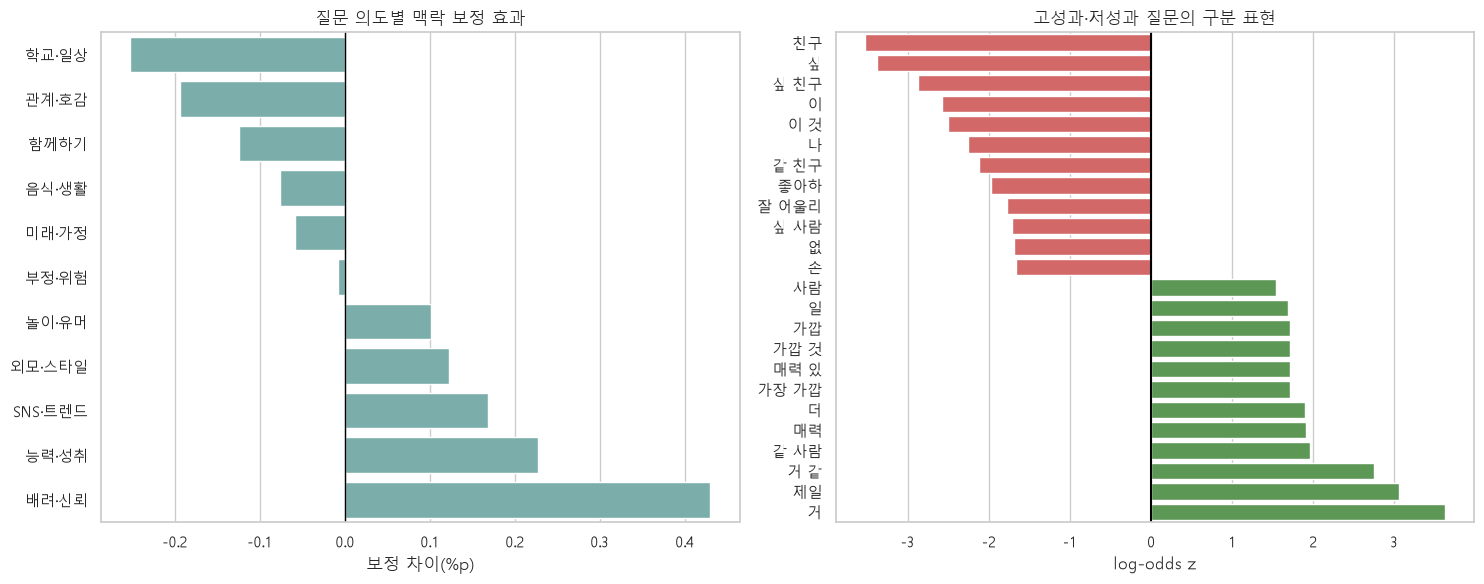

In [44]:
intent_patterns={
    '외모·스타일':r'예쁘|잘생|귀엽|외모|얼굴|키가|몸매|옷|머리|향기|매력',
    '관계·호감':r'친구|친하|사귀|연애|좋아하|결혼|짝사랑|호감',
    '함께하기':r'같이|함께|하고 싶|가고 싶|놀고 싶|보고 싶',
    '능력·성취':r'잘할|잘 할|공부|성공|리드|능력|똑똑|대표|회장',
    '배려·신뢰':r'챙겨|믿|든든|배려|고민|솔직|의지|착하',
    '놀이·유머':r'웃|재밌|장난|게임|놀|유쾌|드립',
    '미래·가정':r'것 같|할 것|한다면|라면|나중|미래|전생|평생',
    '부정·위험':r'싫|못 |최악|무섭|죽|울|화가|변덕|싸움|잡아가',
    '학교·일상':r'학교|시험|수업|선생|우리 반|급식|학생|대학교',
    'SNS·트렌드':r'인스타|틱톡|유튜브|릴스|연예인|아이돌|팔로워',
    '음식·생활':r'먹|밥|음식|카페|잠|집|요리|라면|탕후루',
}
intent_cols=[]
for label,pattern in intent_patterns.items():
    col='intent_'+str(len(intent_cols)).zfill(2)
    text_target[col]=text_target.question_text_normalized.str.contains(pattern,regex=True,na=False).astype(int)
    intent_cols.append(col)
intent_label=dict(zip(intent_cols,intent_patterns.keys()))
text_target['intent_count']=text_target[intent_cols].sum(axis=1)

X_int=text_target[intent_cols].astype(float).copy()
X_int.columns=[intent_label[c] for c in intent_cols]
X_int['문구길이_z']=zscore(text_target.question_text_normalized.str.len()).fillna(0)
X_int['기존유사도_z']=zscore(text_target.max_similarity_to_prior_text.fillna(0)).fillna(0)
theme_dummies=pd.get_dummies(text_target.refined_theme_id.astype('Int64').astype(str),prefix='theme',drop_first=True,dtype=float)
X_wls=sm.add_constant(pd.concat([X_int,theme_dummies],axis=1).astype(float))
wls=sm.WLS(text_target.adjusted_text_score,X_wls,weights=np.sqrt(text_target.pieces)).fit(cov_type='HC3')
intent_effect=[]
for label in intent_patterns:
    intent_effect.append({'intent':label,'unique_texts':int((X_int[label]>0).sum()),
                          'piece_share':np.average((X_int[label]>0).astype(float),weights=text_target.pieces),
                          'adjusted_effect_pp':wls.params[label]*100,'ci95_low_pp':wls.conf_int().loc[label,0]*100,
                          'ci95_high_pp':wls.conf_int().loc[label,1]*100,'p_value':wls.pvalues[label]})
intent_effect=pd.DataFrame(intent_effect)
intent_effect['fdr_q']=multipletests(intent_effect.p_value,method='fdr_bh')[1]
intent_effect['decision']=np.where((intent_effect.fdr_q<.05)&(intent_effect.adjusted_effect_pp.abs()>=.15),'문구 실험 후보','효과 작음 또는 불확실')
show_final(intent_effect.sort_values('adjusted_effect_pp'),'03_intent_effects_adjusted')

# 고성과·저성과 질문의 형태소 log-odds. 공급량이 아니라 문구 유형을 보기 위해 문구당 1표를 준다.
token_lookup=unique_text.set_index('question_text_normalized').token_text
text_target['token_text']=text_target.question_text_normalized.map(token_lookup).fillna('')
eligible=text_target[text_target.pieces>=200].copy()
lo,hi=eligible.adjusted_text_score.quantile([.2,.8])
contrast=eligible[(eligible.adjusted_text_score<=lo)|(eligible.adjusted_text_score>=hi)].copy()
contrast['high_score']=(contrast.adjusted_text_score>=hi).astype(int)
cv_terms=CountVectorizer(token_pattern=r'(?u)\b\w+\b',ngram_range=(1,2),min_df=5,max_features=7000,binary=True)
Xt=cv_terms.fit_transform(contrast.token_text)
terms=np.array(cv_terms.get_feature_names_out()); high_mask=contrast.high_score.eq(1).to_numpy(); low_mask=~high_mask
h=np.asarray(Xt[high_mask].sum(axis=0)).ravel(); l=np.asarray(Xt[low_mask].sum(axis=0)).ravel()
alpha=.5; H=h.sum(); L=l.sum(); V=len(terms)
delta=np.log((h+alpha)/(H-h+alpha*V))-np.log((l+alpha)/(L-l+alpha*V))
z=delta/np.sqrt(1/(h+alpha)+1/(l+alpha))
term_contrast=pd.DataFrame({'term':terms,'high_texts':h.astype(int),'low_texts':l.astype(int),'log_odds_z':z})
term_examples=pd.concat([term_contrast.nsmallest(20,'log_odds_z').assign(direction='저성과 질문 상대 우세'),
                         term_contrast.nlargest(20,'log_odds_z').assign(direction='고성과 질문 상대 우세')])
show_final(term_examples[['direction','term','high_texts','low_texts','log_odds_z']],'03b_high_low_text_term_contrast')
term_contrast.to_csv(FINAL_DIR/'03c_all_term_log_odds.csv',index=False,encoding='utf-8-sig')

fig,ax=plt.subplots(1,2,figsize=(15,6))
sns.barplot(data=intent_effect.sort_values('adjusted_effect_pp'),y='intent',x='adjusted_effect_pp',color='#72B7B2',ax=ax[0]); ax[0].axvline(0,color='black',lw=1); ax[0].set(title='질문 의도별 맥락 보정 효과',xlabel='보정 차이(%p)',ylabel='')
plot_terms=pd.concat([term_contrast.nsmallest(12,'log_odds_z'),term_contrast.nlargest(12,'log_odds_z')]).sort_values('log_odds_z')
sns.barplot(data=plot_terms,y='term',x='log_odds_z',hue=plot_terms.log_odds_z.gt(0),dodge=False,palette=['#E45756','#54A24B'],ax=ax[1]); ax[1].axvline(0,color='black'); ax[1].set(title='고성과·저성과 질문의 구분 표현',xlabel='log-odds z',ylabel=''); ax[1].legend_.remove()
plt.tight_layout(); plt.savefig(FINAL_FIG_DIR/'03_intent_and_term_contrast.png',dpi=170,bbox_inches='tight'); plt.show()

## 19. 의미 이웃 성과와 신규성

의미상 이웃의 성과와 기존 문구 대비 신규성이 보정 성과와 연결되는지 확인한다.


,texts,neighbors,spearman,spearman_p,weighted_r2,top_bottom_lift_pp,decision
0,1561,30,0.231902,1.666277e-20,0.012645,0.766521,의미 영역을 검토 우선순위에 활용


,region,question_text,pieces,theme_label_ko,adjusted_text_score_pp,semantic_neighbor_score_pp,nearest_cosine
897,저성과 의미 영역,안 친한데 연락해보고 싶은 사람,319,친해지고 싶은 관계,-1.046449,-1.542316,0.851998
549,저성과 의미 영역,만나자고하면 맨날 귀찮다고 하는 친구,256,친해지고 싶은 관계,-1.491527,-1.516502,0.636619
485,저성과 의미 영역,덜 친하지만 짱친 되고 싶은 사람?,328,친해지고 싶은 관계,-0.864389,-1.468891,0.746130
1008,저성과 의미 영역,연인이 친구 깻잎 떼주면 서운해할 것 같은 친구!,391,친해지고 싶은 관계,-1.903637,-1.450829,0.720170
1031,저성과 의미 영역,왜 애인이 안 생기는지 모르겠는 친구는?,352,친해지고 싶은 관계,-1.529105,-1.448782,0.773033
327,저성과 의미 영역,나는 얘를 아는데 얘는 나를 모른다,247,친구 성격·친화력,-2.256594,-1.404991,0.591801
1260,저성과 의미 영역,좋고 싫음이 분명한 친구,1524,친구 성격·친화력,0.822308,-1.388079,0.717832
750,저성과 의미 영역,사과할 일 있는데 연락 못하고 있는 친구,156,친해지고 싶은 관계,-4.542343,-1.379476,0.727050
1377,저성과 의미 영역,친해지고 싶었지만 타이밍을 놓쳐서 친해지지 못한 친구는?,310,친해지고 싶은 관계,-2.735018,-1.369214,0.773875
513,저성과 의미 영역,떨어져있어도 자꾸 생각나는 친구,351,친구 성격·친화력,-1.371080,-1.334350,0.752808


,prior_similarity_band,unique_texts,pieces,weighted_adjusted_score_pp,ci95_low_pp,ci95_high_pp
0,초기 기준군,1,1798,1.090872,1.090872,1.090872
1,0-.50,73,85716,0.393687,0.166466,0.620908
2,.50-.60,419,233601,-0.014071,-0.140186,0.112044
3,.60-.70,1026,402823,-0.060621,-0.147249,0.026008
4,.70-.75,701,183359,-0.223376,-0.334485,-0.112267
5,.75-.80,624,143771,-0.314752,-0.426101,-0.203403
6,.80-.85,434,103177,-0.129694,-0.266704,0.007316
7,.85-.90,348,60181,-0.117151,-0.253093,0.018792
8,.90-.95,191,37035,-0.200067,-0.399237,-0.000896
9,.95-1.00,81,14015,-0.290255,-0.572934,-0.007575


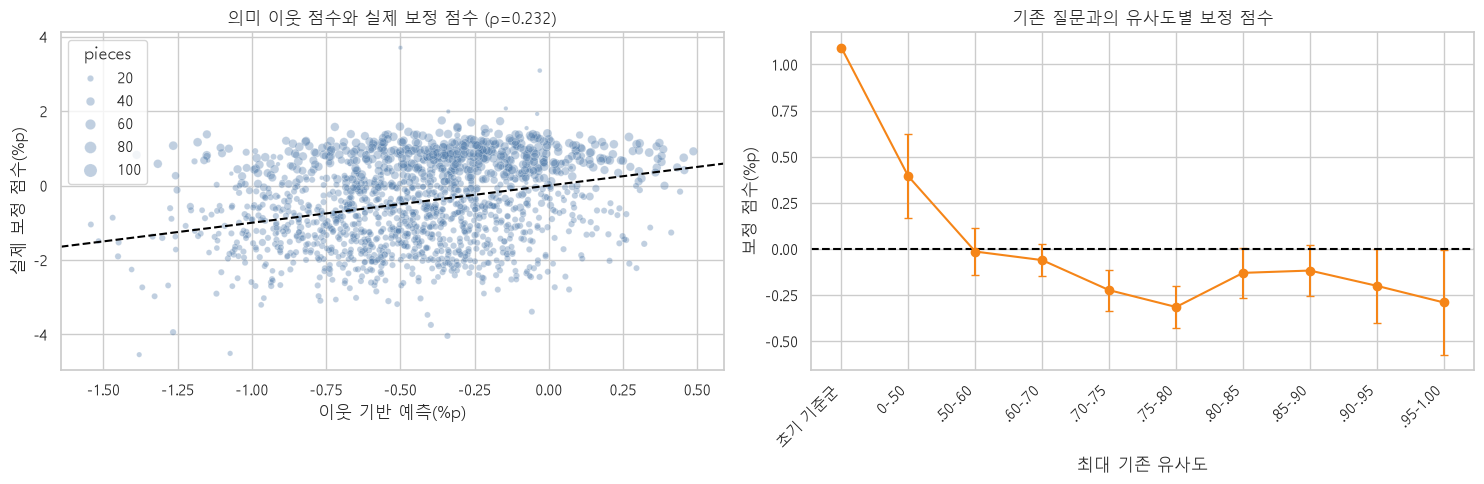

In [45]:
# model_text 순서의 임베딩에서 자기 자신을 제외한 30개 이웃
nbr_perf=NearestNeighbors(n_neighbors=min(31,len(model_text)),metric='cosine',n_jobs=-1).fit(E)
dist_perf,idx_perf=nbr_perf.kneighbors(E)
neighbor_sim=np.clip(1-dist_perf[:,1:],0,1); neighbor_idx=idx_perf[:,1:]
neighbor_weight=np.maximum(neighbor_sim,1e-4)**3
semantic_pred=(y[neighbor_idx]*neighbor_weight).sum(axis=1)/neighbor_weight.sum(axis=1)
rho,p=spearmanr(y,semantic_pred)
semantic_model_eval=pd.DataFrame([{
    'texts':len(model_text),'neighbors':neighbor_idx.shape[1],'spearman':rho,'spearman_p':p,
    'weighted_r2':weighted_metrics(y,semantic_pred,w)['weighted_r2'],
    'top_bottom_lift_pp':weighted_metrics(y,semantic_pred,w)['predicted_top_bottom_lift_pp'],
    'decision':'의미 영역을 검토 우선순위에 활용' if rho>=.15 and p<.01 else '의미만으로 자동 결정하지 않음'
}])
show_final(semantic_model_eval,'04_semantic_neighbor_model_eval')
model_text['semantic_neighbor_score_pp']=semantic_pred*100
semantic_regions=pd.concat([
    model_text.nsmallest(15,'semantic_neighbor_score_pp').assign(region='저성과 의미 영역'),
    model_text.nlargest(15,'semantic_neighbor_score_pp').assign(region='고성과 의미 영역')
])[[ 'region','question_text','pieces','theme_label_ko','adjusted_text_score_pp','semantic_neighbor_score_pp','nearest_cosine']]
show_final(semantic_regions,'04b_semantic_performance_regions')

# 기존 문구 최대 유사도별 보정 점수. 초기 질문군의 0은 별도 구간으로 둔다.
novelty_base=text_target.copy()
novelty_base['prior_similarity_band']=pd.cut(novelty_base.max_similarity_to_prior_text.fillna(0),
    [-.001,.001,.50,.60,.70,.75,.80,.85,.90,.95,1.0001],
    labels=['초기 기준군','0-.50','.50-.60','.60-.70','.70-.75','.75-.80','.80-.85','.85-.90','.90-.95','.95-1.00'])
novelty_curve=[]
for band,g in novelty_base.groupby('prior_similarity_band',observed=True):
    ww=np.sqrt(g.pieces); mean=np.average(g.adjusted_text_score,weights=ww)
    n_eff=(ww.sum()**2)/(np.square(ww).sum())
    var=np.average((g.adjusted_text_score-mean)**2,weights=ww)
    se=np.sqrt(var/max(n_eff,1))
    novelty_curve.append({'prior_similarity_band':str(band),'unique_texts':len(g),'pieces':int(g.pieces.sum()),
                          'weighted_adjusted_score_pp':mean*100,'ci95_low_pp':(mean-1.96*se)*100,'ci95_high_pp':(mean+1.96*se)*100})
novelty_curve=pd.DataFrame(novelty_curve)
show_final(novelty_curve,'04c_novelty_performance_curve')

fig,ax=plt.subplots(1,2,figsize=(15,5))
sns.scatterplot(x=semantic_pred*100,y=y*100,size=np.sqrt(model_text.pieces),sizes=(10,90),alpha=.35,color='#4C78A8',ax=ax[0]); ax[0].axline((0,0),slope=1,color='black',ls='--'); ax[0].set(title=f'의미 이웃 점수와 실제 보정 점수 (ρ={rho:.3f})',xlabel='이웃 기반 예측(%p)',ylabel='실제 보정 점수(%p)')
xx=np.arange(len(novelty_curve)); ax[1].errorbar(xx,novelty_curve.weighted_adjusted_score_pp,
    yerr=[novelty_curve.weighted_adjusted_score_pp-novelty_curve.ci95_low_pp,novelty_curve.ci95_high_pp-novelty_curve.weighted_adjusted_score_pp],marker='o',capsize=3,color='#F58518')
ax[1].set_xticks(xx); ax[1].set_xticklabels(novelty_curve.prior_similarity_band,rotation=45,ha='right'); ax[1].axhline(0,color='black',ls='--'); ax[1].set(title='기존 질문과의 유사도별 보정 점수',xlabel='최대 기존 유사도',ylabel='보정 점수(%p)')
plt.tight_layout(); plt.savefig(FINAL_FIG_DIR/'04_semantic_and_novelty_performance.png',dpi=170,bbox_inches='tight'); plt.show()

## 20. 질문 테마와 후보 관계

테마별 후보 관계 구성과 실제 선택 관계를 비교한다.


,theme_id,theme_label_ko,relation_group,candidate_rows,selections,pool_share,selected_share,selection_composition_lift,log2_lift
4,10,배려·유쾌함,같은 학년,2106,159.0,0.008544,0.002526,0.295620,-1.758186
7,2,친해지고 싶은 관계,같은 학년,1025,86.0,0.008447,0.002779,0.328970,-1.603972
10,5,함께 놀기·여행,같은 학년,2001,170.0,0.008368,0.002785,0.332845,-1.587077
76,3,SNS·연예인 이미지,같은 학년,1358,119.0,0.008936,0.003067,0.343199,-1.542885
160,19,결혼·가족·미래,같은 학년,1550,138.0,0.009246,0.003224,0.348642,-1.520183
155,20,두려움·부정 성향,같은 학년,1245,116.0,0.008955,0.003269,0.365014,-1.453976
94,6,능력·성숙·신뢰,같은 학년,3546,333.0,0.009035,0.003321,0.367631,-1.443672
24,4,연락·전화,같은 학년,2301,219.0,0.008982,0.003349,0.372829,-1.423414
75,11,음악·춤,같은 학년,1124,107.0,0.008950,0.003341,0.373222,-1.421893
96,14,친구 성격·친화력,기타/미상,1486,143.0,0.003109,0.001172,0.376993,-1.407389


,theme_id,theme_label_ko,relative_overselected_relation,overselection_lift,relative_underselected_relation,underselection_lift,interpretation
0,0,학교·공부,상호 친구,1.008596,같은 학년,0.440666,후보 생성 정책이 아니라 선택 구성의 상대 차이
1,1,생일·선물,상호 친구,1.010076,같은 학년,0.420707,후보 생성 정책이 아니라 선택 구성의 상대 차이
2,2,친해지고 싶은 관계,상호 친구,1.010624,같은 학년,0.328970,후보 생성 정책이 아니라 선택 구성의 상대 차이
3,3,SNS·연예인 이미지,상호 친구,1.010423,같은 학년,0.343199,후보 생성 정책이 아니라 선택 구성의 상대 차이
4,4,연락·전화,상호 친구,1.009814,같은 학년,0.372829,후보 생성 정책이 아니라 선택 구성의 상대 차이
5,5,함께 놀기·여행,상호 친구,1.010337,같은 학년,0.332845,후보 생성 정책이 아니라 선택 구성의 상대 차이
6,6,능력·성숙·신뢰,상호 친구,1.009802,같은 학년,0.367631,후보 생성 정책이 아니라 선택 구성의 상대 차이
7,7,집·잠·생활습관,상호 친구,1.009925,상호 친구,1.009925,후보 생성 정책이 아니라 선택 구성의 상대 차이
8,8,인생·극한상황,상호 친구,1.009960,상호 친구,1.009960,후보 생성 정책이 아니라 선택 구성의 상대 차이
9,9,매력·외모,상호 친구,1.009770,같은 학년,0.389937,후보 생성 정책이 아니라 선택 구성의 상대 차이


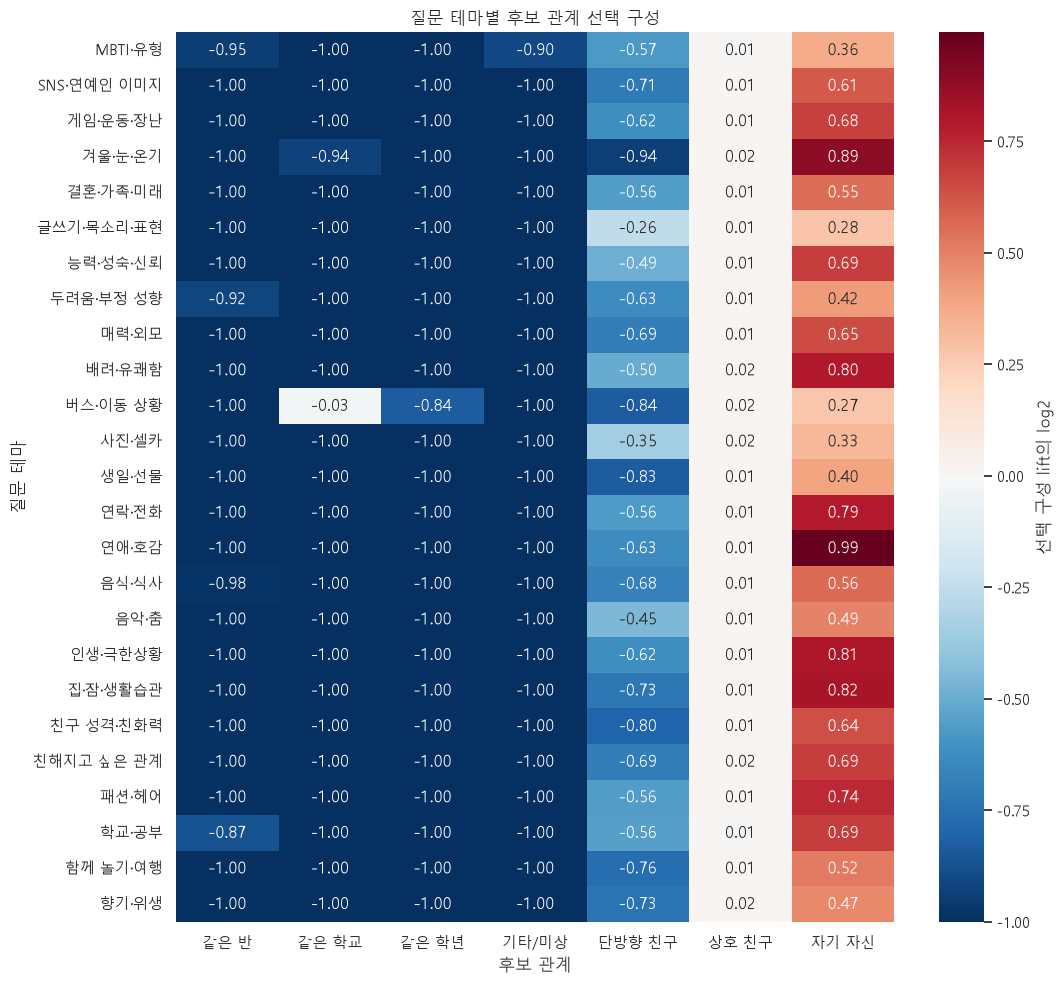

In [46]:
piece_theme_final=piece_follow[['question_piece_id','analysis_theme_id']].drop_duplicates().copy()
piece_theme_final['question_piece_id']=piece_theme_final.question_piece_id.map(str).astype('object')
piece_theme_final['analysis_theme_id']=pd.to_numeric(piece_theme_final.analysis_theme_id,errors='raise').astype('int64')
con.register('piece_theme_final',piece_theme_final)
theme_relation=con.execute("""
WITH x AS (
 SELECT CAST(c.question_piece_id AS VARCHAR) question_piece_id,
        CAST(t.analysis_theme_id AS INTEGER) theme_id,
        CASE WHEN c.self_candidate_flag=1 THEN '자기 자신'
             WHEN c.current_friend_mutual_flag=1 THEN '상호 친구'
             WHEN c.current_friend_any_direction_flag=1 THEN '단방향 친구'
             WHEN c.same_school_grade_class_current_flag=1 THEN '같은 반'
             WHEN c.same_school_grade_current_flag=1 THEN '같은 학년'
             WHEN c.same_school_current_flag=1 THEN '같은 학교'
             ELSE '기타/미상' END relation_group,
        CAST(c.selected_candidate_canonical_pair_flag AS INTEGER) selected
 FROM candidate c JOIN piece_theme_final t ON CAST(c.question_piece_id AS VARCHAR)=t.question_piece_id
 WHERE c.analysis_eligible_candidate_canonical_flag=1
), agg AS (
 SELECT theme_id,relation_group,COUNT(*) candidate_rows,SUM(selected) selections
 FROM x GROUP BY 1,2
)
SELECT * FROM agg
""").df()
theme_relation['theme_label_ko']=theme_relation.theme_id.map(theme_label_ko)
theme_relation['pool_share']=theme_relation.candidate_rows/theme_relation.groupby('theme_id').candidate_rows.transform('sum')
theme_relation['selected_share']=theme_relation.selections/theme_relation.groupby('theme_id').selections.transform('sum')
theme_relation['row_selection_rate']=theme_relation.selections/theme_relation.candidate_rows
theme_relation['selection_composition_lift']=theme_relation.selected_share/theme_relation.pool_share
theme_relation['log2_lift']=np.log2(theme_relation.selection_composition_lift.replace(0,np.nan))
theme_relation.to_csv(FINAL_DIR/'05_theme_candidate_relation_full.csv',index=False,encoding='utf-8-sig')

theme_relation_signal=(theme_relation[(theme_relation.candidate_rows>=1000)&(theme_relation.selections>=50)]
    .assign(abs_log2_lift=lambda d:d.log2_lift.abs()).sort_values('abs_log2_lift',ascending=False)
    [['theme_id','theme_label_ko','relation_group','candidate_rows','selections','pool_share','selected_share','selection_composition_lift','log2_lift']].head(40))
show_final(theme_relation_signal,'05b_theme_relation_selection_signal')

theme_recommend=[]
for tid,g in theme_relation[(theme_relation.candidate_rows>=1000)&(theme_relation.selections>=50)].groupby('theme_id'):
    high=g.loc[g.log2_lift.idxmax()]; low=g.loc[g.log2_lift.idxmin()]
    theme_recommend.append({'theme_id':tid,'theme_label_ko':theme_label_ko.get(int(tid),'검토 필요'),
                            'relative_overselected_relation':high.relation_group,'overselection_lift':high.selection_composition_lift,
                            'relative_underselected_relation':low.relation_group,'underselection_lift':low.selection_composition_lift,
                            'interpretation':'후보 생성 정책이 아니라 선택 구성의 상대 차이'})
theme_recommend=pd.DataFrame(theme_recommend)
show_final(theme_recommend,'05c_theme_relation_recommendation_audit')

heat=theme_relation.pivot(index='theme_label_ko',columns='relation_group',values='log2_lift').clip(-1,1)
fig,ax=plt.subplots(figsize=(11,10))
sns.heatmap(heat,cmap='RdBu_r',center=0,annot=True,fmt='.2f',ax=ax,cbar_kws={'label':'선택 구성 lift의 log2'})
ax.set(title='질문 테마별 후보 관계 선택 구성',xlabel='후보 관계',ylabel='질문 테마')
plt.tight_layout(); plt.savefig(FINAL_FIG_DIR/'05_theme_relation_lift.png',dpi=170,bbox_inches='tight'); plt.show()

## 21. 콘텐츠 수명 예측

초기 7일 공급 신호와 텍스트 특징이 30일 이후 재사용을 얼마나 설명하는지 확인한다.


,model,selected_C,test_auc,test_average_precision,test_brier,train_texts,test_texts,positive_rate,auc_gain_vs_baseline,decision
0,초기7일 기준모형,10.0,0.63348,0.971732,0.238342,2728,1170,0.949205,0.00000,초기 공급 신호가 대부분 설명
1,기준+텍스트·의미,0.1,0.62065,0.970746,0.229736,2728,1170,0.949205,-0.01283,초기 공급 신호가 대부분 설명


,early_volume_quartile,texts,median_early_pieces,used_after_30d
0,Q1,975,9.0,0.969231
1,Q2,974,23.0,0.917864
2,Q3,974,173.0,0.940452
3,Q4,975,390.0,0.969231


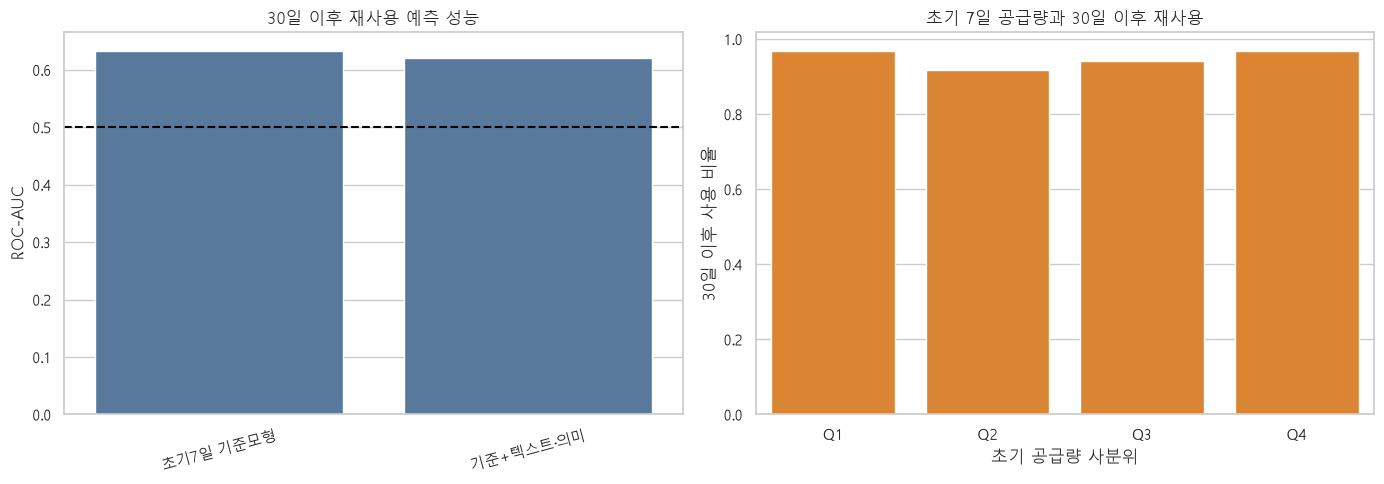

In [47]:
life_rows=[]; obs_end=piece_follow.piece_created_at.max()
for norm,g in piece_follow.groupby('question_text_normalized'):
    g=g.sort_values('piece_created_at'); start=g.piece_created_at.iloc[0]
    if start>obs_end-pd.Timedelta(days=30): continue
    early=g[g.piece_created_at<start+pd.Timedelta(days=7)]
    life_rows.append({'question_text_normalized':norm,'first_at':start,'first_month':start.to_period('M').strftime('%Y-%m'),
                      'early7_pieces':len(early),'early7_users':early.owner_user_id.nunique(),
                      'early7_schools':early.school_id.nunique(),'early7_vote_rate':early.vote_record_exists.mean(),
                      'used_after_30d':int((g.piece_created_at>=start+pd.Timedelta(days=30)).any())})
life_model=pd.DataFrame(life_rows).merge(text_target[['question_text_normalized','embedding_index' if 'embedding_index' in text_target else 'pieces']],on='question_text_normalized',how='left')
life_model['embedding_index']=life_model.question_text_normalized.map(embed_index).astype(int)
life_model=life_model.merge(text_target[['question_text_normalized','max_similarity_to_prior_text','refined_theme_id']+intent_cols],on='question_text_normalized',how='left')

li_train,li_test=train_test_split(np.arange(len(life_model)),test_size=.30,random_state=42,stratify=life_model.used_after_30d)
y_life=life_model.used_after_30d.to_numpy()
base_life=pd.DataFrame({
    'log_early_pieces':np.log1p(life_model.early7_pieces),
    'log_early_users':np.log1p(life_model.early7_users),
    'early_schools':life_model.early7_schools,
    'early_vote_rate':life_model.early7_vote_rate.fillna(life_model.early7_vote_rate.mean()),
})
base_life=pd.concat([base_life,pd.get_dummies(life_model.first_month,prefix='month',drop_first=True,dtype=float)],axis=1)
sc_life=StandardScaler().fit(base_life.iloc[li_train]); Btr=sc_life.transform(base_life.iloc[li_train]); Bt=sc_life.transform(base_life.iloc[li_test])
E_life=embeddings[life_model.embedding_index.to_numpy()]
pca_life=PCA(n_components=min(40,len(li_train)-1,E_life.shape[1]),random_state=42).fit(E_life[li_train])
Ptr_life=pca_life.transform(E_life[li_train]); Pt_life=pca_life.transform(E_life[li_test])
extra_life=life_model[['max_similarity_to_prior_text']+intent_cols].fillna(0).to_numpy(float)
sc_extra=StandardScaler().fit(extra_life[li_train]); Xtr_full=np.hstack([Btr,sc_extra.transform(extra_life[li_train]),Ptr_life]); Xt_full=np.hstack([Bt,sc_extra.transform(extra_life[li_test]),Pt_life])

life_perf=[]
for name,Xa,Xb in [('초기7일 기준모형',Btr,Bt),('기준+텍스트·의미',Xtr_full,Xt_full)]:
    best=None
    for C in [.01,.1,1,10]:
        m=LogisticRegression(C=C,max_iter=3000,class_weight='balanced')
        m.fit(Xa,y_life[li_train]); p=m.predict_proba(Xb)[:,1]
        auc=roc_auc_score(y_life[li_test],p)
        if best is None or auc>best[0]: best=(auc,C,p)
    life_perf.append({'model':name,'selected_C':best[1],'test_auc':best[0],
                      'test_average_precision':average_precision_score(y_life[li_test],best[2]),
                      'test_brier':brier_score_loss(y_life[li_test],best[2]),
                      'train_texts':len(li_train),'test_texts':len(li_test),'positive_rate':y_life.mean()})
life_model_performance=pd.DataFrame(life_perf)
life_model_performance['auc_gain_vs_baseline']=life_model_performance.test_auc-life_model_performance.test_auc.iloc[0]
life_model_performance['decision']=np.where(life_model_performance.auc_gain_vs_baseline>=.02,'텍스트가 수명 예측에 실질적으로 추가됨','초기 공급 신호가 대부분 설명')
show_final(life_model_performance,'06_content_lifetime_model_performance')

life_by_early=pd.qcut(life_model.early7_pieces.rank(method='first'),4,labels=['Q1','Q2','Q3','Q4'])
life_early_summary=(life_model.assign(early_volume_quartile=life_by_early).groupby('early_volume_quartile',observed=True)
    .agg(texts=('question_text_normalized','size'),median_early_pieces=('early7_pieces','median'),used_after_30d=('used_after_30d','mean')).reset_index())
show_final(life_early_summary,'06b_lifetime_by_early_supply')

fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.barplot(data=life_model_performance,x='model',y='test_auc',color='#4C78A8',ax=ax[0]); ax[0].axhline(.5,color='black',ls='--'); ax[0].set(title='30일 이후 재사용 예측 성능',xlabel='',ylabel='ROC-AUC'); ax[0].tick_params(axis='x',rotation=15)
sns.barplot(data=life_early_summary,x='early_volume_quartile',y='used_after_30d',color='#F58518',ax=ax[1]); ax[1].set(title='초기 7일 공급량과 30일 이후 재사용',xlabel='초기 공급량 사분위',ylabel='30일 이후 사용 비율')
plt.tight_layout(); plt.savefig(FINAL_FIG_DIR/'06_content_lifetime_prediction.png',dpi=170,bbox_inches='tight'); plt.show()

## 22. 질문세트 다양성 시뮬레이션

당시 사용 가능한 문구에서 테마와 의미 거리를 고려해 질문세트를 다시 구성한다. 행동 개선 효과를 추정하지 않는다.


,sampled_qsets,mean_items,observed_unique_themes,simulated_unique_themes,theme_gain,observed_mean_similarity,simulated_mean_similarity,similarity_change,theme_paired_t_p,similarity_paired_t_p,interpretation
0,700,8.655714,6.891429,8.655714,1.764286,0.332968,0.131495,-0.201473,2.643603e-183,0.0,구성 가능성 시뮬레이션이며 행동 효과 아님


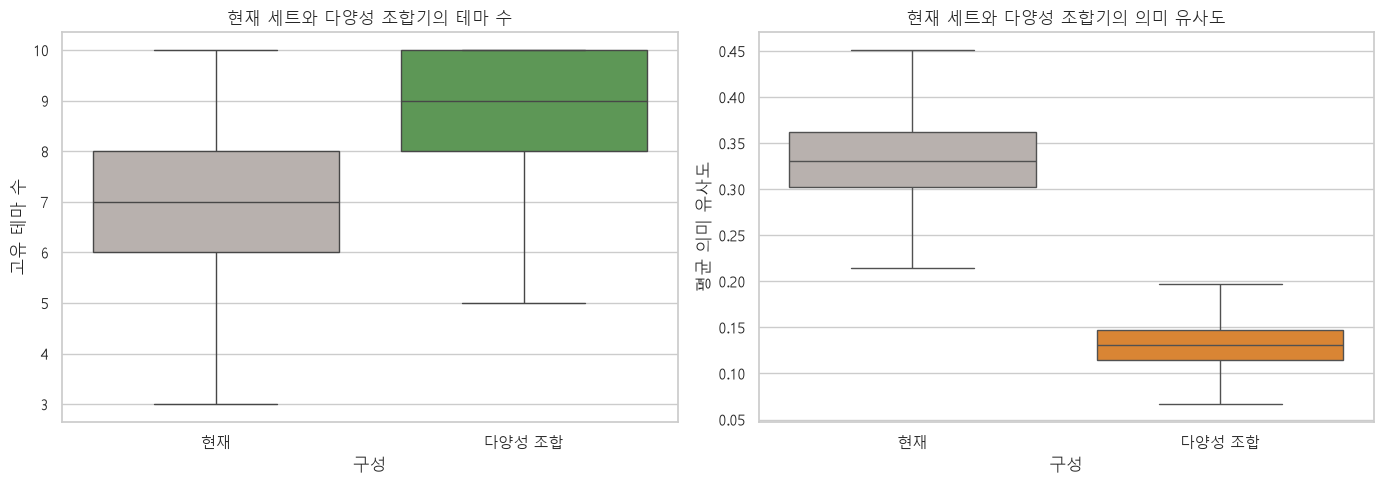

In [48]:
text_order=unique_text.question_text_normalized.tolist(); text_to_idx={t:i for i,t in enumerate(text_order)}
first_times=pd.to_datetime(unique_text.first_at).to_numpy(); theme_arr=np.asarray(refined_labels); popularity=np.asarray(unique_text.piece_count)
qset_lists=(piece_follow.dropna(subset=['question_set_id']).groupby('question_set_id')
    .agg(qset_at=('piece_created_at','min'),texts=('question_text_normalized',lambda s:list(dict.fromkeys(s)))))
qset_lists=qset_lists[qset_lists.texts.map(len)>=5].sample(n=min(700,len(qset_lists)),random_state=42)

def pair_mean_similarity(indices):
    idx=np.array(list(dict.fromkeys(indices)),dtype=int)
    if len(idx)<2:return np.nan
    mat=embeddings[idx]@embeddings[idx].T; tri=mat[np.triu_indices(len(idx),1)]
    return float(tri.mean())

rng=np.random.default_rng(42); sim_rows=[]
for qid,row in qset_lists.iterrows():
    current=[text_to_idx[t] for t in row.texts if t in text_to_idx][:10]
    n=len(current)
    eligible=np.where(first_times<=np.datetime64(row.qset_at))[0]
    pool=rng.choice(eligible,size=min(220,len(eligible)),replace=False).tolist()
    pool=list(dict.fromkeys(current+pool))
    chosen=[max(current,key=lambda i:popularity[i])]
    while len(chosen)<n:
        cand=np.array([i for i in pool if i not in chosen],dtype=int)
        sims=embeddings[cand]@embeddings[np.array(chosen)].T
        min_distance=1-sims.max(axis=1)
        new_theme=(~np.isin(theme_arr[cand],theme_arr[np.array(chosen)])).astype(float)
        score=.75*min_distance+.25*new_theme
        chosen.append(int(cand[np.argmax(score)]))
    sim_rows.append({'question_set_id':qid,'items':n,
                     'observed_unique_themes':len(set(theme_arr[current])),'simulated_unique_themes':len(set(theme_arr[chosen])),
                     'observed_mean_similarity':pair_mean_similarity(current),'simulated_mean_similarity':pair_mean_similarity(chosen)})
composer_sim=pd.DataFrame(sim_rows)
composer_summary=pd.DataFrame([{
    'sampled_qsets':len(composer_sim),'mean_items':composer_sim['items'].mean(),
    'observed_unique_themes':composer_sim.observed_unique_themes.mean(),
    'simulated_unique_themes':composer_sim.simulated_unique_themes.mean(),
    'theme_gain':(composer_sim.simulated_unique_themes-composer_sim.observed_unique_themes).mean(),
    'observed_mean_similarity':composer_sim.observed_mean_similarity.mean(),
    'simulated_mean_similarity':composer_sim.simulated_mean_similarity.mean(),
    'similarity_change':(composer_sim.simulated_mean_similarity-composer_sim.observed_mean_similarity).mean(),
    'theme_paired_t_p':ttest_rel(composer_sim.simulated_unique_themes,composer_sim.observed_unique_themes).pvalue,
    'similarity_paired_t_p':ttest_rel(composer_sim.simulated_mean_similarity,composer_sim.observed_mean_similarity,nan_policy='omit').pvalue,
    'interpretation':'구성 가능성 시뮬레이션이며 행동 효과 아님'
}])
show_final(composer_summary,'07_diversity_composer_simulation')
composer_sim.to_csv(FINAL_DIR/'07b_diversity_composer_qset_detail.csv',index=False,encoding='utf-8-sig')

fig,ax=plt.subplots(1,2,figsize=(14,5))
compare_theme=pd.DataFrame({'현재':composer_sim.observed_unique_themes,'다양성 조합':composer_sim.simulated_unique_themes}).melt(var_name='구성',value_name='고유 테마 수')
sns.boxplot(data=compare_theme,x='구성',y='고유 테마 수',showfliers=False,ax=ax[0],palette=['#BAB0AC','#54A24B']); ax[0].set(title='현재 세트와 다양성 조합기의 테마 수')
compare_sim=pd.DataFrame({'현재':composer_sim.observed_mean_similarity,'다양성 조합':composer_sim.simulated_mean_similarity}).melt(var_name='구성',value_name='평균 의미 유사도')
sns.boxplot(data=compare_sim,x='구성',y='평균 의미 유사도',showfliers=False,ax=ax[1],palette=['#BAB0AC','#F58518']); ax[1].set(title='현재 세트와 다양성 조합기의 의미 유사도')
plt.tight_layout(); plt.savefig(FINAL_FIG_DIR/'07_diversity_composer.png',dpi=170,bbox_inches='tight'); plt.show()

## 23. 질문 포트폴리오

맥락 보정 성과, 의미 신규성, 표본 신뢰도로 운영 검토 우선순위를 구분한다.


,portfolio_status,recommended_action,unique_texts,pieces,mean_score_pp,mean_novelty
0,유지·관찰,현행 유지 및 추가 관측,1031,565379,-0.895729,0.306647
1,익숙한 앵커,세트당 1개 내외 유지,139,206778,0.901629,0.212491
2,중복·저성과 검토,문구 수정·중복 병합 검토,104,37137,-1.923319,0.157679
3,확장 후보,공급 확대 전 제한 A/B,239,387584,0.918816,0.405473


,portfolio_status,recommended_action,question_text,theme_label_ko,pieces,adjusted_text_score_pp,semantic_novelty_to_prior,eb_reliability
84,유지·관찰,현행 유지 및 추가 관측,vote,매력·외모,10169,-0.564021,0.616840,0.991689
3861,유지·관찰,현행 유지 및 추가 관측,화장을 제일 잘하는 사람?,매력·외모,1798,1.090872,NaN,0.981072
23,유지·관찰,현행 유지 및 추가 관측,2세가 가장 귀여울 것 같은 사람은?,매력·외모,2228,0.442176,0.311173,0.977185
3680,유지·관찰,현행 유지 및 추가 관측,학교생활을 가장 성실하게 하는 사람은?,학교·공부,1889,0.479829,0.417404,0.976359
1455,유지·관찰,현행 유지 및 추가 관측,모두가 5살로 돌아간다면 가장 귀여울 것 같은 사람은?,매력·외모,1804,0.468562,0.362507,0.975229
1278,유지·관찰,현행 유지 및 추가 관측,리더십이 가장 강한 사람은?,능력·성숙·신뢰,1752,0.478543,0.359993,0.975185
286,유지·관찰,현행 유지 및 추가 관측,가장 잘생긴 사람은?,매력·외모,1959,0.196095,0.255517,0.974994
3024,유지·관찰,현행 유지 및 추가 관측,정장이 가장 잘 어울릴 것 같은 사람은?,패션·헤어,1911,0.393677,0.185858,0.974983
2650,익숙한 앵커,세트당 1개 내외 유지,웃는게 가장 이쁜 사람은?,배려·유쾌함,1812,1.347806,0.138677,0.985362
3540,익숙한 앵커,세트당 1개 내외 유지,틱톡 팔로워가 가장 많을 것 같은 사람,SNS·연예인 이미지,1927,1.338660,0.258218,0.985129


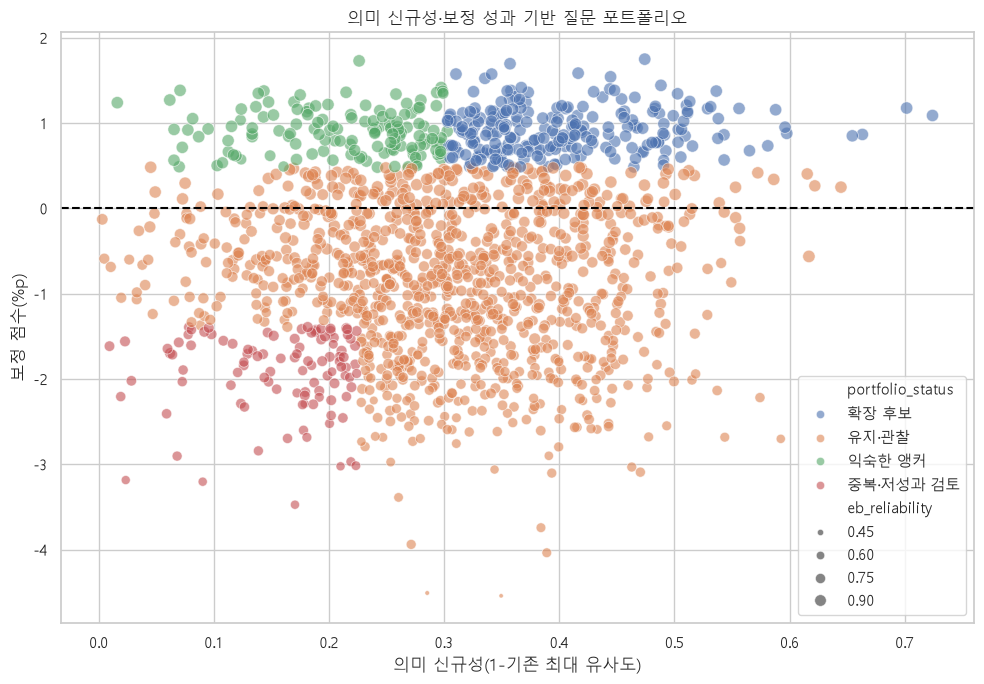

In [49]:
portfolio=text_target[text_target.pieces>=100].copy()
score_q=portfolio.adjusted_text_score.quantile([.25,.75]); novelty_q=portfolio.semantic_novelty_to_prior.fillna(0).quantile([.25,.5,.75])
portfolio['portfolio_status']='유지·관찰'
portfolio.loc[(portfolio.adjusted_text_score>=score_q.loc[.75])&(portfolio.semantic_novelty_to_prior>=novelty_q.loc[.5]),'portfolio_status']='확장 후보'
portfolio.loc[(portfolio.adjusted_text_score>=score_q.loc[.75])&(portfolio.semantic_novelty_to_prior<novelty_q.loc[.5]),'portfolio_status']='익숙한 앵커'
portfolio.loc[(portfolio.semantic_novelty_to_prior>=novelty_q.loc[.75])&(portfolio.eb_reliability<.60),'portfolio_status']='신규 실험'
portfolio.loc[(portfolio.adjusted_text_score<=score_q.loc[.25])&(portfolio.semantic_novelty_to_prior<=novelty_q.loc[.25]),'portfolio_status']='중복·저성과 검토'
portfolio_action={'확장 후보':'공급 확대 전 제한 A/B','익숙한 앵커':'세트당 1개 내외 유지','신규 실험':'소량 노출로 신뢰도 축적','중복·저성과 검토':'문구 수정·중복 병합 검토','유지·관찰':'현행 유지 및 추가 관측'}
portfolio['recommended_action']=portfolio.portfolio_status.map(portfolio_action)
portfolio_summary=(portfolio.groupby(['portfolio_status','recommended_action'],as_index=False)
    .agg(unique_texts=('question_text_normalized','size'),pieces=('pieces','sum'),mean_score_pp=('adjusted_text_score_pp','mean'),mean_novelty=('semantic_novelty_to_prior','mean')))
show_final(portfolio_summary,'08_question_portfolio_summary')
portfolio_examples=(portfolio.sort_values(['portfolio_status','eb_reliability','pieces'],ascending=[True,False,False])
    .groupby('portfolio_status',as_index=False).head(8)
    [['portfolio_status','recommended_action','question_text','theme_label_ko','pieces','adjusted_text_score_pp','semantic_novelty_to_prior','eb_reliability']])
show_final(portfolio_examples,'08b_question_portfolio_examples')
portfolio.drop(columns=['tokens'],errors='ignore').to_csv(FINAL_DIR/'08c_question_portfolio_full.csv',index=False,encoding='utf-8-sig')

fig,ax=plt.subplots(figsize=(10,7))
sns.scatterplot(data=portfolio,x='semantic_novelty_to_prior',y='adjusted_text_score_pp',hue='portfolio_status',size='eb_reliability',sizes=(10,80),alpha=.6,ax=ax)
ax.axhline(0,color='black',ls='--'); ax.set(title='의미 신규성·보정 성과 기반 질문 포트폴리오',xlabel='의미 신규성(1-기존 최대 유사도)',ylabel='보정 점수(%p)')
plt.tight_layout(); plt.savefig(FINAL_FIG_DIR/'08_question_portfolio.png',dpi=170,bbox_inches='tight'); plt.show()

## 24. 검증 결과

관측 결과, 해석 한계, 제품 실험이 필요한 가설을 구분해 정리한다.


In [50]:
best_reg=text_model_benchmark.sort_values('validation_spearman',ascending=False).iloc[0]
best_cls=text_quality_classifier.sort_values('validation_auc',ascending=False).iloc[0]
selected_text_reg=(text_model_benchmark[
    text_model_benchmark.model.isin(['char_tfidf_ridge','sbert_ridge','char_plus_sbert_ridge','sbert_extratrees'])
].sort_values('validation_spearman',ascending=False).iloc[0])
semantic_ok=bool(semantic_model_eval.spearman.iloc[0]>=.15 and semantic_model_eval.spearman_p.iloc[0]<.01)
lifetime_gain=float(life_model_performance.auc_gain_vs_baseline.iloc[-1])

final_evidence_map=pd.DataFrame([
    {'finding':'일부 공통 질문에 공급 집중','evidence':'상위 10% 문구가 질문조각 53%, 상위 20%가 74%','product_action':'인기량 외 신규성·테마 부족분을 포함한 공급 점수','evidence_level':'관측 확인','validation':'공급 정책 A/B'},
    {'finding':'의미가 비슷한 신규 질문의 성과 약화','evidence':'유사도 .70~.95에서 투표 기록률 약 1.4~1.8%p 낮음','product_action':'의미 중복 감지와 soft penalty','evidence_level':'관측 연관','validation':'frequency cap A/B'},
    {'finding':'반복 자체는 다음 행동 감소를 설명하지 못함','evidence':'소진지수 OR 1.176, 용량-반응 하락선 없음','product_action':'반복 전면 제거 대신 익숙한 앵커+신규 슬롯','evidence_level':'반대 가설 미지지','validation':'혼합 비율 실험'},
    {'finding':'질문세트 관계·테마 다양성과 다음 행동 연관','evidence':'동일 사용자 내 테마 OR 1.408, 관계 엔트로피 OR 2.247','product_action':'세트 다양성 슬롯과 관계 믹스','evidence_level':'통제된 연관','validation':'세트 조합기 A/B'},
    {'finding':'학교 로컬 콘텐츠가 거의 없음','evidence':'10개 학교 공통 질문조각 96.08%, 학교 고유 문구 1개','product_action':'학교·학년·반 로컬 슬롯','evidence_level':'관측 확인','validation':'학교 코호트 실험'},
    {'finding':'테마별 후보 관계 차이는 매우 작음','evidence':'상호친구 선택구성 lift가 테마별 약 1.01로 거의 동일','product_action':'테마별 후보 규칙은 보류하고 전체 노출 로그부터 수집','evidence_level':'차이 근거 부족','validation':'전체 후보 노출 로그+무작위 추천'},
    {'finding':'텍스트만의 성과 예측력은 제한적','evidence':f"검증으로 선택한 텍스트 회귀 test Spearman={selected_text_reg.test_spearman:.3f}, high/low 분류 AUC={best_cls.test_auc:.3f}",
     'product_action':'자동 삭제가 아닌 검토 우선순위 보조','evidence_level':'고정 테스트 검증','validation':'신규 질문 온라인 성과'},
    {'finding':'다양성 조합 가능성','evidence':f"테마 수 평균 +{composer_summary.theme_gain.iloc[0]:.2f}, 평균 유사도 {composer_summary.similarity_change.iloc[0]:+.3f}",
     'product_action':'당시 이용 가능한 풀에서 다양성 조합','evidence_level':'오프라인 시뮬레이션','validation':'완료·다음 행동 A/B'},
    {'finding':'콘텐츠 수명의 추가 텍스트 설명력','evidence':f"기준모형 대비 AUC 변화 {lifetime_gain:+.3f}",
     'product_action':'초기 공급 신호와 텍스트를 분리한 운영','evidence_level':'고정 테스트 예측','validation':'신규 콘텐츠 생존 추적'},
])
show_final(final_evidence_map,'09_final_evidence_to_product_action')

final_qa=pd.DataFrame([
    {'check':'기존·후속 셀 보존 후 최종 셀 추가','status':'PASS','detail':'tagged append'},
    {'check':'문구별 점수 1행 유일','status':'PASS' if text_target.question_text_normalized.is_unique else 'FAIL','detail':f'rows={len(text_target):,}'},
    {'check':'학습·검증·테스트 완전 분리','status':'PASS' if int(split_audit.overlap.iloc[0])==0 else 'FAIL','detail':f"train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}"},
    {'check':'모형 성능 전체 공개','status':'PASS' if len(text_model_benchmark)>=6 else 'FAIL','detail':f'models={len(text_model_benchmark)}'},
    {'check':'테마 후보관계 전행 유효','status':'PASS' if len(theme_relation)>0 and theme_relation.selection_composition_lift.notna().all() else 'FAIL','detail':f'rows={len(theme_relation)}'},
    {'check':'수명 모형 우측 검열 적용','status':'PASS' if len(life_model)>0 else 'FAIL','detail':f'eligible_texts={len(life_model)}'},
    {'check':'다양성 시뮬레이션 표본 확보','status':'PASS' if len(composer_sim)>=500 else 'FAIL','detail':f'qsets={len(composer_sim)}'},
    {'check':'개선안에 검증 방법 포함','status':'PASS' if final_evidence_map.validation.notna().all() else 'FAIL','detail':f'actions={len(final_evidence_map)}'},
])
show_final(final_qa,'99_final_deep_qa')
assert final_qa.status.eq('PASS').all(),final_qa

final_conclusion=pd.DataFrame([
    {'order':1,'conclusion':'질문 수보다 의미 신규성과 공급 균형을 관리','reason':'ID·문구 수는 많지만 일부 공통 문구에 공급이 집중'},
    {'order':2,'conclusion':'반복을 모두 제거하지 않고 익숙한 앵커와 신규 슬롯을 혼합','reason':'반복이 다음 행동을 낮춘다는 근거가 없고 친숙한 후보는 선택되기 쉬움'},
    {'order':3,'conclusion':'세트의 테마·관계 다양성은 관리하되 테마별 후보 규칙은 보류','reason':'다양성과 다음 행동의 연관은 있으나 테마별 선택 관계 차이는 매우 작고 전체 노출 후보가 없음'},
    {'order':4,'conclusion':'학교 로컬 콘텐츠를 별도 슬롯으로 검증','reason':'현재 질문조각의 96.08%가 10개 학교 공통 문구'},
    {'order':5,'conclusion':'텍스트 모형은 운영 검토 보조로만 사용','reason':'고정 테스트 성능이 있어도 인과효과와 자동 승인 기준은 아님'},
    {'order':6,'conclusion':'오프라인 다양성 개선 후 온라인 행동 실험','reason':'조합기는 다양성을 높일 수 있지만 행동 개선은 증명하지 않음'},
])
show_final(final_conclusion,'99b_final_content_conclusion')
print('CONTENT FINAL-DEEP QA:',final_qa.status.value_counts().to_dict())
print('최종 심화분석 완료:',FINAL_DIR)

,finding,evidence,product_action,evidence_level,validation
0,일부 공통 질문에 공급 집중,"상위 10% 문구가 질문조각 53%, 상위 20%가 74%",인기량 외 신규성·테마 부족분을 포함한 공급 점수,관측 확인,공급 정책 A/B
1,의미가 비슷한 신규 질문의 성과 약화,유사도 .70~.95에서 투표 기록률 약 1.4~1.8%p 낮음,의미 중복 감지와 soft penalty,관측 연관,frequency cap A/B
2,반복 자체는 다음 행동 감소를 설명하지 못함,"소진지수 OR 1.176, 용량-반응 하락선 없음",반복 전면 제거 대신 익숙한 앵커+신규 슬롯,반대 가설 미지지,혼합 비율 실험
3,질문세트 관계·테마 다양성과 다음 행동 연관,"동일 사용자 내 테마 OR 1.408, 관계 엔트로피 OR 2.247",세트 다양성 슬롯과 관계 믹스,통제된 연관,세트 조합기 A/B
4,학교 로컬 콘텐츠가 거의 없음,"10개 학교 공통 질문조각 96.08%, 학교 고유 문구 1개",학교·학년·반 로컬 슬롯,관측 확인,학교 코호트 실험
5,테마별 후보 관계 차이는 매우 작음,상호친구 선택구성 lift가 테마별 약 1.01로 거의 동일,테마별 후보 규칙은 보류하고 전체 노출 로그부터 수집,차이 근거 부족,전체 후보 노출 로그+무작위 추천
6,텍스트만의 성과 예측력은 제한적,"검증으로 선택한 텍스트 회귀 test Spearman=0.202, high/low ...",자동 삭제가 아닌 검토 우선순위 보조,고정 테스트 검증,신규 질문 온라인 성과
7,다양성 조합 가능성,"테마 수 평균 +1.76, 평균 유사도 -0.201",당시 이용 가능한 풀에서 다양성 조합,오프라인 시뮬레이션,완료·다음 행동 A/B
8,콘텐츠 수명의 추가 텍스트 설명력,기준모형 대비 AUC 변화 -0.013,초기 공급 신호와 텍스트를 분리한 운영,고정 테스트 예측,신규 콘텐츠 생존 추적


,check,status,detail
0,기존·후속 셀 보존 후 최종 셀 추가,PASS,tagged append
1,문구별 점수 1행 유일,PASS,"rows=3,898"
2,학습·검증·테스트 완전 분리,PASS,"train=1066, val=253, test=242"
3,모형 성능 전체 공개,PASS,models=6
4,테마 후보관계 전행 유효,PASS,rows=175
5,수명 모형 우측 검열 적용,PASS,eligible_texts=3898
6,다양성 시뮬레이션 표본 확보,PASS,qsets=700
7,개선안에 검증 방법 포함,PASS,actions=9


,order,conclusion,reason
0,1,질문 수보다 의미 신규성과 공급 균형을 관리,ID·문구 수는 많지만 일부 공통 문구에 공급이 집중
1,2,반복을 모두 제거하지 않고 익숙한 앵커와 신규 슬롯을 혼합,반복이 다음 행동을 낮춘다는 근거가 없고 친숙한 후보는 선택되기 쉬움
2,3,세트의 테마·관계 다양성은 관리하되 테마별 후보 규칙은 보류,다양성과 다음 행동의 연관은 있으나 테마별 선택 관계 차이는 매우 작고 전체 노출 ...
3,4,학교 로컬 콘텐츠를 별도 슬롯으로 검증,현재 질문조각의 96.08%가 10개 학교 공통 문구
4,5,텍스트 모형은 운영 검토 보조로만 사용,고정 테스트 성능이 있어도 인과효과와 자동 승인 기준은 아님
5,6,오프라인 다양성 개선 후 온라인 행동 실험,조합기는 다양성을 높일 수 있지만 행동 개선은 증명하지 않음


CONTENT FINAL-DEEP QA: {'PASS': 8}
최종 심화분석 완료: C:\Users\lucy5\Desktop\team7\analysis\content_deep_dive\outputs\final_deep
